In [7]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

files = [
    "clean_hiring_data.csv",
    "Resume.csv",
    "Job_Description CSV.csv"
]

for file in files:
    print("\n" + "=" * 70)
    print(file)
    print("=" * 70)

    temp = pd.read_csv(file)

    print("Shape:", temp.shape)
    print("Columns:")
    print(temp.columns.tolist())
    print("\nFirst 3 rows:")
    display(temp.head(3))


clean_hiring_data.csv
Shape: (10174, 11)
Columns:
['ID', 'Name', 'Role', 'Transcript', 'Resume', 'decision', 'Reason_for_decision', 'Job_Description', 'Resume_Length', 'JD_Length', 'Transcript_Length']

First 3 rows:


,ID,Name,Role,Transcript,Resume,decision,Reason_for_decision,Job_Description,Resume_Length,JD_Length,Transcript_Length
0,jasojo159,Jason Jones,E-commerce Specialist,interviewer good morning jason its great to me...,heres a professional resume for jason jones ja...,reject,Lacked leadership skills for a senior position.,be part of a passionate team at the forefront ...,2380,134,3630
1,annma759,Ann Marshall,Game Developer,interview scene a conference room with a table...,heres a professional resume for ann marshall a...,select,Strong technical skills in AI and ML.,help us build the nextgeneration products as a...,373,106,3702
2,patrmc729,Patrick Mcclain,Human Resources Specialist,interview setting a conference room in a mediu...,heres a professional resume for patrick mcclai...,reject,Insufficient system design expertise for senio...,we need a human resources specialist to enhanc...,2832,134,4360



Resume.csv
Shape: (2484, 4)
Columns:
['ID', 'Resume_str', 'Resume_html', 'Category']

First 3 rows:


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR



Job_Description CSV.csv
Shape: (10174, 8)
Columns:
['ID', 'Name', 'Role', 'Transcript', 'Resume', 'decision', 'Reason_for_decision', 'Job_Description']

First 3 rows:


,ID,Name,Role,Transcript,Resume,decision,Reason_for_decision,Job_Description
0,jasojo159,Jason Jones,E-commerce Specialist,"Interviewer: Good morning, Jason. It's great t...",Here's a professional resume for Jason Jones:\...,reject,Lacked leadership skills for a senior position.,Be part of a passionate team at the forefront ...
1,annma759,Ann Marshall,Game Developer,Interview Scene\n\nA conference room with a ta...,Here's a professional resume for Ann Marshall:...,select,Strong technical skills in AI and ML.,Help us build the next-generation products as ...
2,patrmc729,Patrick Mcclain,Human Resources Specialist,Interview Setting: A conference room in a medi...,Here's a professional resume for Patrick Mccla...,reject,Insufficient system design expertise for senio...,We need a Human Resources Specialist to enhanc...


In [8]:
# ============================================================
# AI RESUME INTELLIGENCE & CANDIDATE RANKING SYSTEM
# ============================================================
# End-to-End Data Science Project
# ============================================================

print("AI Resume Intelligence Project")
print("Starting project...")

# ============================================================
# 2. IMPORT LIBRARIES & CREATE PROJECT FOLDERS
# ============================================================

import os
import re
import string
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Create required folders automatically
# ------------------------------------------------------------

os.makedirs("data", exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

print("Libraries imported successfully.")
print("Project folders created successfully.")

AI Resume Intelligence Project
Starting project...
Libraries imported successfully.
Project folders created successfully.


In [9]:
# ============================================================
# 3. LOAD & VALIDATE ALL DATASETS
# ============================================================

# ------------------------------------------------------------
# Dataset 1: Clean Hiring Dataset
# ------------------------------------------------------------

hiring_df = pd.read_csv("clean_hiring_data.csv")

# ------------------------------------------------------------
# Dataset 2: Resume Dataset
# ------------------------------------------------------------

resume_df = pd.read_csv("Resume.csv")

# ------------------------------------------------------------
# Dataset 3: Job Description Dataset
# ------------------------------------------------------------

job_df = pd.read_csv("Job_Description CSV.csv")


# ============================================================
# BASIC DATASET INFORMATION
# ============================================================

print("=" * 70)
print("DATASET 1 — CLEAN HIRING DATA")
print("=" * 70)

print("Shape:", hiring_df.shape)
print("Columns:")
print(hiring_df.columns.tolist())


print("\n" + "=" * 70)
print("DATASET 2 — RESUME DATA")
print("=" * 70)

print("Shape:", resume_df.shape)
print("Columns:")
print(resume_df.columns.tolist())


print("\n" + "=" * 70)
print("DATASET 3 — JOB DESCRIPTION DATA")
print("=" * 70)

print("Shape:", job_df.shape)
print("Columns:")
print(job_df.columns.tolist())


# ============================================================
# CHECK MISSING VALUES
# ============================================================

print("\n" + "=" * 70)
print("MISSING VALUES — HIRING DATA")
print("=" * 70)

print(hiring_df.isnull().sum())


print("\n" + "=" * 70)
print("MISSING VALUES — RESUME DATA")
print("=" * 70)

print(resume_df.isnull().sum())


print("\n" + "=" * 70)
print("MISSING VALUES — JOB DESCRIPTION DATA")
print("=" * 70)

print(job_df.isnull().sum())

DATASET 1 — CLEAN HIRING DATA
Shape: (10174, 11)
Columns:
['ID', 'Name', 'Role', 'Transcript', 'Resume', 'decision', 'Reason_for_decision', 'Job_Description', 'Resume_Length', 'JD_Length', 'Transcript_Length']

DATASET 2 — RESUME DATA
Shape: (2484, 4)
Columns:
['ID', 'Resume_str', 'Resume_html', 'Category']

DATASET 3 — JOB DESCRIPTION DATA
Shape: (10174, 8)
Columns:
['ID', 'Name', 'Role', 'Transcript', 'Resume', 'decision', 'Reason_for_decision', 'Job_Description']

MISSING VALUES — HIRING DATA
ID                     0
Name                   0
Role                   0
Transcript             0
Resume                 0
decision               0
Reason_for_decision    0
Job_Description        0
Resume_Length          0
JD_Length              0
Transcript_Length      0
dtype: int64

MISSING VALUES — RESUME DATA
ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

MISSING VALUES — JOB DESCRIPTION DATA
ID                     0
Name                   0
Role       

In [4]:
# ============================================================
# 3. LOAD & VALIDATE ALL DATASETS
# ============================================================

# ------------------------------------------------------------
# File paths
# ------------------------------------------------------------
import pandas as pd
HIRING_FILE = "clean_hiring_data.csv"
RESUME_FILE = "Resume.csv"
JOB_FILE = "Job_Description CSV.csv"


# ------------------------------------------------------------
# Load datasets
# ------------------------------------------------------------

hiring_df = pd.read_csv(HIRING_FILE)
resume_df = pd.read_csv(RESUME_FILE)
job_df = pd.read_csv(JOB_FILE)


# ============================================================
# DATASET OVERVIEW
# ============================================================

print("=" * 75)
print("AI RESUME INTELLIGENCE PROJECT — DATASET OVERVIEW")
print("=" * 75)


print("\n📌 Dataset 1: Hiring Dataset")
print("-" * 75)
print("Rows    :", hiring_df.shape[0])
print("Columns :", hiring_df.shape[1])
print("Memory  :", round(hiring_df.memory_usage(deep=True).sum() / 1024**2, 2), "MB")


print("\n📌 Dataset 2: Resume Dataset")
print("-" * 75)
print("Rows    :", resume_df.shape[0])
print("Columns :", resume_df.shape[1])
print("Memory  :", round(resume_df.memory_usage(deep=True).sum() / 1024**2, 2), "MB")


print("\n📌 Dataset 3: Job Description Dataset")
print("-" * 75)
print("Rows    :", job_df.shape[0])
print("Columns :", job_df.shape[1])
print("Memory  :", round(job_df.memory_usage(deep=True).sum() / 1024**2, 2), "MB")


# ============================================================
# COLUMN VALIDATION
# ============================================================

expected_hiring_columns = [
    "ID",
    "Name",
    "Role",
    "Transcript",
    "Resume",
    "decision",
    "Reason_for_decision",
    "Job_Description",
    "Resume_Length",
    "JD_Length",
    "Transcript_Length"
]

expected_resume_columns = [
    "ID",
    "Resume_str",
    "Resume_html",
    "Category"
]

expected_job_columns = [
    "ID",
    "Name",
    "Role",
    "Transcript",
    "Resume",
    "decision",
    "Reason_for_decision",
    "Job_Description"
]


# ------------------------------------------------------------
# Validate hiring dataset
# ------------------------------------------------------------

assert list(hiring_df.columns) == expected_hiring_columns, \
    "Hiring dataset columns do not match expected structure."


# ------------------------------------------------------------
# Validate resume dataset
# ------------------------------------------------------------

assert list(resume_df.columns) == expected_resume_columns, \
    "Resume dataset columns do not match expected structure."


# ------------------------------------------------------------
# Validate job dataset
# ------------------------------------------------------------

assert list(job_df.columns) == expected_job_columns, \
    "Job Description dataset columns do not match expected structure."


print("\n✅ Column validation passed successfully.")


# ============================================================
# MISSING VALUE CHECK
# ============================================================

print("\n" + "=" * 75)
print("MISSING VALUE CHECK")
print("=" * 75)


hiring_missing = hiring_df.isnull().sum().sum()
resume_missing = resume_df.isnull().sum().sum()
job_missing = job_df.isnull().sum().sum()


print("Hiring Dataset missing values :", hiring_missing)
print("Resume Dataset missing values :", resume_missing)
print("Job Dataset missing values    :", job_missing)


# ============================================================
# FINAL VALIDATION
# ============================================================

if hiring_missing == 0 and resume_missing == 0 and job_missing == 0:

    print("\n✅ All datasets loaded successfully.")
    print("✅ All expected columns are present.")
    print("✅ No missing values detected.")

else:

    print("\n⚠️ Missing values detected. Further cleaning is required.")


print("\n🚀 Dataset validation completed successfully!")

AI RESUME INTELLIGENCE PROJECT — DATASET OVERVIEW

📌 Dataset 1: Hiring Dataset
---------------------------------------------------------------------------
Rows    : 10174
Columns : 11
Memory  : 76.67 MB

📌 Dataset 2: Resume Dataset
---------------------------------------------------------------------------
Rows    : 2484
Columns : 4
Memory  : 86.03 MB

📌 Dataset 3: Job Description Dataset
---------------------------------------------------------------------------
Rows    : 10174
Columns : 8
Memory  : 80.97 MB

✅ Column validation passed successfully.

MISSING VALUE CHECK
Hiring Dataset missing values : 0
Resume Dataset missing values : 0
Job Dataset missing values    : 0

✅ All datasets loaded successfully.
✅ All expected columns are present.
✅ No missing values detected.

🚀 Dataset validation completed successfully!


In [5]:
# ============================================================
# 4. DATA QUALITY & HIRING ANALYSIS
# ============================================================

print("=" * 75)
print("DATA QUALITY & HIRING ANALYSIS")
print("=" * 75)


# ============================================================
# 4.1 DUPLICATE CHECK
# ============================================================

print("\n📌 DUPLICATE RECORD CHECK")
print("-" * 75)

hiring_duplicates = hiring_df.duplicated().sum()
resume_duplicates = resume_df.duplicated().sum()
job_duplicates = job_df.duplicated().sum()

print("Hiring Dataset duplicates :", hiring_duplicates)
print("Resume Dataset duplicates :", resume_duplicates)
print("Job Dataset duplicates    :", job_duplicates)


# ============================================================
# 4.2 UNIQUE ID CHECK
# ============================================================

print("\n📌 UNIQUE ID CHECK")
print("-" * 75)

print(
    "Hiring Dataset unique IDs :",
    hiring_df["ID"].nunique(),
    "/",
    len(hiring_df)
)

print(
    "Resume Dataset unique IDs :",
    resume_df["ID"].nunique(),
    "/",
    len(resume_df)
)

print(
    "Job Dataset unique IDs    :",
    job_df["ID"].nunique(),
    "/",
    len(job_df)
)


# ============================================================
# 4.3 HIRING DECISION DISTRIBUTION
# ============================================================

print("\n📌 HIRING DECISION DISTRIBUTION")
print("-" * 75)

decision_counts = hiring_df["decision"].value_counts()

print(decision_counts)


# ============================================================
# 4.4 HIRING DECISION PERCENTAGE
# ============================================================

print("\n📌 HIRING DECISION PERCENTAGE")
print("-" * 75)

decision_percentage = (
    hiring_df["decision"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(decision_percentage)


# ============================================================
# 4.5 UNIQUE JOB ROLES
# ============================================================

print("\n📌 JOB ROLE ANALYSIS")
print("-" * 75)

unique_roles = hiring_df["Role"].nunique()

print("Total unique job roles:", unique_roles)

print("\nTop 15 job roles:")

print(
    hiring_df["Role"]
    .value_counts()
    .head(15)
)


# ============================================================
# 4.6 RESUME CATEGORY ANALYSIS
# ============================================================

print("\n📌 RESUME CATEGORY ANALYSIS")
print("-" * 75)

unique_categories = resume_df["Category"].nunique()

print("Total resume categories:", unique_categories)

print("\nResume category distribution:")

print(
    resume_df["Category"]
    .value_counts()
)


# ============================================================
# 4.7 TEXT LENGTH STATISTICS
# ============================================================

print("\n📌 TEXT LENGTH ANALYSIS")
print("-" * 75)

print("\nResume length statistics:")

print(
    hiring_df["Resume_Length"]
    .describe()
    .round(2)
)

print("\nJob Description length statistics:")

print(
    hiring_df["JD_Length"]
    .describe()
    .round(2)
)

print("\nInterview Transcript length statistics:")

print(
    hiring_df["Transcript_Length"]
    .describe()
    .round(2)
)


# ============================================================
# 4.8 DATASET CONSISTENCY CHECK
# ============================================================

print("\n📌 DATASET CONSISTENCY CHECK")
print("-" * 75)

hiring_ids = set(hiring_df["ID"])
job_ids = set(job_df["ID"])

common_ids = hiring_ids.intersection(job_ids)

print("Hiring IDs :", len(hiring_ids))
print("Job IDs    :", len(job_ids))
print("Common IDs :", len(common_ids))

if hiring_ids == job_ids:
    print("✅ Hiring and Job Description datasets are ID-consistent.")
else:
    print("⚠️ ID mismatch detected.")


# ============================================================
# 4.9 FINAL DATA QUALITY SUMMARY
# ============================================================

print("\n" + "=" * 75)
print("DATA QUALITY SUMMARY")
print("=" * 75)

print("✔ Missing values checked")
print("✔ Duplicate records checked")
print("✔ Unique IDs checked")
print("✔ Hiring decisions analyzed")
print("✔ Job roles analyzed")
print("✔ Resume categories analyzed")
print("✔ Text lengths analyzed")
print("✔ Dataset ID consistency checked")

print("\n🚀 Data quality analysis completed successfully!")

DATA QUALITY & HIRING ANALYSIS

📌 DUPLICATE RECORD CHECK
---------------------------------------------------------------------------
Hiring Dataset duplicates : 0
Resume Dataset duplicates : 0
Job Dataset duplicates    : 0

📌 UNIQUE ID CHECK
---------------------------------------------------------------------------
Hiring Dataset unique IDs : 10171 / 10174
Resume Dataset unique IDs : 2484 / 2484
Job Dataset unique IDs    : 10171 / 10174

📌 HIRING DECISION DISTRIBUTION
---------------------------------------------------------------------------
decision
reject    5114
select    5060
Name: count, dtype: int64

📌 HIRING DECISION PERCENTAGE
---------------------------------------------------------------------------
decision
reject    50.27
select    49.73
Name: proportion, dtype: float64

📌 JOB ROLE ANALYSIS
---------------------------------------------------------------------------
Total unique job roles: 45

Top 15 job roles:
Role
Data Scientist                  538
Software Engineer    

In [6]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
print(hiring_df.columns.tolist())


['ID', 'Name', 'Role', 'Transcript', 'Resume', 'decision', 'Reason_for_decision', 'Job_Description', 'Resume_Length', 'JD_Length', 'Transcript_Length']


EXPLORATORY DATA ANALYSIS


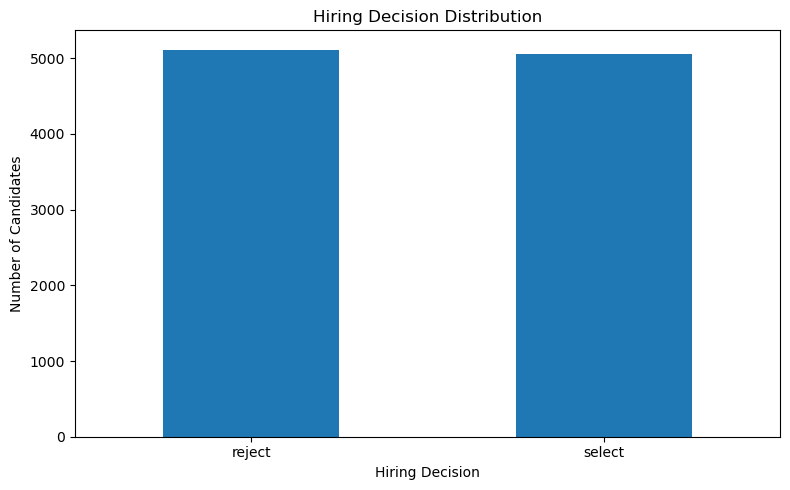

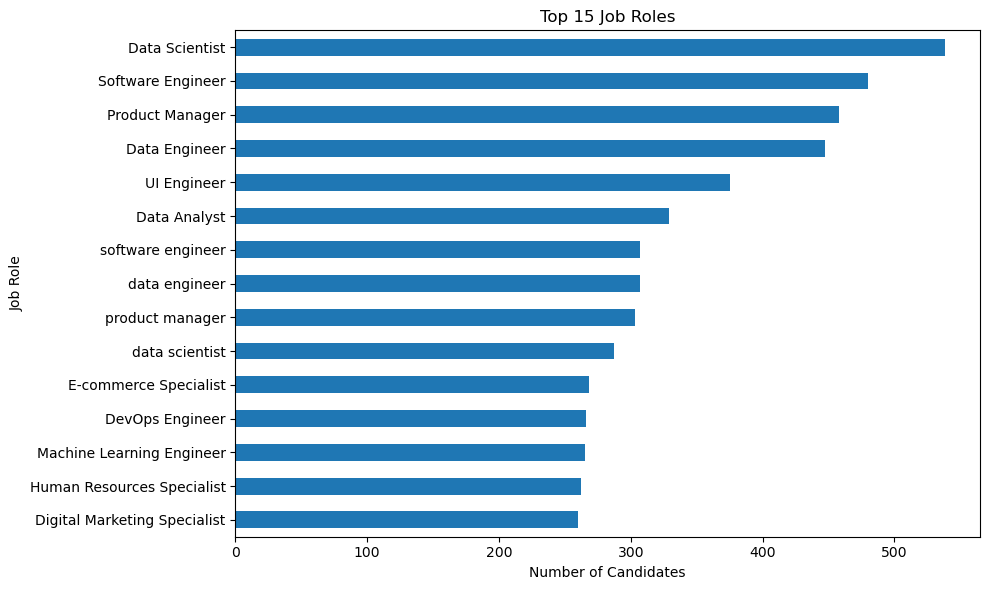

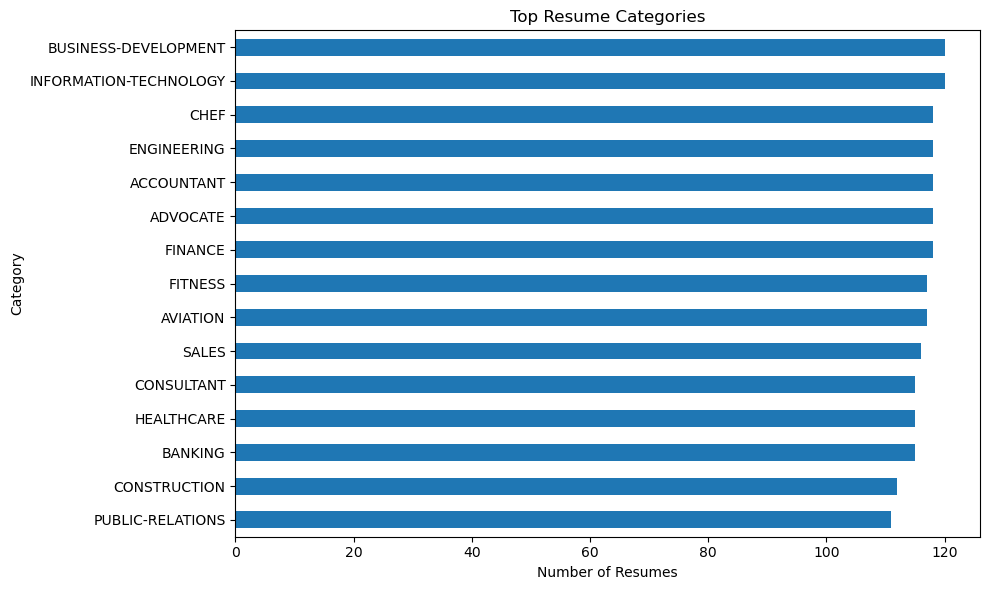

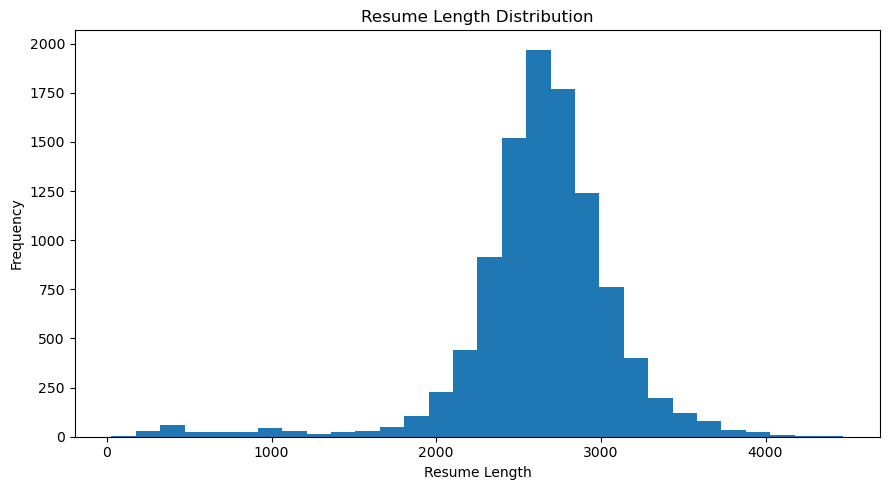

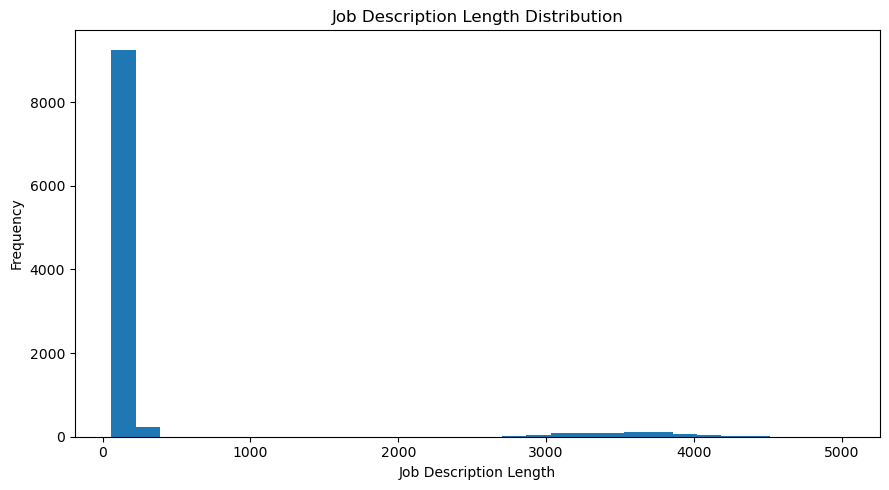

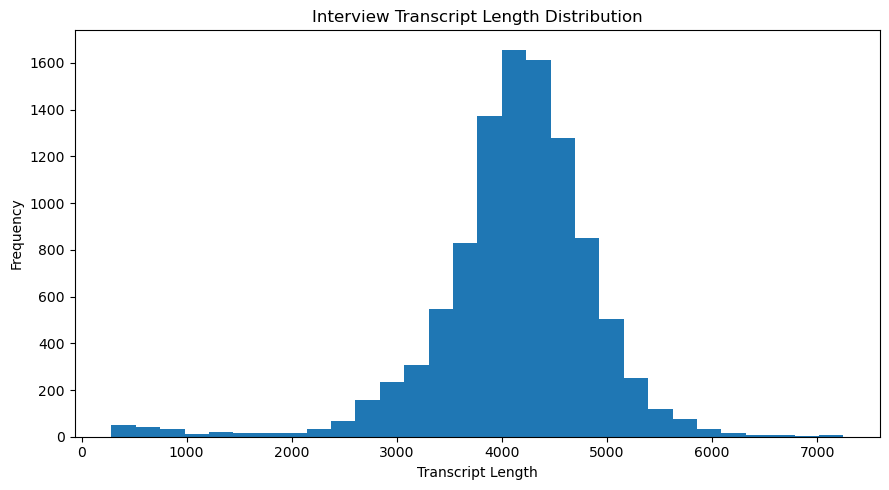

<Figure size 800x500 with 0 Axes>

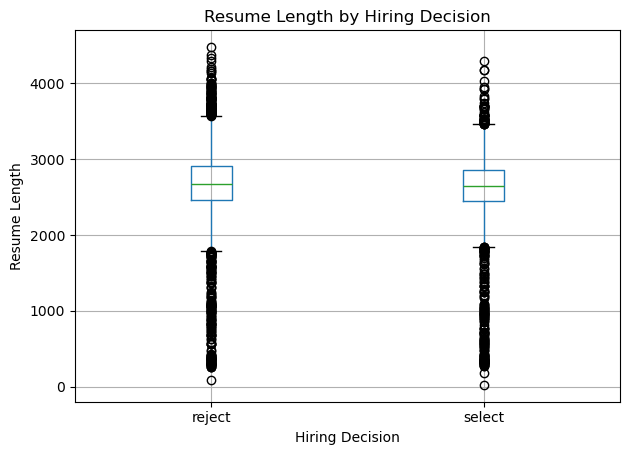

<Figure size 800x500 with 0 Axes>

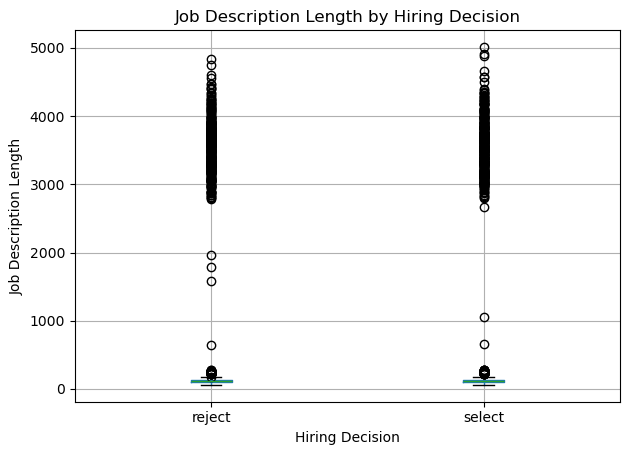

<Figure size 800x500 with 0 Axes>

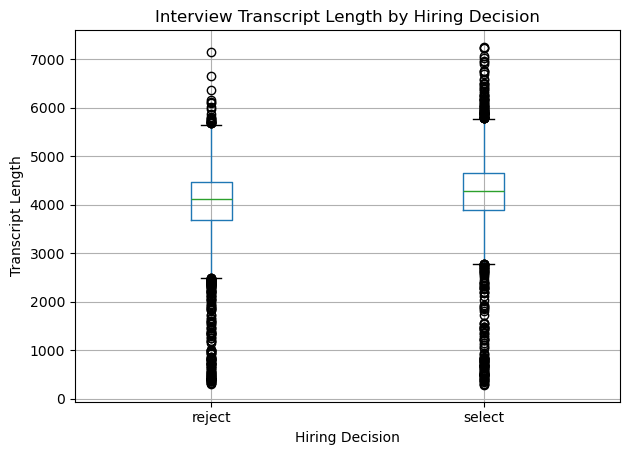


✅ EDA completed successfully.


In [9]:
# ============================================================
# 5. EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

print("=" * 75)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 75)


# ============================================================
# 5.1 HIRING DECISION DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

decision_counts = hiring_df["decision"].value_counts()

decision_counts.plot(
    kind="bar"
)

plt.title("Hiring Decision Distribution")
plt.xlabel("Hiring Decision")
plt.ylabel("Number of Candidates")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# ============================================================
# 5.2 TOP JOB ROLES
# ============================================================

plt.figure(figsize=(10, 6))

top_roles = (
    hiring_df["Role"]
    .value_counts()
    .head(15)
    .sort_values()
)

top_roles.plot(
    kind="barh"
)

plt.title("Top 15 Job Roles")
plt.xlabel("Number of Candidates")
plt.ylabel("Job Role")
plt.tight_layout()
plt.show()


# ============================================================
# 5.3 RESUME CATEGORY DISTRIBUTION
# ============================================================

category_counts = (
    resume_df["Category"]
    .value_counts()
    .head(15)
    .sort_values()
)

plt.figure(figsize=(10, 6))

category_counts.plot(
    kind="barh"
)

plt.title("Top Resume Categories")
plt.xlabel("Number of Resumes")
plt.ylabel("Category")
plt.tight_layout()
plt.show()


# ============================================================
# 5.4 RESUME LENGTH DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 5))

hiring_df["Resume_Length"].plot(
    kind="hist",
    bins=30
)

plt.title("Resume Length Distribution")
plt.xlabel("Resume Length")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# ============================================================
# 5.5 JOB DESCRIPTION LENGTH DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 5))

hiring_df["JD_Length"].plot(
    kind="hist",
    bins=30
)

plt.title("Job Description Length Distribution")
plt.xlabel("Job Description Length")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# ============================================================
# 5.6 INTERVIEW TRANSCRIPT LENGTH DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 5))

hiring_df["Transcript_Length"].plot(
    kind="hist",
    bins=30
)

plt.title("Interview Transcript Length Distribution")
plt.xlabel("Transcript Length")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# ============================================================
# 5.7 RESUME LENGTH BY DECISION
# ============================================================

plt.figure(figsize=(8, 5))

hiring_df.boxplot(
    column="Resume_Length",
    by="decision"
)

plt.title("Resume Length by Hiring Decision")
plt.suptitle("")
plt.xlabel("Hiring Decision")
plt.ylabel("Resume Length")
plt.tight_layout()
plt.show()

# ============================================================
# 5.8 JOB DESCRIPTION LENGTH BY DECISION
# ============================================================

plt.figure(figsize=(8, 5))

hiring_df.boxplot(
    column="JD_Length",
    by="decision"
)

plt.title("Job Description Length by Hiring Decision")
plt.suptitle("")
plt.xlabel("Hiring Decision")
plt.ylabel("Job Description Length")
plt.tight_layout()
plt.show()

# ============================================================
# 5.9 INTERVIEW TRANSCRIPT LENGTH BY DECISION
# ============================================================

plt.figure(figsize=(8, 5))

hiring_df.boxplot(
    column="Transcript_Length",
    by="decision"
)

plt.title("Interview Transcript Length by Hiring Decision")
plt.suptitle("")
plt.xlabel("Hiring Decision")
plt.ylabel("Transcript Length")
plt.tight_layout()
plt.show()

print("\n✅ EDA completed successfully.")

In [17]:
# ============================================================
# 6. NLP TEXT PREPROCESSING
# ============================================================

print("=" * 75)
print("NLP TEXT PREPROCESSING")
print("=" * 75)

import re
# ============================================================
# 6.1 TEXT CLEANING FUNCTION
# ============================================================

def clean_text(text):
    """
    Clean resume / job-description text for NLP processing.
    """

    # Convert to string
    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)

    # Remove email addresses
    text = re.sub(
        r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b",
        " ",
        text
    )

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Keep letters, numbers and spaces
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text
# ============================================================
# 6. TEXT PREPROCESSING
# ============================================================

import re

def clean_text(text):

    if pd.isna(text):
        return ""

    text = str(text).lower()

    text = re.sub(
        r"http\S+|www\S+|https\S+",
        " ",
        text
    )

    text = re.sub(
        r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b",
        " ",
        text
    )

    text = re.sub(
        r"[^a-zA-Z0-9\s]",
        " ",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()
# ============================================================
# 6.2 CREATE CLEAN TEXT COLUMNS
# ============================================================

hiring_df["clean_resume"] = (
    hiring_df["Resume"]
    .fillna("")
    .apply(clean_text)
)

hiring_df["clean_job_description"] = (
    hiring_df["Job_Description"]
    .fillna("")
    .apply(clean_text)
)

hiring_df["clean_transcript"] = (
    hiring_df["Transcript"]
    .fillna("")
    .apply(clean_text)
)

print("✅ Text preprocessing completed successfully.")

print(
    hiring_df[
        [
            "clean_resume",
            "clean_job_description",
            "clean_transcript"
        ]
    ].head()
)




 


NLP TEXT PREPROCESSING
✅ Text preprocessing completed successfully.
                                        clean_resume  \
0  heres a professional resume for jason jones ja...   
1  heres a professional resume for ann marshall a...   
2  heres a professional resume for patrick mcclai...   
3  heres a professional resume for patricia gray ...   
4  heres a professional resume for amanda gross a...   

                               clean_job_description  \
0  be part of a passionate team at the forefront ...   
1  help us build the nextgeneration products as a...   
2  we need a human resources specialist to enhanc...   
3  be part of a passionate team at the forefront ...   
4  we are looking for an experienced ecommerce sp...   

                                    clean_transcript  
0  interviewer good morning jason its great to me...  
1  interview scene a conference room with a table...  
2  interview setting a conference room in a mediu...  
3  heres a simulated professional inte

In [18]:
# ============================================================
# 7. SKILL EXTRACTION ENGINE
# ============================================================

print("=" * 75)
print("SKILL EXTRACTION ENGINE")
print("=" * 75)


# ============================================================
# 7.1 MASTER SKILL DICTIONARY
# ============================================================

SKILL_LIST = [

    # Programming
    "python",
    "java",
    "c++",
    "c#",
    "javascript",
    "typescript",
    "r",
    "scala",
    "sql",

    # Data Science / Machine Learning
    "machine learning",
    "deep learning",
    "artificial intelligence",
    "data science",
    "data analysis",
    "statistics",
    "natural language processing",
    "nlp",
    "computer vision",
    "generative ai",

    # Python / ML Libraries
    "numpy",
    "pandas",
    "scikit learn",
    "sklearn",
    "tensorflow",
    "pytorch",
    "keras",
    "matplotlib",
    "seaborn",
    "plotly",
    "streamlit",

    # Databases
    "mysql",
    "postgresql",
    "mongodb",
    "oracle",
    "sql server",

    # Cloud / DevOps
    "aws",
    "azure",
    "google cloud",
    "gcp",
    "docker",
    "kubernetes",
    "git",
    "github",
    "gitlab",

    # Big Data
    "spark",
    "hadoop",
    "hive",
    "kafka",

    # Analytics / BI
    "power bi",
    "tableau",
    "excel",

    # Web / Backend
    "django",
    "flask",
    "fastapi",
    "rest api",
    "api",

    # Advanced Data Skills
    "data visualization",
    "feature engineering",
    "model deployment",
    "mlops",
    "etl",
    "data mining",
    "time series",
    "a b testing"
]


# ============================================================
# 7.2 SORT SKILLS
# ============================================================

SKILL_LIST = sorted(
    set(SKILL_LIST),
    key=len,
    reverse=True
)


# ============================================================
# 7.3 SKILL EXTRACTION FUNCTION
# ============================================================

def extract_skills(text):

    text = str(text).lower()

    found_skills = []

    for skill in SKILL_LIST:

        pattern = r"\b" + re.escape(skill) + r"\b"

        if re.search(pattern, text):
            found_skills.append(skill)

    return sorted(set(found_skills))


# ============================================================
# 7.4 EXTRACT RESUME SKILLS
# ============================================================

hiring_df["resume_skills"] = (
    hiring_df["clean_resume"]
    .apply(extract_skills)
)


# ============================================================
# 7.5 EXTRACT JOB DESCRIPTION SKILLS
# ============================================================

hiring_df["jd_skills"] = (
    hiring_df["clean_job_description"]
    .apply(extract_skills)
)


# ============================================================
# 7.6 MATCHED SKILLS
# ============================================================

def get_matched_skills(resume_skills, jd_skills):

    return sorted(
        set(resume_skills)
        .intersection(set(jd_skills))
    )


# ============================================================
# 7.7 MISSING SKILLS
# ============================================================

def get_missing_skills(resume_skills, jd_skills):

    return sorted(
        set(jd_skills)
        - set(resume_skills)
    )


hiring_df["matched_skills"] = hiring_df.apply(
    lambda row: get_matched_skills(
        row["resume_skills"],
        row["jd_skills"]
    ),
    axis=1
)


hiring_df["missing_skills"] = hiring_df.apply(
    lambda row: get_missing_skills(
        row["resume_skills"],
        row["jd_skills"]
    ),
    axis=1
)


# ============================================================
# 7.8 SKILL MATCH SCORE
# ============================================================

def calculate_skill_match(resume_skills, jd_skills):

    jd_set = set(jd_skills)
    resume_set = set(resume_skills)

    if len(jd_set) == 0:
        return 0.0

    matched = len(
        resume_set.intersection(jd_set)
    )

    return round(
        (matched / len(jd_set)) * 100,
        2
    )


hiring_df["skill_match_score"] = hiring_df.apply(
    lambda row: calculate_skill_match(
        row["resume_skills"],
        row["jd_skills"]
    ),
    axis=1
)


# ============================================================
# 7.9 SAMPLE RESULT
# ============================================================

sample = hiring_df.iloc[0]

print("\n📌 SAMPLE CANDIDATE")
print("-" * 75)

print("Candidate :", sample["Name"])
print("Role      :", sample["Role"])

print("\nResume Skills:")
print(sample["resume_skills"])

print("\nJob Description Skills:")
print(sample["jd_skills"])

print("\nMatched Skills:")
print(sample["matched_skills"])

print("\nMissing Skills:")
print(sample["missing_skills"])

print("\nSkill Match Score:")
print(f"{sample['skill_match_score']}%")


# ============================================================
# 7.10 VALIDATION
# ============================================================

print("\n" + "=" * 75)
print("SKILL EXTRACTION VALIDATION")
print("=" * 75)

print(
    "Candidates processed:",
    len(hiring_df)
)

print(
    "Average skills per resume:",
    round(
        hiring_df["resume_skills"]
        .apply(len)
        .mean(),
        2
    )
)

print(
    "Average skills per job description:",
    round(
        hiring_df["jd_skills"]
        .apply(len)
        .mean(),
        2
    )
)

print(
    "Average skill match score:",
    round(
        hiring_df["skill_match_score"].mean(),
        2
    ),
    "%"
)

print("\n✅ Skill extraction completed successfully.")

SKILL EXTRACTION ENGINE

📌 SAMPLE CANDIDATE
---------------------------------------------------------------------------
Candidate : Jason Jones
Role      : E-commerce Specialist

Resume Skills:
['data analysis', 'excel']

Job Description Skills:
['machine learning']

Matched Skills:
[]

Missing Skills:
['machine learning']

Skill Match Score:
0.0%

SKILL EXTRACTION VALIDATION
Candidates processed: 10174
Average skills per resume: 6.53
Average skills per job description: 0.94
Average skill match score: 15.18 %

✅ Skill extraction completed successfully.


In [22]:
# ============================================================
# 8. RESUME ↔ JOB DESCRIPTION SIMILARITY ENGINE
# ============================================================
from sklearn.feature_extraction.text import TfidfVectorizer
print("=" * 75)
print("TF-IDF + COSINE SIMILARITY ENGINE")
print("=" * 75)


# ============================================================
# 8.1 IMPORT COSINE SIMILARITY
# ============================================================

from sklearn.metrics.pairwise import cosine_similarity


# ============================================================
# 8.2 COMBINE RESUME + JOB DESCRIPTION TEXT
# ============================================================

combined_text = pd.concat(
    [
        hiring_df["clean_resume"],
        hiring_df["clean_job_description"]
    ],
    axis=0
)


# ============================================================
# 8.3 TF-IDF VECTORIZER
# ============================================================

tfidf_vectorizer = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)


# ============================================================
# 8.4 FIT TF-IDF
# ============================================================

tfidf_matrix = tfidf_vectorizer.fit_transform(
    combined_text
)


# ============================================================
# 8.5 SPLIT RESUME AND JOB DESCRIPTION MATRICES
# ============================================================

n_hiring = len(hiring_df)

resume_tfidf = tfidf_matrix[:n_hiring]

jd_tfidf = tfidf_matrix[n_hiring:]


# ============================================================
# 8.6 CALCULATE ROW-WISE COSINE SIMILARITY
# ============================================================

similarity_scores = np.asarray(
    resume_tfidf.multiply(jd_tfidf).sum(axis=1)
).ravel()


# ============================================================
# 8.7 CONVERT TO PERCENTAGE
# ============================================================

hiring_df["text_similarity_score"] = (
    similarity_scores * 100
).round(2)


# ============================================================
# 8.8 COMBINED MATCH SCORE
# ============================================================

hiring_df["overall_match_score"] = (
    0.60 * hiring_df["text_similarity_score"]
    +
    0.40 * hiring_df["skill_match_score"]
).round(2)


# ============================================================
# 8.9 MATCH CATEGORY
# ============================================================

def classify_match(score):

    if score >= 75:
        return "Excellent Match"

    elif score >= 60:
        return "Strong Match"

    elif score >= 45:
        return "Moderate Match"

    else:
        return "Low Match"


hiring_df["match_category"] = (
    hiring_df["overall_match_score"]
    .apply(classify_match)
)


# ============================================================
# 8.10 DISPLAY SAMPLE
# ============================================================

sample = hiring_df.iloc[0]

print("\n📌 SAMPLE CANDIDATE MATCH")
print("-" * 75)

print("Candidate :", sample["Name"])
print("Role      :", sample["Role"])

print(
    "\nSkill Match Score      :",
    f"{sample['skill_match_score']}%"
)

print(
    "Text Similarity Score  :",
    f"{sample['text_similarity_score']}%"
)

print(
    "Overall Match Score    :",
    f"{sample['overall_match_score']}%"
)

print(
    "Match Category         :",
    sample["match_category"]
)


# ============================================================
# 8.11 MATCH DISTRIBUTION
# ============================================================

print("\n📌 MATCH CATEGORY DISTRIBUTION")
print("-" * 75)

print(
    hiring_df["match_category"]
    .value_counts()
)


# ============================================================
# 8.12 TOP CANDIDATES
# ============================================================

print("\n📌 TOP 10 CANDIDATES")
print("-" * 75)

top_candidates = (
    hiring_df[
        [
            "Name",
            "Role",
            "skill_match_score",
            "text_similarity_score",
            "overall_match_score",
            "match_category"
        ]
    ]
    .sort_values(
        "overall_match_score",
        ascending=False
    )
    .head(10)
)

display(top_candidates)


# ============================================================
# 8.13 VALIDATION
# ============================================================

print("\n" + "=" * 75)
print("SIMILARITY ENGINE VALIDATION")
print("=" * 75)

print(
    "TF-IDF vocabulary size:",
    len(tfidf_vectorizer.vocabulary_)
)

print(
    "Candidates processed:",
    len(hiring_df)
)

print(
    "Average text similarity:",
    round(
        hiring_df["text_similarity_score"].mean(),
        2
    ),
    "%"
)

print(
    "Average overall match:",
    round(
        hiring_df["overall_match_score"].mean(),
        2
    ),
    "%"
)

print("\n✅ TF-IDF similarity engine completed successfully.")

TF-IDF + COSINE SIMILARITY ENGINE

📌 SAMPLE CANDIDATE MATCH
---------------------------------------------------------------------------
Candidate : Jason Jones
Role      : E-commerce Specialist

Skill Match Score      : 0.0%
Text Similarity Score  : 6.39%
Overall Match Score    : 3.83%
Match Category         : Low Match

📌 MATCH CATEGORY DISTRIBUTION
---------------------------------------------------------------------------
match_category
Low Match         9334
Moderate Match     839
Strong Match         1
Name: count, dtype: int64

📌 TOP 10 CANDIDATES
---------------------------------------------------------------------------


,Name,Role,skill_match_score,text_similarity_score,overall_match_score,match_category
1783,Bhavani,Digital Marketing Specialist,100.0,33.84,60.30,Strong Match
1111,Kelly Henderson,Data Scientist,100.0,28.74,57.24,Moderate Match
1685,Kiran,Digital Marketing Specialist,100.0,27.77,56.66,Moderate Match
1157,Aaron Jensen,Software Engineer,100.0,27.68,56.61,Moderate Match
9829,Eve Smith,UI Engineer,100.0,27.19,56.31,Moderate Match
1049,Mark Mason,Data Scientist,100.0,27.00,56.20,Moderate Match
10087,Bob Wilson,Product Manager,100.0,26.28,55.77,Moderate Match
9988,Jack Wilson,UI Engineer,100.0,26.16,55.70,Moderate Match
9846,Alice Wilson,UI Engineer,100.0,25.42,55.25,Moderate Match
10137,Eve Smith,UI Engineer,100.0,25.26,55.16,Moderate Match



SIMILARITY ENGINE VALIDATION
TF-IDF vocabulary size: 15000
Candidates processed: 10174
Average text similarity: 8.63 %
Average overall match: 11.25 %

✅ TF-IDF similarity engine completed successfully.


MACHINE LEARNING — HIRING DECISION PREDICTION

📌 TARGET DISTRIBUTION
---------------------------------------------------------------------------
decision
reject    5114
select    5060
Name: count, dtype: int64

Target classes:
0 → reject
1 → select

Training samples: 8139
Testing samples : 2035

MODEL PERFORMANCE
Accuracy  : 0.5956
Precision : 0.5957
Recall    : 0.5956
F1 Score  : 0.5955

📌 CLASSIFICATION REPORT
---------------------------------------------------------------------------
              precision    recall  f1-score   support

      reject       0.60      0.58      0.59      1023
      select       0.59      0.61      0.60      1012

    accuracy                           0.60      2035
   macro avg       0.60      0.60      0.60      2035
weighted avg       0.60      0.60      0.60      2035



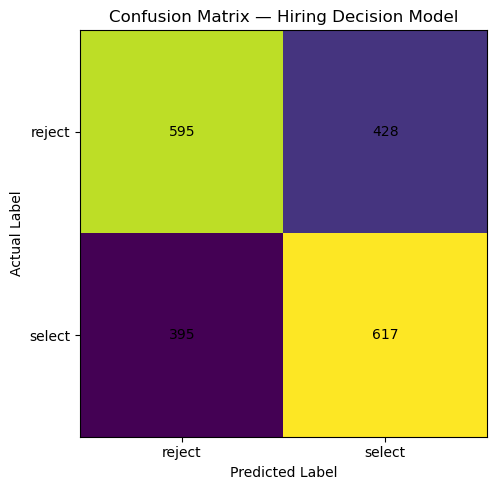


📌 SAMPLE MODEL PREDICTION
---------------------------------------------------------------------------
Candidate            : Jason Jones
Actual Decision      : reject
Predicted Decision   : reject
Prediction Confidence: 52.56%

📌 MODEL FEATURE IMPORTANCE
---------------------------------------------------------------------------


,Feature,Coefficient,Absolute_Importance
0,text_similarity_score,-0.011451,0.011451
4,Transcript_Length,0.000423,0.000423
2,Resume_Length,-0.000387,0.000387
3,JD_Length,0.000065,0.000065
1,skill_match_score,0.000062,0.000062



✅ Machine learning model completed successfully.


In [24]:
# ============================================================
# 9. MACHINE LEARNING — HIRING DECISION PREDICTION
# ============================================================

print("=" * 75)
print("MACHINE LEARNING — HIRING DECISION PREDICTION")
print("=" * 75)


# ============================================================
# 9.1 IMPORT REQUIRED LIBRARIES
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# ============================================================
# 9.2 CREATE ML FEATURES
# ============================================================

# IMPORTANT:
# Reason_for_decision is intentionally NOT used.
# It can leak information about the final hiring decision.

model_features = hiring_df[
    [
        "text_similarity_score",
        "skill_match_score",
        "Resume_Length",
        "JD_Length",
        "Transcript_Length"
    ]
].copy()


# ============================================================
# 9.3 TARGET VARIABLE
# ============================================================

target = hiring_df["decision"].astype(str).str.lower().str.strip()


print("\n📌 TARGET DISTRIBUTION")
print("-" * 75)

print(target.value_counts())


# ============================================================
# 9.4 ENCODE TARGET
# ============================================================

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(target)


print("\nTarget classes:")

for number, label in enumerate(label_encoder.classes_):
    print(number, "→", label)


# ============================================================
# 9.5 TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    model_features,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("\nTraining samples:", len(X_train))
print("Testing samples :", len(X_test))


# ============================================================
# 9.6 TRAIN LOGISTIC REGRESSION
# ============================================================

ml_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)


ml_model.fit(
    X_train,
    y_train
)


# ============================================================
# 9.7 PREDICTIONS
# ============================================================

y_pred = ml_model.predict(X_test)


# ============================================================
# 9.8 MODEL EVALUATION
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)


print("\n" + "=" * 75)
print("MODEL PERFORMANCE")
print("=" * 75)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")


# ============================================================
# 9.9 CLASSIFICATION REPORT
# ============================================================

print("\n📌 CLASSIFICATION REPORT")
print("-" * 75)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)


# ============================================================
# 9.10 CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7, 5))

plt.imshow(cm)

plt.title("Confusion Matrix — Hiring Decision Model")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_,
    rotation=0
)

plt.yticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()


# ============================================================
# 9.11 ADD PREDICTIONS TO DATASET
# ============================================================

all_predictions = ml_model.predict(
    model_features
)

all_probabilities = ml_model.predict_proba(
    model_features
)

hiring_df["predicted_decision"] = (
    label_encoder
    .inverse_transform(all_predictions)
)


hiring_df["prediction_confidence"] = (
    all_probabilities.max(axis=1) * 100
).round(2)


# ============================================================
# 9.12 SAMPLE PREDICTION
# ============================================================

print("\n📌 SAMPLE MODEL PREDICTION")
print("-" * 75)

sample = hiring_df.iloc[0]

print("Candidate            :", sample["Name"])
print("Actual Decision      :", sample["decision"])
print("Predicted Decision   :", sample["predicted_decision"])
print(
    "Prediction Confidence:",
    f"{sample['prediction_confidence']}%"
)


# ============================================================
# 9.13 FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({
    "Feature": model_features.columns,
    "Coefficient": ml_model.coef_[0]
})

feature_importance["Absolute_Importance"] = (
    feature_importance["Coefficient"]
    .abs()
)

feature_importance = (
    feature_importance
    .sort_values(
        "Absolute_Importance",
        ascending=False
    )
)

print("\n📌 MODEL FEATURE IMPORTANCE")
print("-" * 75)

display(feature_importance)


print("\n✅ Machine learning model completed successfully.")

In [25]:
# ============================================================
# 10. CANDIDATE RANKING & RECOMMENDATION ENGINE
# ============================================================

print("=" * 75)
print("CANDIDATE RANKING & RECOMMENDATION ENGINE")
print("=" * 75)


# ============================================================
# 10.1 ML CONFIDENCE FOR SELECT CLASS
# ============================================================

# Find the encoded value corresponding to "select"
select_class_index = None

for index, label in enumerate(label_encoder.classes_):
    if label == "select":
        select_class_index = index
        break


# ------------------------------------------------------------
# If "select" exists, calculate selection probability
# ------------------------------------------------------------

if select_class_index is not None:

    hiring_df["selection_probability"] = (
        ml_model
        .predict_proba(model_features)[:, select_class_index]
        * 100
    ).round(2)

else:

    hiring_df["selection_probability"] = 0.0


# ============================================================
# 10.2 FINAL CANDIDATE SCORE
# ============================================================

# Weight design:
#
# 45% → Overall Resume-JD Match
# 35% → Skill Match
# 20% → ML Selection Probability

hiring_df["candidate_score"] = (
    0.45 * hiring_df["overall_match_score"]
    +
    0.35 * hiring_df["skill_match_score"]
    +
    0.20 * hiring_df["selection_probability"]
).round(2)


# ============================================================
# 10.3 RECOMMENDATION FUNCTION
# ============================================================

def generate_recommendation(row):

    score = row["candidate_score"]

    if score >= 80:
        return "Highly Recommended"

    elif score >= 65:
        return "Recommended"

    elif score >= 50:
        return "Consider"

    else:
        return "Not Recommended"


hiring_df["recommendation"] = hiring_df.apply(
    generate_recommendation,
    axis=1
)


# ============================================================
# 10.4 RANK CANDIDATES
# ============================================================

hiring_df = (
    hiring_df
    .sort_values(
        "candidate_score",
        ascending=False
    )
    .reset_index(drop=True)
)


# Candidate rank

hiring_df["candidate_rank"] = (
    np.arange(1, len(hiring_df) + 1)
)


# ============================================================
# 10.5 TOP 20 CANDIDATES
# ============================================================

ranking_columns = [
    "candidate_rank",
    "Name",
    "Role",
    "skill_match_score",
    "text_similarity_score",
    "overall_match_score",
    "selection_probability",
    "candidate_score",
    "recommendation"
]

top_20_candidates = hiring_df[
    ranking_columns
].head(20)


print("\n📌 TOP 20 CANDIDATES")
print("-" * 75)

display(top_20_candidates)


# ============================================================
# 10.6 RECOMMENDATION DISTRIBUTION
# ============================================================

print("\n📌 RECOMMENDATION DISTRIBUTION")
print("-" * 75)

print(
    hiring_df["recommendation"]
    .value_counts()
)


# ============================================================
# 10.7 TOP CANDIDATE PROFILE
# ============================================================

top_candidate = hiring_df.iloc[0]

print("\n" + "=" * 75)
print("🏆 TOP CANDIDATE")
print("=" * 75)

print("Rank                 :", top_candidate["candidate_rank"])
print("Name                 :", top_candidate["Name"])
print("Role                 :", top_candidate["Role"])

print(
    "Candidate Score      :",
    f"{top_candidate['candidate_score']}%"
)

print(
    "Overall Match        :",
    f"{top_candidate['overall_match_score']}%"
)

print(
    "Skill Match          :",
    f"{top_candidate['skill_match_score']}%"
)

print(
    "Text Similarity      :",
    f"{top_candidate['text_similarity_score']}%"
)

print(
    "Selection Probability:",
    f"{top_candidate['selection_probability']}%"
)

print(
    "Recommendation       :",
    top_candidate["recommendation"]
)

print("\nMatched Skills:")
print(top_candidate["matched_skills"])

print("\nMissing Skills:")
print(top_candidate["missing_skills"])


# ============================================================
# 10.8 SAVE RANKING OUTPUT
# ============================================================

ranking_output = hiring_df[
    [
        "candidate_rank",
        "ID",
        "Name",
        "Role",
        "skill_match_score",
        "text_similarity_score",
        "overall_match_score",
        "selection_probability",
        "candidate_score",
        "recommendation",
        "matched_skills",
        "missing_skills"
    ]
].copy()


ranking_output.to_csv(
    "outputs/candidate_ranking.csv",
    index=False
)


print("\n✅ Candidate ranking saved:")
print("outputs/candidate_ranking.csv")

print("\n🚀 Candidate ranking engine completed successfully.")

CANDIDATE RANKING & RECOMMENDATION ENGINE

📌 TOP 20 CANDIDATES
---------------------------------------------------------------------------


,candidate_rank,Name,Role,skill_match_score,text_similarity_score,overall_match_score,selection_probability,candidate_score,recommendation
0,1,Bhavani,Digital Marketing Specialist,100.0,33.84,60.30,50.23,72.18,Recommended
1,2,Jack Wilson,UI Engineer,100.0,26.16,55.70,60.01,72.07,Recommended
2,3,Frank Wilson,UI Engineer,100.0,23.56,54.14,62.57,71.88,Recommended
3,4,Jack Johnson,UI Engineer,100.0,19.10,51.46,67.90,71.74,Recommended
4,5,Ivy Smith,Product Manager,100.0,22.34,53.40,63.40,71.71,Recommended
5,6,Eve Smith,UI Engineer,100.0,27.19,56.31,54.88,71.32,Recommended
6,7,Bob Wilson,Product Manager,100.0,26.28,55.77,55.13,71.12,Recommended
7,8,Alice Taylor,UI Engineer,100.0,21.46,52.88,61.63,71.12,Recommended
8,9,Charlie Miller,Product Manager,100.0,19.76,51.86,63.72,71.08,Recommended
9,10,Alice Wilson,UI Engineer,100.0,25.42,55.25,55.71,71.00,Recommended



📌 RECOMMENDATION DISTRIBUTION
---------------------------------------------------------------------------
recommendation
Not Recommended    8828
Recommended         838
Consider            508
Name: count, dtype: int64

🏆 TOP CANDIDATE
Rank                 : 1
Name                 : Bhavani
Role                 : Digital Marketing Specialist
Candidate Score      : 72.18%
Overall Match        : 60.3%
Skill Match          : 100.0%
Text Similarity      : 33.84%
Selection Probability: 50.23%
Recommendation       : Recommended

Matched Skills:
['data analysis']

Missing Skills:
[]

✅ Candidate ranking saved:
outputs/candidate_ranking.csv

🚀 Candidate ranking engine completed successfully.


In [26]:
# ============================================================
# 11. EXPLAINABLE AI — CANDIDATE ANALYSIS
# ============================================================

print("=" * 75)
print("EXPLAINABLE AI — CANDIDATE ANALYSIS")
print("=" * 75)


# ============================================================
# 11.1 GENERATE CANDIDATE STRENGTHS
# ============================================================

def generate_strengths(row):

    strengths = []

    # Skill strength
    if row["skill_match_score"] >= 75:
        strengths.append(
            "Strong alignment with required technical skills"
        )

    elif row["skill_match_score"] >= 50:
        strengths.append(
            "Good alignment with required technical skills"
        )

    # Resume-JD similarity
    if row["text_similarity_score"] >= 70:
        strengths.append(
            "Resume content strongly matches the job description"
        )

    elif row["text_similarity_score"] >= 50:
        strengths.append(
            "Resume content shows reasonable job relevance"
        )

    # Selection probability
    if row["selection_probability"] >= 75:
        strengths.append(
            "High predicted probability of selection"
        )

    # Matched skills
    if len(row["matched_skills"]) >= 5:
        strengths.append(
            f"Multiple relevant skills matched ({len(row['matched_skills'])})"
        )

    elif len(row["matched_skills"]) > 0:
        strengths.append(
            f"{len(row['matched_skills'])} relevant skills matched"
        )

    # Overall score
    if row["overall_match_score"] >= 75:
        strengths.append(
            "Excellent overall resume-job alignment"
        )

    return strengths


# ============================================================
# 11.2 GENERATE SKILL GAPS
# ============================================================

def generate_skill_gaps(row):

    gaps = []

    missing = row["missing_skills"]

    if len(missing) > 0:

        for skill in missing[:8]:
            gaps.append(
                f"Missing required skill: {skill}"
            )

    if row["skill_match_score"] < 50:

        gaps.append(
            "Overall technical skill alignment is relatively low"
        )

    if row["text_similarity_score"] < 50:

        gaps.append(
            "Resume content has limited similarity with the job description"
        )

    return gaps


# ============================================================
# 11.3 GENERATE FINAL EXPLANATION
# ============================================================

def generate_explanation(row):

    strengths = generate_strengths(row)
    gaps = generate_skill_gaps(row)

    if row["candidate_score"] >= 80:

        summary = (
            "This candidate is a strong match and should be "
            "prioritized for further evaluation."
        )

    elif row["candidate_score"] >= 65:

        summary = (
            "This candidate shows good potential and "
            "is suitable for further evaluation."
        )

    elif row["candidate_score"] >= 50:

        summary = (
            "This candidate has partial alignment but "
            "should be reviewed carefully."
        )

    else:

        summary = (
            "This candidate has limited alignment with "
            "the current job requirements."
        )

    return summary, strengths, gaps


# ============================================================
# 11.4 APPLY EXPLANATION ENGINE
# ============================================================

explanations = hiring_df.apply(
    generate_explanation,
    axis=1
)


hiring_df["explanation_summary"] = [
    item[0] for item in explanations
]

hiring_df["candidate_strengths"] = [
    item[1] for item in explanations
]

hiring_df["skill_gaps"] = [
    item[2] for item in explanations
]


# ============================================================
# 11.5 TOP CANDIDATE EXPLANATION
# ============================================================

top_candidate = hiring_df.iloc[0]


print("\n" + "=" * 75)
print("🏆 TOP CANDIDATE EXPLANATION")
print("=" * 75)

print(
    "\nCandidate:",
    top_candidate["Name"]
)

print(
    "Role:",
    top_candidate["Role"]
)

print(
    "Final Score:",
    f"{top_candidate['candidate_score']}%"
)

print(
    "\n🧠 Decision Explanation:"
)

print(
    top_candidate["explanation_summary"]
)


print("\n💪 Candidate Strengths:")

if top_candidate["candidate_strengths"]:

    for strength in top_candidate["candidate_strengths"]:
        print("✓", strength)

else:

    print("No major strengths identified.")


print("\n⚠️ Skill Gaps:")

if top_candidate["skill_gaps"]:

    for gap in top_candidate["skill_gaps"]:
        print("•", gap)

else:

    print("No major skill gaps identified.")


print("\n🔑 Matched Skills:")

if top_candidate["matched_skills"]:

    print(
        ", ".join(
            top_candidate["matched_skills"]
        )
    )

else:

    print("No direct skill matches found.")


print("\n❌ Missing Skills:")

if top_candidate["missing_skills"]:

    print(
        ", ".join(
            top_candidate["missing_skills"]
        )
    )

else:

    print("No major missing skills.")


# ============================================================
# 11.6 EXPLANATION DATASET
# ============================================================

explainable_output = hiring_df[
    [
        "candidate_rank",
        "ID",
        "Name",
        "Role",
        "candidate_score",
        "recommendation",
        "explanation_summary",
        "candidate_strengths",
        "matched_skills",
        "missing_skills",
        "skill_gaps"
    ]
].copy()


print("\n" + "=" * 75)
print("EXPLAINABLE AI COMPLETED")
print("=" * 75)

print(
    "Candidates explained:",
    len(explainable_output)
)

print(
    "\n✅ Every candidate now has an interpretable "
    "ranking explanation."
)

EXPLAINABLE AI — CANDIDATE ANALYSIS

🏆 TOP CANDIDATE EXPLANATION

Candidate: Bhavani
Role: Digital Marketing Specialist
Final Score: 72.18%

🧠 Decision Explanation:
This candidate shows good potential and is suitable for further evaluation.

💪 Candidate Strengths:
✓ Strong alignment with required technical skills
✓ 1 relevant skills matched

⚠️ Skill Gaps:
• Resume content has limited similarity with the job description

🔑 Matched Skills:
data analysis

❌ Missing Skills:
No major missing skills.

EXPLAINABLE AI COMPLETED
Candidates explained: 10174

✅ Every candidate now has an interpretable ranking explanation.


SKILL & TEXT VISUALIZATION

📌 TOP RESUME SKILLS
---------------------------------------------------------------------------


,Skill,Count
0,python,5116
1,github,3607
2,aws,2921
3,machine learning,2506
4,sql,2419
5,azure,2408
6,data analysis,2330
7,java,2327
8,mysql,2110
9,tableau,2072



📌 TOP JOB REQUIREMENT SKILLS
---------------------------------------------------------------------------


,Skill,Count
0,machine learning,1089
1,python,657
2,data science,623
3,data analysis,615
4,aws,538
5,azure,402
6,java,392
7,docker,322
8,data visualization,311
9,javascript,307


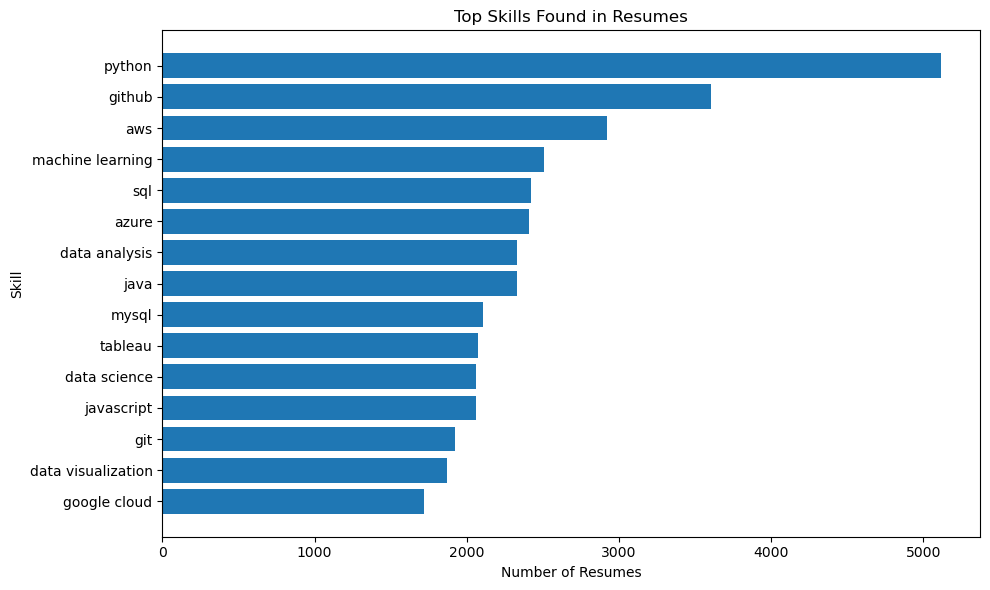

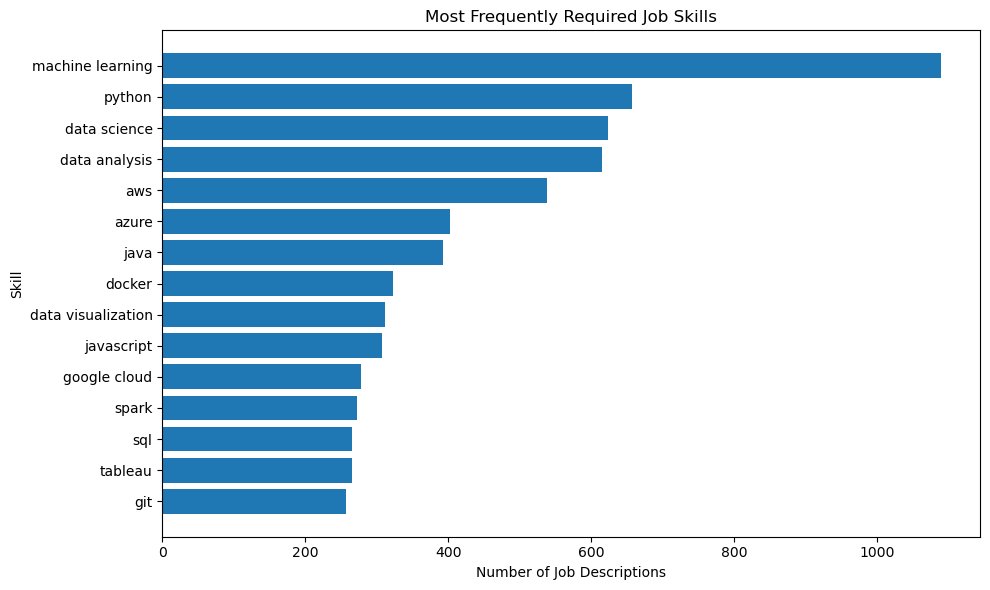

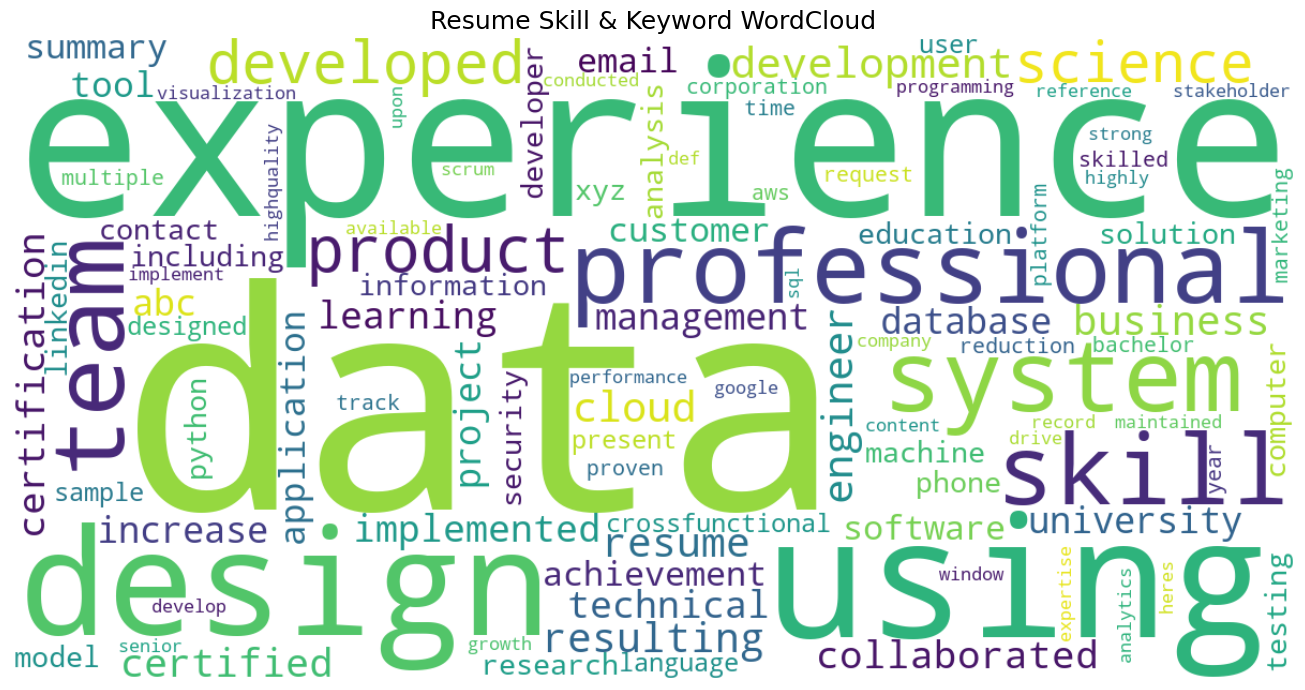

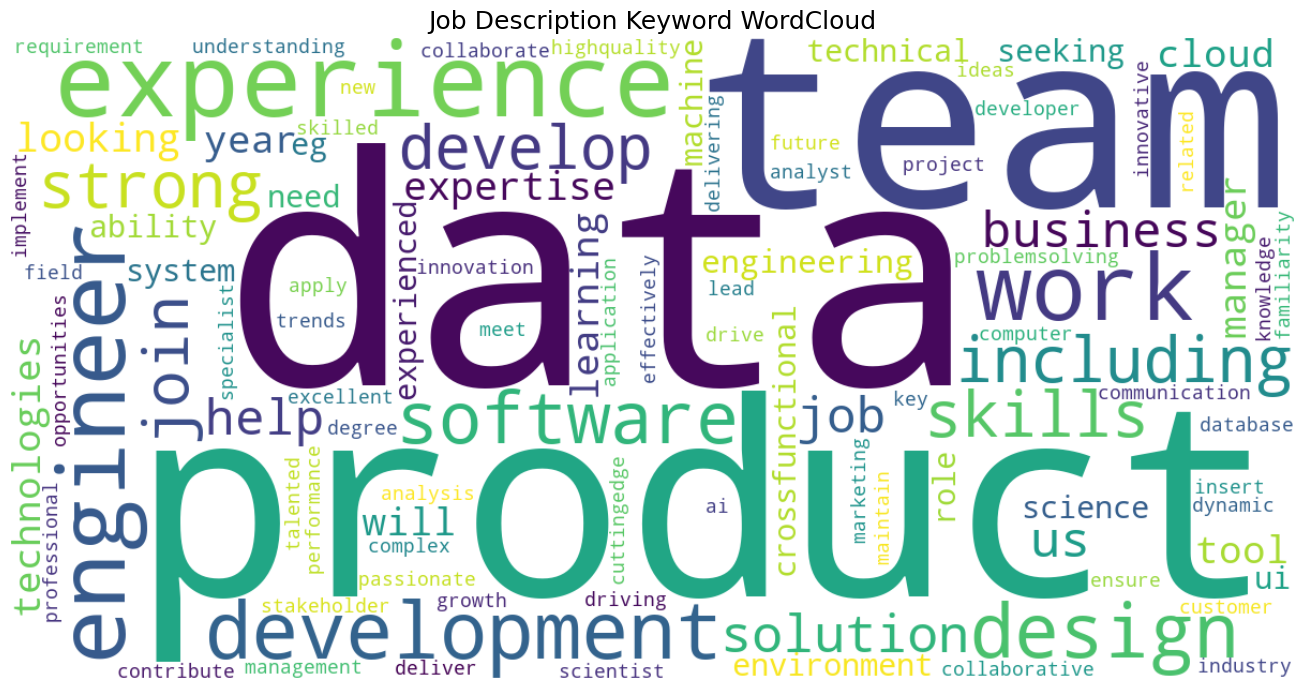


📌 TOP SKILL DEMAND GAPS
---------------------------------------------------------------------------


,Skill,Resume_Count,JD_Count,Demand_Gap
0,sklearn,1,0,-1
1,rest api,6,0,-6
2,artificial intelligence,242,186,-56
3,typescript,157,9,-148
4,mlops,237,83,-154
5,model deployment,182,4,-178
6,plotly,190,0,-190
7,hive,215,16,-199
8,nlp,279,64,-215
9,flask,237,1,-236



✅ SKILL VISUALIZATION COMPLETED


In [27]:
# ============================================================
# 12. SKILL & TEXT VISUALIZATION
# ============================================================

print("=" * 75)
print("SKILL & TEXT VISUALIZATION")
print("=" * 75)


# ============================================================
# 12.1 IMPORT WORDCLOUD
# ============================================================

from wordcloud import WordCloud
from collections import Counter


# ============================================================
# 12.2 COLLECT RESUME SKILLS
# ============================================================

resume_skill_counter = Counter()

for skills in hiring_df["resume_skills"]:
    resume_skill_counter.update(skills)


# ============================================================
# 12.3 COLLECT JOB DESCRIPTION SKILLS
# ============================================================

jd_skill_counter = Counter()

for skills in hiring_df["jd_skills"]:
    jd_skill_counter.update(skills)


# ============================================================
# 12.4 TOP RESUME SKILLS
# ============================================================

top_resume_skills = (
    pd.DataFrame(
        resume_skill_counter.most_common(15),
        columns=["Skill", "Count"]
    )
)


print("\n📌 TOP RESUME SKILLS")
print("-" * 75)

display(top_resume_skills)


# ============================================================
# 12.5 TOP JOB REQUIREMENT SKILLS
# ============================================================

top_jd_skills = (
    pd.DataFrame(
        jd_skill_counter.most_common(15),
        columns=["Skill", "Count"]
    )
)


print("\n📌 TOP JOB REQUIREMENT SKILLS")
print("-" * 75)

display(top_jd_skills)


# ============================================================
# 12.6 RESUME SKILL BAR CHART
# ============================================================

plt.figure(figsize=(10, 6))

plot_data = (
    top_resume_skills
    .sort_values("Count")
)

plt.barh(
    plot_data["Skill"],
    plot_data["Count"]
)

plt.title("Top Skills Found in Resumes")
plt.xlabel("Number of Resumes")
plt.ylabel("Skill")

plt.tight_layout()
plt.show()


# ============================================================
# 12.7 JOB REQUIREMENT SKILL BAR CHART
# ============================================================

plt.figure(figsize=(10, 6))

plot_data = (
    top_jd_skills
    .sort_values("Count")
)

plt.barh(
    plot_data["Skill"],
    plot_data["Count"]
)

plt.title("Most Frequently Required Job Skills")
plt.xlabel("Number of Job Descriptions")
plt.ylabel("Skill")

plt.tight_layout()
plt.show()


# ============================================================
# 12.8 RESUME WORDCLOUD
# ============================================================

resume_text = " ".join(
    hiring_df["clean_resume"]
    .astype(str)
)


resume_wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=100,
    collocations=False
).generate(resume_text)


plt.figure(figsize=(14, 7))

plt.imshow(
    resume_wordcloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.title(
    "Resume Skill & Keyword WordCloud",
    fontsize=18
)

plt.tight_layout()
plt.show()


# ============================================================
# 12.9 JOB DESCRIPTION WORDCLOUD
# ============================================================

jd_text = " ".join(
    hiring_df["clean_job_description"]
    .astype(str)
)


jd_wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=100,
    collocations=False
).generate(jd_text)


plt.figure(figsize=(14, 7))

plt.imshow(
    jd_wordcloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.title(
    "Job Description Keyword WordCloud",
    fontsize=18
)

plt.tight_layout()
plt.show()


# ============================================================
# 12.10 SKILL DEMAND GAP
# ============================================================

skill_gap_data = []

all_skills = set(
    resume_skill_counter.keys()
).union(
    jd_skill_counter.keys()
)


for skill in all_skills:

    resume_count = resume_skill_counter.get(
        skill,
        0
    )

    jd_count = jd_skill_counter.get(
        skill,
        0
    )

    skill_gap_data.append(
        [
            skill,
            resume_count,
            jd_count,
            jd_count - resume_count
        ]
    )


skill_gap_df = pd.DataFrame(
    skill_gap_data,
    columns=[
        "Skill",
        "Resume_Count",
        "JD_Count",
        "Demand_Gap"
    ]
)


skill_gap_df = (
    skill_gap_df
    .sort_values(
        "Demand_Gap",
        ascending=False
    )
    .reset_index(drop=True)
)


print("\n📌 TOP SKILL DEMAND GAPS")
print("-" * 75)

display(
    skill_gap_df.head(15)
)


print("\n" + "=" * 75)
print("✅ SKILL VISUALIZATION COMPLETED")
print("=" * 75)

In [28]:
# ============================================================
# 13. CANDIDATE PROFILE & RECRUITER SUMMARY
# ============================================================

print("=" * 75)
print("CANDIDATE PROFILE & RECRUITER SUMMARY")
print("=" * 75)


# ============================================================
# 13.1 CONVERT SKILL LISTS INTO READABLE TEXT
# ============================================================

hiring_df["matched_skills_text"] = (
    hiring_df["matched_skills"]
    .apply(
        lambda x: ", ".join(x)
        if len(x) > 0
        else "None"
    )
)


hiring_df["missing_skills_text"] = (
    hiring_df["missing_skills"]
    .apply(
        lambda x: ", ".join(x)
        if len(x) > 0
        else "None"
    )
)


# ============================================================
# 13.2 CREATE RECRUITER-FRIENDLY PROFILE
# ============================================================

recruiter_profile = hiring_df[
    [
        "candidate_rank",
        "ID",
        "Name",
        "Role",
        "decision",
        "predicted_decision",
        "prediction_confidence",
        "skill_match_score",
        "text_similarity_score",
        "overall_match_score",
        "selection_probability",
        "candidate_score",
        "recommendation",
        "matched_skills_text",
        "missing_skills_text",
        "explanation_summary"
    ]
].copy()


# ============================================================
# 13.3 FINAL SORTING
# ============================================================

recruiter_profile = (
    recruiter_profile
    .sort_values(
        "candidate_score",
        ascending=False
    )
    .reset_index(drop=True)
)


# ============================================================
# 13.4 DISPLAY TOP 15
# ============================================================

print("\n📌 TOP 15 RECRUITER RECOMMENDATIONS")
print("-" * 75)

display(
    recruiter_profile.head(15)
)


# ============================================================
# 13.5 SELECTED CANDIDATES
# ============================================================

selected_candidates = recruiter_profile[
    recruiter_profile["recommendation"].isin(
        [
            "Highly Recommended",
            "Recommended"
        ]
    )
].copy()


print("\n📌 RECOMMENDED CANDIDATES")
print("-" * 75)

print(
    "Total recommended:",
    len(selected_candidates)
)

display(
    selected_candidates.head(20)
)


# ============================================================
# 13.6 FINAL DATASET SUMMARY
# ============================================================

print("\n" + "=" * 75)
print("RECRUITMENT ANALYTICS SUMMARY")
print("=" * 75)

print(
    "Total candidates       :",
    len(recruiter_profile)
)

print(
    "Highly Recommended     :",
    (recruiter_profile["recommendation"] == "Highly Recommended").sum()
)

print(
    "Recommended            :",
    (recruiter_profile["recommendation"] == "Recommended").sum()
)

print(
    "Consider               :",
    (recruiter_profile["recommendation"] == "Consider").sum()
)

print(
    "Not Recommended        :",
    (recruiter_profile["recommendation"] == "Not Recommended").sum()
)


print(
    "\nAverage candidate score:",
    round(
        recruiter_profile["candidate_score"].mean(),
        2
    )
)


print(
    "Average skill match    :",
    round(
        recruiter_profile["skill_match_score"].mean(),
        2
    ),
    "%"
)


print(
    "Average text similarity:",
    round(
        recruiter_profile["text_similarity_score"].mean(),
        2
    ),
    "%"
)


# ============================================================
# 13.7 SAVE RECRUITER DATA
# ============================================================

recruiter_profile.to_csv(
    "outputs/recruiter_candidate_profiles.csv",
    index=False
)


print("\n✅ Recruiter profile dataset saved:")
print("outputs/recruiter_candidate_profiles.csv")

print("\n🚀 Candidate profile generation completed successfully.")

CANDIDATE PROFILE & RECRUITER SUMMARY

📌 TOP 15 RECRUITER RECOMMENDATIONS
---------------------------------------------------------------------------


,candidate_rank,ID,Name,Role,decision,predicted_decision,prediction_confidence,skill_match_score,text_similarity_score,overall_match_score,selection_probability,candidate_score,recommendation,matched_skills_text,missing_skills_text,explanation_summary
0,1,VAMSKR184,Bhavani,Digital Marketing Specialist,select,select,50.23,100.0,33.84,60.30,50.23,72.18,Recommended,data analysis,None,This candidate shows good potential and is sui...
1,2,uppaup315,Jack Wilson,UI Engineer,select,select,60.01,100.0,26.16,55.70,60.01,72.07,Recommended,javascript,None,This candidate shows good potential and is sui...
2,3,uppaup288,Frank Wilson,UI Engineer,select,select,62.57,100.0,23.56,54.14,62.57,71.88,Recommended,"git, javascript",None,This candidate shows good potential and is sui...
3,4,uppaup408,Jack Johnson,UI Engineer,select,select,67.90,100.0,19.10,51.46,67.90,71.74,Recommended,"git, javascript",None,This candidate shows good potential and is sui...
4,5,uppaup400,Ivy Smith,Product Manager,select,select,63.40,100.0,22.34,53.40,63.40,71.71,Recommended,data analysis,None,This candidate shows good potential and is sui...
5,6,uppaup156,Eve Smith,UI Engineer,select,select,54.88,100.0,27.19,56.31,54.88,71.32,Recommended,javascript,None,This candidate shows good potential and is sui...
6,7,uppaup414,Bob Wilson,Product Manager,select,select,55.13,100.0,26.28,55.77,55.13,71.12,Recommended,data analysis,None,This candidate shows good potential and is sui...
7,8,uppaup198,Alice Taylor,UI Engineer,select,select,61.63,100.0,21.46,52.88,61.63,71.12,Recommended,javascript,None,This candidate shows good potential and is sui...
8,9,uppaup500,Charlie Miller,Product Manager,select,select,63.72,100.0,19.76,51.86,63.72,71.08,Recommended,"power bi, tableau",None,This candidate shows good potential and is sui...
9,10,uppaup173,Alice Wilson,UI Engineer,select,select,55.71,100.0,25.42,55.25,55.71,71.00,Recommended,"git, javascript",None,This candidate shows good potential and is sui...



📌 RECOMMENDED CANDIDATES
---------------------------------------------------------------------------
Total recommended: 838


,candidate_rank,ID,Name,Role,decision,predicted_decision,prediction_confidence,skill_match_score,text_similarity_score,overall_match_score,selection_probability,candidate_score,recommendation,matched_skills_text,missing_skills_text,explanation_summary
0,1,VAMSKR184,Bhavani,Digital Marketing Specialist,select,select,50.23,100.0,33.84,60.30,50.23,72.18,Recommended,data analysis,None,This candidate shows good potential and is sui...
1,2,uppaup315,Jack Wilson,UI Engineer,select,select,60.01,100.0,26.16,55.70,60.01,72.07,Recommended,javascript,None,This candidate shows good potential and is sui...
2,3,uppaup288,Frank Wilson,UI Engineer,select,select,62.57,100.0,23.56,54.14,62.57,71.88,Recommended,"git, javascript",None,This candidate shows good potential and is sui...
3,4,uppaup408,Jack Johnson,UI Engineer,select,select,67.90,100.0,19.10,51.46,67.90,71.74,Recommended,"git, javascript",None,This candidate shows good potential and is sui...
4,5,uppaup400,Ivy Smith,Product Manager,select,select,63.40,100.0,22.34,53.40,63.40,71.71,Recommended,data analysis,None,This candidate shows good potential and is sui...
5,6,uppaup156,Eve Smith,UI Engineer,select,select,54.88,100.0,27.19,56.31,54.88,71.32,Recommended,javascript,None,This candidate shows good potential and is sui...
6,7,uppaup414,Bob Wilson,Product Manager,select,select,55.13,100.0,26.28,55.77,55.13,71.12,Recommended,data analysis,None,This candidate shows good potential and is sui...
7,8,uppaup198,Alice Taylor,UI Engineer,select,select,61.63,100.0,21.46,52.88,61.63,71.12,Recommended,javascript,None,This candidate shows good potential and is sui...
8,9,uppaup500,Charlie Miller,Product Manager,select,select,63.72,100.0,19.76,51.86,63.72,71.08,Recommended,"power bi, tableau",None,This candidate shows good potential and is sui...
9,10,uppaup173,Alice Wilson,UI Engineer,select,select,55.71,100.0,25.42,55.25,55.71,71.00,Recommended,"git, javascript",None,This candidate shows good potential and is sui...



RECRUITMENT ANALYTICS SUMMARY
Total candidates       : 10174
Highly Recommended     : 0
Recommended            : 838
Consider               : 508
Not Recommended        : 8828

Average candidate score: 20.37
Average skill match    : 15.18 %
Average text similarity: 8.63 %

✅ Recruiter profile dataset saved:
outputs/recruiter_candidate_profiles.csv

🚀 Candidate profile generation completed successfully.


In [29]:
# ============================================================
# 13. CANDIDATE PROFILE & RECRUITER SUMMARY
# ============================================================

print("=" * 75)
print("CANDIDATE PROFILE & RECRUITER SUMMARY")
print("=" * 75)


# ============================================================
# 13.1 CREATE READABLE SKILL COLUMNS
# ============================================================

hiring_df["matched_skills_text"] = hiring_df[
    "matched_skills"
].apply(
    lambda x: ", ".join(x) if len(x) > 0 else "None"
)


hiring_df["missing_skills_text"] = hiring_df[
    "missing_skills"
].apply(
    lambda x: ", ".join(x) if len(x) > 0 else "None"
)


# ============================================================
# 13.2 SAFETY CHECK FOR EXPLANATION COLUMN
# ============================================================

if "explanation_summary" not in hiring_df.columns:

    hiring_df["explanation_summary"] = hiring_df.apply(
        lambda row: (
            f"Candidate has an overall match score of "
            f"{row['overall_match_score']}%, with a skill "
            f"match of {row['skill_match_score']}% and "
            f"text similarity of "
            f"{row['text_similarity_score']}%."
        ),
        axis=1
    )


# ============================================================
# 13.3 SAFETY CHECK FOR PREDICTION COLUMNS
# ============================================================

if "predicted_decision" not in hiring_df.columns:

    all_predictions = ml_model.predict(
        model_features
    )

    hiring_df["predicted_decision"] = (
        label_encoder.inverse_transform(
            all_predictions
        )
    )


if "prediction_confidence" not in hiring_df.columns:

    all_probabilities = ml_model.predict_proba(
        model_features
    )

    hiring_df["prediction_confidence"] = (
        all_probabilities.max(axis=1) * 100
    ).round(2)


# ============================================================
# 13.4 SAFETY CHECK FOR SELECTION PROBABILITY
# ============================================================

if "selection_probability" not in hiring_df.columns:

    select_class_index = None

    for index, label in enumerate(
        label_encoder.classes_
    ):

        if label == "select":
            select_class_index = index
            break


    if select_class_index is not None:

        hiring_df["selection_probability"] = (
            ml_model.predict_proba(
                model_features
            )[:, select_class_index] * 100
        ).round(2)

    else:

        hiring_df["selection_probability"] = 0.0


# ============================================================
# 13.5 SAFETY CHECK FOR CANDIDATE SCORE
# ============================================================

if "candidate_score" not in hiring_df.columns:

    hiring_df["candidate_score"] = (
        0.45 * hiring_df["overall_match_score"]
        +
        0.35 * hiring_df["skill_match_score"]
        +
        0.20 * hiring_df["selection_probability"]
    ).round(2)


# ============================================================
# 13.6 SAFETY CHECK FOR RECOMMENDATION
# ============================================================

if "recommendation" not in hiring_df.columns:

    def recommendation_function(score):

        if score >= 80:
            return "Highly Recommended"

        elif score >= 65:
            return "Recommended"

        elif score >= 50:
            return "Consider"

        else:
            return "Not Recommended"


    hiring_df["recommendation"] = (
        hiring_df["candidate_score"]
        .apply(recommendation_function)
    )


# ============================================================
# 13.7 CREATE RANK
# ============================================================

hiring_df = (
    hiring_df
    .sort_values(
        "candidate_score",
        ascending=False
    )
    .reset_index(drop=True)
)


hiring_df["candidate_rank"] = (
    np.arange(1, len(hiring_df) + 1)
)


# ============================================================
# 13.8 CREATE RECRUITER PROFILE
# ============================================================

recruiter_profile = hiring_df[
    [
        "candidate_rank",
        "ID",
        "Name",
        "Role",
        "decision",
        "predicted_decision",
        "prediction_confidence",
        "skill_match_score",
        "text_similarity_score",
        "overall_match_score",
        "selection_probability",
        "candidate_score",
        "recommendation",
        "matched_skills_text",
        "missing_skills_text",
        "explanation_summary"
    ]
].copy()


# ============================================================
# 13.9 DISPLAY TOP 15
# ============================================================

print("\n📌 TOP 15 RECRUITER RECOMMENDATIONS")
print("-" * 75)

display(
    recruiter_profile.head(15)
)


# ============================================================
# 13.10 RECOMMENDED CANDIDATES
# ============================================================

selected_candidates = recruiter_profile[
    recruiter_profile["recommendation"].isin(
        [
            "Highly Recommended",
            "Recommended"
        ]
    )
].copy()


print("\n📌 RECOMMENDED CANDIDATES")
print("-" * 75)

print(
    "Total recommended:",
    len(selected_candidates)
)

display(
    selected_candidates.head(20)
)


# ============================================================
# 13.11 SUMMARY
# ============================================================

print("\n" + "=" * 75)
print("RECRUITMENT ANALYTICS SUMMARY")
print("=" * 75)

print(
    "Total candidates       :",
    len(recruiter_profile)
)

print(
    "Highly Recommended     :",
    (
        recruiter_profile["recommendation"]
        == "Highly Recommended"
    ).sum()
)

print(
    "Recommended            :",
    (
        recruiter_profile["recommendation"]
        == "Recommended"
    ).sum()
)

print(
    "Consider               :",
    (
        recruiter_profile["recommendation"]
        == "Consider"
    ).sum()
)

print(
    "Not Recommended        :",
    (
        recruiter_profile["recommendation"]
        == "Not Recommended"
    ).sum()
)

print(
    "\nAverage candidate score:",
    round(
        recruiter_profile[
            "candidate_score"
        ].mean(),
        2
    )
)

print(
    "Average skill match    :",
    round(
        recruiter_profile[
            "skill_match_score"
        ].mean(),
        2
    ),
    "%"
)

print(
    "Average text similarity:",
    round(
        recruiter_profile[
            "text_similarity_score"
        ].mean(),
        2
    ),
    "%"
)


# ============================================================
# 13.12 SAVE OUTPUT
# ============================================================

import os

os.makedirs(
    "outputs",
    exist_ok=True
)


recruiter_profile.to_csv(
    "outputs/recruiter_candidate_profiles.csv",
    index=False
)


print("\n✅ Recruiter profile saved successfully.")

print(
    "File:",
    "outputs/recruiter_candidate_profiles.csv"
)

print("\n🚀 Cell 13 completed successfully.")

CANDIDATE PROFILE & RECRUITER SUMMARY

📌 TOP 15 RECRUITER RECOMMENDATIONS
---------------------------------------------------------------------------


,candidate_rank,ID,Name,Role,decision,predicted_decision,prediction_confidence,skill_match_score,text_similarity_score,overall_match_score,selection_probability,candidate_score,recommendation,matched_skills_text,missing_skills_text,explanation_summary
0,1,VAMSKR184,Bhavani,Digital Marketing Specialist,select,select,50.23,100.0,33.84,60.30,50.23,72.18,Recommended,data analysis,None,This candidate shows good potential and is sui...
1,2,uppaup315,Jack Wilson,UI Engineer,select,select,60.01,100.0,26.16,55.70,60.01,72.07,Recommended,javascript,None,This candidate shows good potential and is sui...
2,3,uppaup288,Frank Wilson,UI Engineer,select,select,62.57,100.0,23.56,54.14,62.57,71.88,Recommended,"git, javascript",None,This candidate shows good potential and is sui...
3,4,uppaup408,Jack Johnson,UI Engineer,select,select,67.90,100.0,19.10,51.46,67.90,71.74,Recommended,"git, javascript",None,This candidate shows good potential and is sui...
4,5,uppaup400,Ivy Smith,Product Manager,select,select,63.40,100.0,22.34,53.40,63.40,71.71,Recommended,data analysis,None,This candidate shows good potential and is sui...
5,6,uppaup156,Eve Smith,UI Engineer,select,select,54.88,100.0,27.19,56.31,54.88,71.32,Recommended,javascript,None,This candidate shows good potential and is sui...
6,7,uppaup414,Bob Wilson,Product Manager,select,select,55.13,100.0,26.28,55.77,55.13,71.12,Recommended,data analysis,None,This candidate shows good potential and is sui...
7,8,uppaup198,Alice Taylor,UI Engineer,select,select,61.63,100.0,21.46,52.88,61.63,71.12,Recommended,javascript,None,This candidate shows good potential and is sui...
8,9,uppaup500,Charlie Miller,Product Manager,select,select,63.72,100.0,19.76,51.86,63.72,71.08,Recommended,"power bi, tableau",None,This candidate shows good potential and is sui...
9,10,uppaup173,Alice Wilson,UI Engineer,select,select,55.71,100.0,25.42,55.25,55.71,71.00,Recommended,"git, javascript",None,This candidate shows good potential and is sui...



📌 RECOMMENDED CANDIDATES
---------------------------------------------------------------------------
Total recommended: 838


,candidate_rank,ID,Name,Role,decision,predicted_decision,prediction_confidence,skill_match_score,text_similarity_score,overall_match_score,selection_probability,candidate_score,recommendation,matched_skills_text,missing_skills_text,explanation_summary
0,1,VAMSKR184,Bhavani,Digital Marketing Specialist,select,select,50.23,100.0,33.84,60.30,50.23,72.18,Recommended,data analysis,None,This candidate shows good potential and is sui...
1,2,uppaup315,Jack Wilson,UI Engineer,select,select,60.01,100.0,26.16,55.70,60.01,72.07,Recommended,javascript,None,This candidate shows good potential and is sui...
2,3,uppaup288,Frank Wilson,UI Engineer,select,select,62.57,100.0,23.56,54.14,62.57,71.88,Recommended,"git, javascript",None,This candidate shows good potential and is sui...
3,4,uppaup408,Jack Johnson,UI Engineer,select,select,67.90,100.0,19.10,51.46,67.90,71.74,Recommended,"git, javascript",None,This candidate shows good potential and is sui...
4,5,uppaup400,Ivy Smith,Product Manager,select,select,63.40,100.0,22.34,53.40,63.40,71.71,Recommended,data analysis,None,This candidate shows good potential and is sui...
5,6,uppaup156,Eve Smith,UI Engineer,select,select,54.88,100.0,27.19,56.31,54.88,71.32,Recommended,javascript,None,This candidate shows good potential and is sui...
6,7,uppaup414,Bob Wilson,Product Manager,select,select,55.13,100.0,26.28,55.77,55.13,71.12,Recommended,data analysis,None,This candidate shows good potential and is sui...
7,8,uppaup198,Alice Taylor,UI Engineer,select,select,61.63,100.0,21.46,52.88,61.63,71.12,Recommended,javascript,None,This candidate shows good potential and is sui...
8,9,uppaup500,Charlie Miller,Product Manager,select,select,63.72,100.0,19.76,51.86,63.72,71.08,Recommended,"power bi, tableau",None,This candidate shows good potential and is sui...
9,10,uppaup173,Alice Wilson,UI Engineer,select,select,55.71,100.0,25.42,55.25,55.71,71.00,Recommended,"git, javascript",None,This candidate shows good potential and is sui...



RECRUITMENT ANALYTICS SUMMARY
Total candidates       : 10174
Highly Recommended     : 0
Recommended            : 838
Consider               : 508
Not Recommended        : 8828

Average candidate score: 20.37
Average skill match    : 15.18 %
Average text similarity: 8.63 %

✅ Recruiter profile saved successfully.
File: outputs/recruiter_candidate_profiles.csv

🚀 Cell 13 completed successfully.


In [30]:
# ============================================================
# 14. SCORE CALIBRATION & FINAL RANKING
# ============================================================

print("=" * 75)
print("SCORE CALIBRATION & FINAL RANKING")
print("=" * 75)


# ============================================================
# 14.1 NORMALIZE THE THREE SIGNALS
# ============================================================

from sklearn.preprocessing import MinMaxScaler

score_columns = [
    "text_similarity_score",
    "skill_match_score",
    "selection_probability"
]

scaler = MinMaxScaler()

normalized_scores = scaler.fit_transform(
    hiring_df[score_columns]
)

normalized_scores = pd.DataFrame(
    normalized_scores,
    columns=[
        "normalized_text_score",
        "normalized_skill_score",
        "normalized_selection_score"
    ],
    index=hiring_df.index
)


# ============================================================
# 14.2 ADD NORMALIZED SCORES
# ============================================================

hiring_df[
    [
        "normalized_text_score",
        "normalized_skill_score",
        "normalized_selection_score"
    ]
] = normalized_scores


# ============================================================
# 14.3 CALCULATE CALIBRATED SCORE
# ============================================================

hiring_df["final_match_score"] = (
    0.45 * hiring_df["normalized_text_score"]
    +
    0.35 * hiring_df["normalized_skill_score"]
    +
    0.20 * hiring_df["normalized_selection_score"]
) * 100


hiring_df["final_match_score"] = (
    hiring_df["final_match_score"]
    .round(2)
)


# ============================================================
# 14.4 FINAL RECOMMENDATION
# ============================================================

def final_recommendation(score):

    if score >= 75:
        return "Highly Recommended"

    elif score >= 60:
        return "Recommended"

    elif score >= 40:
        return "Consider"

    else:
        return "Not Recommended"


hiring_df["final_recommendation"] = (
    hiring_df["final_match_score"]
    .apply(final_recommendation)
)


# ============================================================
# 14.5 FINAL RANK
# ============================================================

hiring_df = (
    hiring_df
    .sort_values(
        "final_match_score",
        ascending=False
    )
    .reset_index(drop=True)
)


hiring_df["final_rank"] = (
    np.arange(
        1,
        len(hiring_df) + 1
    )
)


# ============================================================
# 14.6 TOP 20 CANDIDATES
# ============================================================

final_ranking = hiring_df[
    [
        "final_rank",
        "ID",
        "Name",
        "Role",
        "text_similarity_score",
        "skill_match_score",
        "selection_probability",
        "final_match_score",
        "final_recommendation",
        "matched_skills_text",
        "missing_skills_text"
    ]
].copy()


print("\n📌 FINAL TOP 20 CANDIDATES")
print("-" * 75)

display(
    final_ranking.head(20)
)


# ============================================================
# 14.7 FINAL DISTRIBUTION
# ============================================================

print("\n📌 FINAL RECOMMENDATION DISTRIBUTION")
print("-" * 75)

print(
    hiring_df[
        "final_recommendation"
    ].value_counts()
)


# ============================================================
# 14.8 SCORE STATISTICS
# ============================================================

print("\n📌 FINAL SCORE STATISTICS")
print("-" * 75)

print(
    "Maximum score :",
    hiring_df["final_match_score"].max()
)

print(
    "Average score :",
    round(
        hiring_df["final_match_score"].mean(),
        2
    )
)

print(
    "Minimum score :",
    hiring_df["final_match_score"].min()
)


# ============================================================
# 14.9 TOP CANDIDATE
# ============================================================

top_candidate = hiring_df.iloc[0]

print("\n" + "=" * 75)
print("🏆 FINAL TOP CANDIDATE")
print("=" * 75)

print(
    "Rank:",
    top_candidate["final_rank"]
)

print(
    "Name:",
    top_candidate["Name"]
)

print(
    "Role:",
    top_candidate["Role"]
)

print(
    "Final Match Score:",
    f"{top_candidate['final_match_score']}%"
)

print(
    "Recommendation:",
    top_candidate["final_recommendation"]
)

print(
    "\nMatched Skills:",
    top_candidate["matched_skills_text"]
)

print(
    "\nMissing Skills:",
    top_candidate["missing_skills_text"]
)


# ============================================================
# 14.10 SAVE FINAL RANKING
# ============================================================

os.makedirs(
    "outputs",
    exist_ok=True
)


final_ranking.to_csv(
    "outputs/final_candidate_ranking.csv",
    index=False
)


print(
    "\n✅ Final ranking saved successfully:"
)

print(
    "outputs/final_candidate_ranking.csv"
)

print(
    "\n🚀 Score calibration completed successfully."
)

SCORE CALIBRATION & FINAL RANKING

📌 FINAL TOP 20 CANDIDATES
---------------------------------------------------------------------------


,final_rank,ID,Name,Role,text_similarity_score,skill_match_score,selection_probability,final_match_score,final_recommendation,matched_skills_text,missing_skills_text
0,1,VAMSKR184,Bhavani,Digital Marketing Specialist,33.84,100.00,50.23,86.35,Highly Recommended,data analysis,None
1,2,uppaup315,Jack Wilson,UI Engineer,26.16,100.00,60.01,79.92,Highly Recommended,javascript,None
2,3,uppaup156,Eve Smith,UI Engineer,27.19,100.00,54.88,79.70,Highly Recommended,javascript,None
3,4,VAMSKR086,Kiran,Digital Marketing Specialist,27.77,100.00,49.53,78.87,Highly Recommended,data analysis,None
4,5,uppaup414,Bob Wilson,Product Manager,26.28,100.00,55.13,78.68,Highly Recommended,data analysis,None
5,6,uppaup173,Alice Wilson,UI Engineer,25.42,100.00,55.71,77.81,Highly Recommended,"git, javascript",None
6,7,uppaup288,Frank Wilson,UI Engineer,23.56,100.00,62.57,77.53,Highly Recommended,"git, javascript",None
7,8,uppaup400,Ivy Smith,Product Manager,22.34,100.00,63.40,76.31,Highly Recommended,data analysis,None
8,9,durgba112,Kelly Henderson,Data Scientist,28.74,100.00,34.24,75.67,Highly Recommended,"deep learning, machine learning, statistics",None
9,10,elizbu323,Elizabeth Burns,Mobile App Developer,23.62,100.00,55.36,75.55,Highly Recommended,api,None



📌 FINAL RECOMMENDATION DISTRIBUTION
---------------------------------------------------------------------------
final_recommendation
Not Recommended       8310
Consider              1300
Recommended            553
Highly Recommended      11
Name: count, dtype: int64

📌 FINAL SCORE STATISTICS
---------------------------------------------------------------------------
Maximum score : 86.35
Average score : 26.34
Minimum score : 2.65

🏆 FINAL TOP CANDIDATE
Rank: 1
Name: Bhavani
Role: Digital Marketing Specialist
Final Match Score: 86.35%
Recommendation: Highly Recommended

Matched Skills: data analysis

Missing Skills: None

✅ Final ranking saved successfully:
outputs/final_candidate_ranking.csv

🚀 Score calibration completed successfully.


In [31]:
# ============================================================
# 15. RANKING QUALITY VALIDATION
# ============================================================

print("=" * 75)
print("RANKING QUALITY VALIDATION")
print("=" * 75)


# ============================================================
# 15.1 CHECK TOP CANDIDATES
# ============================================================

validation_columns = [
    "final_rank",
    "ID",
    "Name",
    "Role",
    "skill_match_score",
    "text_similarity_score",
    "selection_probability",
    "final_match_score",
    "final_recommendation",
    "matched_skills_text",
    "missing_skills_text"
]

top_candidates_validation = hiring_df[
    validation_columns
].head(20).copy()


print("\n📌 TOP 20 CANDIDATES — VALIDATION")
print("-" * 75)

display(
    top_candidates_validation
)


# ============================================================
# 15.2 CHECK SKILL MATCH DISTRIBUTION
# ============================================================

print("\n📌 SKILL MATCH DISTRIBUTION")
print("-" * 75)

print(
    hiring_df[
        "skill_match_score"
    ].describe()
)


# ============================================================
# 15.3 CHECK HOW MANY HAVE 100% MATCH
# ============================================================

perfect_skill_matches = (
    hiring_df[
        "skill_match_score"
    ] == 100
).sum()


print(
    "\nCandidates with 100% skill match:",
    perfect_skill_matches
)


print(
    "Percentage of candidates with 100% skill match:",
    round(
        perfect_skill_matches
        / len(hiring_df)
        * 100,
        2
    ),
    "%"
)


# ============================================================
# 15.4 CHECK HIGH QUALITY CANDIDATES
# ============================================================

high_quality = hiring_df[
    (
        hiring_df["skill_match_score"] >= 50
    )
    &
    (
        hiring_df["text_similarity_score"] >= 15
    )
].copy()


print(
    "\n📌 Candidates with meaningful skill + text alignment:",
    len(high_quality)
)


# ============================================================
# 15.5 CORRELATION BETWEEN COMPONENTS
# ============================================================

correlation_data = hiring_df[
    [
        "skill_match_score",
        "text_similarity_score",
        "selection_probability",
        "final_match_score"
    ]
].corr()


print("\n📌 SCORE CORRELATION")
print("-" * 75)

display(
    correlation_data
)


# ============================================================
# 15.6 ROLE-WISE PERFORMANCE
# ============================================================

role_summary = (
    hiring_df
    .groupby("Role")
    .agg(
        Candidates=("ID", "count"),
        Average_Score=("final_match_score", "mean"),
        Average_Skill_Match=("skill_match_score", "mean"),
        Average_Text_Match=("text_similarity_score", "mean")
    )
    .sort_values(
        "Average_Score",
        ascending=False
    )
    .reset_index()
)


print("\n📌 ROLE-WISE MATCH QUALITY")
print("-" * 75)

display(
    role_summary.head(15)
)


# ============================================================
# 15.7 FINAL VALIDATION
# ============================================================

print("\n" + "=" * 75)
print("VALIDATION SUMMARY")
print("=" * 75)

print(
    "Total candidates:",
    len(hiring_df)
)

print(
    "100% skill matches:",
    perfect_skill_matches
)

print(
    "Meaningful skill + text matches:",
    len(high_quality)
)

print(
    "Average final score:",
    round(
        hiring_df[
            "final_match_score"
        ].mean(),
        2
    )
)

print(
    "\n✅ Ranking quality validation completed."
)

RANKING QUALITY VALIDATION

📌 TOP 20 CANDIDATES — VALIDATION
---------------------------------------------------------------------------


,final_rank,ID,Name,Role,skill_match_score,text_similarity_score,selection_probability,final_match_score,final_recommendation,matched_skills_text,missing_skills_text
0,1,VAMSKR184,Bhavani,Digital Marketing Specialist,100.00,33.84,50.23,86.35,Highly Recommended,data analysis,None
1,2,uppaup315,Jack Wilson,UI Engineer,100.00,26.16,60.01,79.92,Highly Recommended,javascript,None
2,3,uppaup156,Eve Smith,UI Engineer,100.00,27.19,54.88,79.70,Highly Recommended,javascript,None
3,4,VAMSKR086,Kiran,Digital Marketing Specialist,100.00,27.77,49.53,78.87,Highly Recommended,data analysis,None
4,5,uppaup414,Bob Wilson,Product Manager,100.00,26.28,55.13,78.68,Highly Recommended,data analysis,None
5,6,uppaup173,Alice Wilson,UI Engineer,100.00,25.42,55.71,77.81,Highly Recommended,"git, javascript",None
6,7,uppaup288,Frank Wilson,UI Engineer,100.00,23.56,62.57,77.53,Highly Recommended,"git, javascript",None
7,8,uppaup400,Ivy Smith,Product Manager,100.00,22.34,63.40,76.31,Highly Recommended,data analysis,None
8,9,durgba112,Kelly Henderson,Data Scientist,100.00,28.74,34.24,75.67,Highly Recommended,"deep learning, machine learning, statistics",None
9,10,elizbu323,Elizabeth Burns,Mobile App Developer,100.00,23.62,55.36,75.55,Highly Recommended,api,None



📌 SKILL MATCH DISTRIBUTION
---------------------------------------------------------------------------
count    10174.000000
mean        15.176116
std         33.845885
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        100.000000
Name: skill_match_score, dtype: float64

Candidates with 100% skill match: 1180
Percentage of candidates with 100% skill match: 11.6 %

📌 Candidates with meaningful skill + text alignment: 564

📌 SCORE CORRELATION
---------------------------------------------------------------------------


,skill_match_score,text_similarity_score,selection_probability,final_match_score
skill_match_score,1.000000,0.362978,-0.086618,0.917254
text_similarity_score,0.362978,1.000000,-0.150361,0.676083
selection_probability,-0.086618,-0.150361,1.000000,0.023500
final_match_score,0.917254,0.676083,0.023500,1.000000



📌 ROLE-WISE MATCH QUALITY
---------------------------------------------------------------------------


,Role,Candidates,Average_Score,Average_Skill_Match,Average_Text_Match
0,AI Engineer,13,54.607692,46.387692,22.586154
1,Machine Learning Engineer,265,51.263962,86.223925,8.401245
2,ui engineer,132,48.684848,56.818182,16.179242
3,Cybersecurity Specialist,9,45.991111,0.000000,29.028889
4,Graphic Designer,15,45.790000,0.000000,29.642000
5,HR Specialist,12,45.212500,0.000000,27.668333
6,UI/UX Designer,7,42.405714,0.000000,25.902857
7,Network Engineer,16,41.804375,0.000000,25.154375
8,software engineer,307,35.957590,43.648208,8.775375
9,data scientist,287,35.937038,44.076760,8.805505



VALIDATION SUMMARY
Total candidates: 10174
100% skill matches: 1180
Meaningful skill + text matches: 564
Average final score: 26.34

✅ Ranking quality validation completed.


In [32]:
# ============================================================
# 16. IMPROVED SKILL MATCHING ENGINE
# ============================================================

print("=" * 75)
print("IMPROVED SKILL MATCHING ENGINE")
print("=" * 75)


# ============================================================
# 16.1 CALCULATE TRUE SKILL COVERAGE
# ============================================================

def calculate_true_skill_match(row):

    resume_skills = set(
        row["resume_skills"]
    )

    jd_skills = set(
        row["jd_skills"]
    )

    # No JD skills available
    if len(jd_skills) == 0:
        return 0.0

    matched = resume_skills.intersection(
        jd_skills
    )

    score = (
        len(matched)
        /
        len(jd_skills)
    ) * 100

    return round(
        score,
        2
    )


hiring_df["true_skill_match_score"] = (
    hiring_df.apply(
        calculate_true_skill_match,
        axis=1
    )
)


# ============================================================
# 16.2 TRUE MATCHED SKILLS
# ============================================================

def get_true_matched_skills(row):

    resume_skills = set(
        row["resume_skills"]
    )

    jd_skills = set(
        row["jd_skills"]
    )

    return sorted(
        resume_skills.intersection(
            jd_skills
        )
    )


hiring_df["true_matched_skills"] = (
    hiring_df.apply(
        get_true_matched_skills,
        axis=1
    )
)


# ============================================================
# 16.3 TRUE MISSING SKILLS
# ============================================================

def get_true_missing_skills(row):

    resume_skills = set(
        row["resume_skills"]
    )

    jd_skills = set(
        row["jd_skills"]
    )

    return sorted(
        jd_skills.difference(
            resume_skills
        )
    )


hiring_df["true_missing_skills"] = (
    hiring_df.apply(
        get_true_missing_skills,
        axis=1
    )
)


# ============================================================
# 16.4 NUMBER OF REQUIRED SKILLS
# ============================================================

hiring_df["required_skill_count"] = (
    hiring_df["jd_skills"]
    .apply(len)
)


hiring_df["matched_skill_count"] = (
    hiring_df["true_matched_skills"]
    .apply(len)
)


hiring_df["missing_skill_count"] = (
    hiring_df["true_missing_skills"]
    .apply(len)
)


# ============================================================
# 16.5 READABLE SKILLS
# ============================================================

hiring_df["true_matched_skills_text"] = (
    hiring_df["true_matched_skills"]
    .apply(
        lambda x:
        ", ".join(x)
        if len(x) > 0
        else "None"
    )
)


hiring_df["true_missing_skills_text"] = (
    hiring_df["true_missing_skills"]
    .apply(
        lambda x:
        ", ".join(x)
        if len(x) > 0
        else "None"
    )
)


# ============================================================
# 16.6 UPDATE SKILL SCORE
# ============================================================

hiring_df["skill_match_score"] = (
    hiring_df["true_skill_match_score"]
)


# ============================================================
# 16.7 DISPLAY SAMPLE
# ============================================================

skill_validation = hiring_df[
    [
        "Name",
        "Role",
        "required_skill_count",
        "matched_skill_count",
        "missing_skill_count",
        "skill_match_score",
        "true_matched_skills_text",
        "true_missing_skills_text"
    ]
].head(20)


print("\n📌 IMPROVED SKILL MATCH SAMPLE")
print("-" * 75)

display(
    skill_validation
)


# ============================================================
# 16.8 NEW SKILL STATISTICS
# ============================================================

print("\n📌 NEW SKILL MATCH STATISTICS")
print("-" * 75)

print(
    hiring_df[
        "skill_match_score"
    ].describe()
)


# ============================================================
# 16.9 NEW 100% MATCH COUNT
# ============================================================

new_perfect_matches = (
    hiring_df[
        "skill_match_score"
    ] == 100
).sum()


print(
    "\nCandidates with TRUE 100% skill match:",
    new_perfect_matches
)

print(
    "Percentage:",
    round(
        new_perfect_matches
        / len(hiring_df)
        * 100,
        2
    ),
    "%"
)


# ============================================================
# 16.10 TOP SKILL MATCH CANDIDATES
# ============================================================

top_skill_matches = hiring_df[
    [
        "Name",
        "Role",
        "required_skill_count",
        "matched_skill_count",
        "skill_match_score",
        "true_matched_skills_text",
        "true_missing_skills_text"
    ]
].sort_values(
    "skill_match_score",
    ascending=False
).head(20)


print(
    "\n📌 TOP TRUE SKILL MATCHES"
)

display(
    top_skill_matches
)


print("\n" + "=" * 75)
print("✅ IMPROVED SKILL MATCHING COMPLETED")
print("=" * 75)

IMPROVED SKILL MATCHING ENGINE

📌 IMPROVED SKILL MATCH SAMPLE
---------------------------------------------------------------------------


,Name,Role,required_skill_count,matched_skill_count,missing_skill_count,skill_match_score,true_matched_skills_text,true_missing_skills_text
0,Bhavani,Digital Marketing Specialist,1,1,0,100.00,data analysis,None
1,Jack Wilson,UI Engineer,1,1,0,100.00,javascript,None
2,Eve Smith,UI Engineer,1,1,0,100.00,javascript,None
3,Kiran,Digital Marketing Specialist,1,1,0,100.00,data analysis,None
4,Bob Wilson,Product Manager,1,1,0,100.00,data analysis,None
5,Alice Wilson,UI Engineer,2,2,0,100.00,"git, javascript",None
6,Frank Wilson,UI Engineer,2,2,0,100.00,"git, javascript",None
7,Ivy Smith,Product Manager,1,1,0,100.00,data analysis,None
8,Kelly Henderson,Data Scientist,3,3,0,100.00,"deep learning, machine learning, statistics",None
9,Elizabeth Burns,Mobile App Developer,1,1,0,100.00,api,None



📌 NEW SKILL MATCH STATISTICS
---------------------------------------------------------------------------
count    10174.000000
mean        15.176116
std         33.845885
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        100.000000
Name: skill_match_score, dtype: float64

Candidates with TRUE 100% skill match: 1180
Percentage: 11.6 %

📌 TOP TRUE SKILL MATCHES


,Name,Role,required_skill_count,matched_skill_count,skill_match_score,true_matched_skills_text,true_missing_skills_text
0,Bhavani,Digital Marketing Specialist,1,1,100.0,data analysis,None
866,daniel duffy,software engineer,1,1,100.0,java,None
875,Maria Walters,Machine Learning Engineer,1,1,100.0,machine learning,None
873,steven sawyer,data engineer,2,2,100.0,"etl, spark",None
872,Stephanie Mcdowell,Data Engineer,2,2,100.0,"mlops, spark",None
871,Daniel Robertson,Machine Learning Engineer,1,1,100.0,machine learning,None
869,ananya chopra,data engineer,3,3,100.0,"python, spark, sql",None
868,Keith Wagner,Machine Learning Engineer,1,1,100.0,machine learning,None
867,jeremy taylor,data engineer,2,2,100.0,"mlops, spark",None
865,Timothy Burke,Data Scientist,1,1,100.0,machine learning,None



✅ IMPROVED SKILL MATCHING COMPLETED


In [33]:
# ============================================================
# 17. FINAL INTELLIGENT CANDIDATE SCORING ENGINE
# ============================================================

print("=" * 75)
print("FINAL INTELLIGENT CANDIDATE SCORING ENGINE")
print("=" * 75)


# ============================================================
# 17.1 SKILL DEPTH SCORE
# ============================================================

# A candidate matching one required skill should not receive
# the same ranking strength as a candidate matching many skills.

def calculate_skill_depth(row):

    required = row["required_skill_count"]
    matched = row["matched_skill_count"]

    if required == 0:
        return 0.0

    coverage = matched / required

    # Reward broader skill coverage
    if matched >= 5:
        depth_bonus = 1.00

    elif matched >= 3:
        depth_bonus = 0.90

    elif matched == 2:
        depth_bonus = 0.80

    else:
        depth_bonus = 0.60

    return round(
        coverage * depth_bonus * 100,
        2
    )


hiring_df["skill_depth_score"] = (
    hiring_df.apply(
        calculate_skill_depth,
        axis=1
    )
)


# ============================================================
# 17.2 NORMALIZE TEXT SIMILARITY
# ============================================================

from sklearn.preprocessing import MinMaxScaler

text_scaler = MinMaxScaler()

hiring_df[
    "normalized_text_similarity"
] = text_scaler.fit_transform(
    hiring_df[
        ["text_similarity_score"]
    ]
)[:, 0] * 100


# ============================================================
# 17.3 NORMALIZE ML SELECTION PROBABILITY
# ============================================================

ml_scaler = MinMaxScaler()

hiring_df[
    "normalized_selection_probability"
] = ml_scaler.fit_transform(
    hiring_df[
        ["selection_probability"]
    ]
)[:, 0] * 100


# ============================================================
# 17.4 FINAL MATCH SCORE
# ============================================================

hiring_df["final_match_score"] = (
    0.45 * hiring_df["skill_depth_score"]
    +
    0.35 * hiring_df["normalized_text_similarity"]
    +
    0.20 * hiring_df["normalized_selection_probability"]
).round(2)


# ============================================================
# 17.5 FINAL RECOMMENDATION
# ============================================================

def final_recommendation_v2(row):

    score = row["final_match_score"]
    matched = row["matched_skill_count"]

    if score >= 75 and matched >= 3:
        return "Highly Recommended"

    elif score >= 60 and matched >= 2:
        return "Recommended"

    elif score >= 40:
        return "Consider"

    else:
        return "Not Recommended"


hiring_df["final_recommendation"] = (
    hiring_df.apply(
        final_recommendation_v2,
        axis=1
    )
)


# ============================================================
# 17.6 FINAL RANKING
# ============================================================

hiring_df = (
    hiring_df
    .sort_values(
        "final_match_score",
        ascending=False
    )
    .reset_index(drop=True)
)


hiring_df["final_rank"] = (
    np.arange(
        1,
        len(hiring_df) + 1
    )
)


# ============================================================
# 17.7 FINAL READABLE SKILLS
# ============================================================

hiring_df["matched_skills_text"] = (
    hiring_df[
        "true_matched_skills"
    ].apply(
        lambda x:
        ", ".join(x)
        if len(x) > 0
        else "None"
    )
)


hiring_df["missing_skills_text"] = (
    hiring_df[
        "true_missing_skills"
    ].apply(
        lambda x:
        ", ".join(x)
        if len(x) > 0
        else "None"
    )
)


# ============================================================
# 17.8 FINAL TOP 20
# ============================================================

final_top_20 = hiring_df[
    [
        "final_rank",
        "ID",
        "Name",
        "Role",
        "required_skill_count",
        "matched_skill_count",
        "skill_match_score",
        "skill_depth_score",
        "text_similarity_score",
        "selection_probability",
        "final_match_score",
        "final_recommendation",
        "matched_skills_text",
        "missing_skills_text"
    ]
].head(20)


print("\n📌 FINAL TOP 20 CANDIDATES")
print("-" * 75)

display(
    final_top_20
)


# ============================================================
# 17.9 DISTRIBUTION
# ============================================================

print(
    "\n📌 FINAL RECOMMENDATION DISTRIBUTION"
)

print("-" * 75)

display(
    hiring_df[
        "final_recommendation"
    ].value_counts()
)


# ============================================================
# 17.10 SCORE STATISTICS
# ============================================================

print(
    "\n📌 FINAL SCORE STATISTICS"
)

print("-" * 75)

print(
    "Maximum score:",
    hiring_df[
        "final_match_score"
    ].max()
)

print(
    "Average score:",
    round(
        hiring_df[
            "final_match_score"
        ].mean(),
        2
    )
)

print(
    "Minimum score:",
    hiring_df[
        "final_match_score"
    ].min()
)


# ============================================================
# 17.11 TOP CANDIDATE EXPLANATION
# ============================================================

top_candidate = hiring_df.iloc[0]

print(
    "\n" + "=" * 75
)

print(
    "🏆 FINAL TOP CANDIDATE"
)

print(
    "=" * 75
)

print(
    "Rank:",
    top_candidate["final_rank"]
)

print(
    "Name:",
    top_candidate["Name"]
)

print(
    "Role:",
    top_candidate["Role"]
)

print(
    "Final Score:",
    f"{top_candidate['final_match_score']}%"
)

print(
    "Required Skills:",
    top_candidate["required_skill_count"]
)

print(
    "Matched Skills:",
    top_candidate["matched_skill_count"]
)

print(
    "Matched Skill List:",
    top_candidate["matched_skills_text"]
)

print(
    "Missing Skills:",
    top_candidate["missing_skills_text"]
)

print(
    "Recommendation:",
    top_candidate["final_recommendation"]
)


# ============================================================
# 17.12 SAVE FINAL DATASET
# ============================================================

os.makedirs(
    "outputs",
    exist_ok=True
)


hiring_df.to_csv(
    "outputs/final_intelligent_ranking.csv",
    index=False
)


print(
    "\n✅ Final intelligent ranking saved:"
)

print(
    "outputs/final_intelligent_ranking.csv"
)

print(
    "\n🚀 FINAL SCORING ENGINE COMPLETED SUCCESSFULLY."
)

FINAL INTELLIGENT CANDIDATE SCORING ENGINE

📌 FINAL TOP 20 CANDIDATES
---------------------------------------------------------------------------


,final_rank,ID,Name,Role,required_skill_count,matched_skill_count,skill_match_score,skill_depth_score,text_similarity_score,selection_probability,final_match_score,final_recommendation,matched_skills_text,missing_skills_text
0,1,VAMSKR108,Ananya,Business Analyst,5,5,100.00,100.00,20.44,56.93,76.73,Highly Recommended,"data analysis, data visualization, excel, powe...",None
1,2,VAMSKR075,Shanti,DevOps Engineer,7,6,85.71,85.71,25.81,60.51,76.33,Highly Recommended,"aws, azure, docker, gitlab, kubernetes, python",gcp
2,3,durgba050,Mark Mason,Data Scientist,3,3,100.00,90.00,27.00,40.24,73.60,Recommended,"deep learning, nlp, statistics",None
3,4,durgba112,Kelly Henderson,Data Scientist,3,3,100.00,90.00,28.74,34.24,73.51,Recommended,"deep learning, machine learning, statistics",None
4,5,uppaup261,Frank Smith,Data Scientist,14,13,92.86,92.86,18.64,61.65,73.18,Recommended,"aws, data analysis, data science, data visuali...",google cloud
5,6,VAMSKR178,Srinivas,DevOps Engineer,9,8,88.89,88.89,22.84,52.48,72.70,Recommended,"aws, azure, docker, git, gitlab, google cloud,...",java
6,7,uppaup441,Eve Taylor,Data Scientist,14,12,85.71,85.71,22.16,58.17,72.26,Recommended,"data analysis, data science, data visualizatio...","hadoop, statistics"
7,8,uppaup288,Frank Wilson,UI Engineer,2,2,100.00,80.00,23.56,62.57,72.25,Recommended,"git, javascript",None
8,9,uppaup173,Alice Wilson,UI Engineer,2,2,100.00,80.00,25.42,55.71,72.03,Recommended,"git, javascript",None
9,10,uppaup241,Diana Moore,Software Engineer,8,8,100.00,100.00,15.92,54.56,71.84,Recommended,"aws, azure, docker, git, java, javascript, kub...",None



📌 FINAL RECOMMENDATION DISTRIBUTION
---------------------------------------------------------------------------


final_recommendation
Not Recommended       8488
Consider              1384
Recommended            300
Highly Recommended       2
Name: count, dtype: int64


📌 FINAL SCORE STATISTICS
---------------------------------------------------------------------------
Maximum score: 76.73
Average score: 23.78
Minimum score: 2.38

🏆 FINAL TOP CANDIDATE
Rank: 1
Name: Ananya
Role: Business Analyst
Final Score: 76.73%
Required Skills: 5
Matched Skills: 5
Matched Skill List: data analysis, data visualization, excel, power bi, tableau
Missing Skills: None
Recommendation: Highly Recommended

✅ Final intelligent ranking saved:
outputs/final_intelligent_ranking.csv

🚀 FINAL SCORING ENGINE COMPLETED SUCCESSFULLY.


In [34]:
# ============================================================
# 18. ROLE NORMALIZATION & FINAL ROLE ANALYTICS
# ============================================================

print("=" * 75)
print("ROLE NORMALIZATION & FINAL ROLE ANALYTICS")
print("=" * 75)


# ============================================================
# 18.1 CREATE CLEAN ROLE COLUMN
# ============================================================

hiring_df["normalized_role"] = (
    hiring_df["Role"]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(
        r"\s+",
        " ",
        regex=True
    )
)


# ============================================================
# 18.2 STANDARDIZE COMMON ROLE NAMES
# ============================================================

role_mapping = {

    "data scientist":
        "Data Scientist",

    "data engineer":
        "Data Engineer",

    "machine learning engineer":
        "Machine Learning Engineer",

    "software engineer":
        "Software Engineer",

    "ui engineer":
        "UI Engineer",

    "product manager":
        "Product Manager",

    "devops engineer":
        "DevOps Engineer",

    "business analyst":
        "Business Analyst",

    "ai engineer":
        "AI Engineer",

    "cybersecurity specialist":
        "Cybersecurity Specialist",

    "graphic designer":
        "Graphic Designer",

    "hr specialist":
        "HR Specialist",

    "ui/ux designer":
        "UI/UX Designer",

    "network engineer":
        "Network Engineer",

    "robotics engineer":
        "Robotics Engineer",

    "digital marketing specialist":
        "Digital Marketing Specialist",

    "mobile app developer":
        "Mobile App Developer",

    "human resources specialist":
        "Human Resources Specialist"
}


hiring_df["standard_role"] = (
    hiring_df[
        "normalized_role"
    ].map(
        role_mapping
    )
    .fillna(
        hiring_df["Role"].astype(str).str.strip()
    )
)


# ============================================================
# 18.3 ROLE-WISE CANDIDATE ANALYTICS
# ============================================================

role_analytics = (
    hiring_df
    .groupby(
        "standard_role"
    )
    .agg(
        Candidates=(
            "ID",
            "count"
        ),

        Average_Score=(
            "final_match_score",
            "mean"
        ),

        Average_Skill_Coverage=(
            "skill_match_score",
            "mean"
        ),

        Average_Text_Similarity=(
            "text_similarity_score",
            "mean"
        ),

        Average_Selection_Probability=(
            "selection_probability",
            "mean"
        ),

        Top_Score=(
            "final_match_score",
            "max"
        )
    )
    .round(2)
    .sort_values(
        "Average_Score",
        ascending=False
    )
    .reset_index()
)


# ============================================================
# 18.4 DISPLAY ROLE ANALYTICS
# ============================================================

print("\n📌 CLEAN ROLE-WISE MATCH QUALITY")
print("-" * 75)

display(
    role_analytics.head(20)
)


# ============================================================
# 18.5 ROLE COUNT BEFORE / AFTER NORMALIZATION
# ============================================================

print("\n📌 ROLE NORMALIZATION CHECK")
print("-" * 75)

print(
    "Original unique roles:",
    hiring_df["Role"].nunique()
)

print(
    "Standardized unique roles:",
    hiring_df["standard_role"].nunique()
)


# ============================================================
# 18.6 TOP CANDIDATE PER ROLE
# ============================================================

top_candidate_per_role = (
    hiring_df
    .sort_values(
        "final_match_score",
        ascending=False
    )
    .groupby(
        "standard_role",
        as_index=False
    )
    .first()
)


top_candidate_per_role = (
    top_candidate_per_role[
        [
            "standard_role",
            "Name",
            "ID",
            "final_match_score",
            "skill_match_score",
            "text_similarity_score",
            "matched_skills_text",
            "missing_skills_text",
            "final_recommendation"
        ]
    ]
    .sort_values(
        "final_match_score",
        ascending=False
    )
)


print(
    "\n📌 TOP CANDIDATE FOR EACH ROLE"
)

print("-" * 75)

display(
    top_candidate_per_role
)


# ============================================================
# 18.7 ROLE-WISE RECOMMENDATION COUNTS
# ============================================================

role_recommendations = pd.crosstab(
    hiring_df["standard_role"],
    hiring_df["final_recommendation"]
)


print(
    "\n📌 ROLE-WISE RECOMMENDATION DISTRIBUTION"
)

print("-" * 75)

display(
    role_recommendations
)


# ============================================================
# 18.8 UPDATE ORIGINAL ROLE
# ============================================================

hiring_df["Role"] = (
    hiring_df["standard_role"]
)


# ============================================================
# 18.9 SAVE CLEAN ANALYTICS
# ============================================================

os.makedirs(
    "outputs",
    exist_ok=True
)


role_analytics.to_csv(
    "outputs/role_wise_analytics.csv",
    index=False
)


top_candidate_per_role.to_csv(
    "outputs/top_candidate_per_role.csv",
    index=False
)


print(
    "\n✅ Role analytics saved successfully:"
)

print(
    "outputs/role_wise_analytics.csv"
)

print(
    "outputs/top_candidate_per_role.csv"
)


print(
    "\n" + "=" * 75
)

print(
    "🚀 ROLE NORMALIZATION COMPLETED SUCCESSFULLY"
)

print(
    "=" * 75
)

ROLE NORMALIZATION & FINAL ROLE ANALYTICS

📌 CLEAN ROLE-WISE MATCH QUALITY
---------------------------------------------------------------------------


,standard_role,Candidates,Average_Score,Average_Skill_Coverage,Average_Text_Similarity,Average_Selection_Probability,Top_Score
0,AI Engineer,13,53.22,46.39,22.59,52.07,66.98
1,Machine Learning Engineer,265,43.67,86.22,8.40,51.14,68.33
2,Cybersecurity Specialist,9,38.25,0.00,29.03,51.68,44.22
3,Graphic Designer,15,37.88,0.00,29.64,48.39,43.23
4,HR Specialist,12,37.83,0.00,27.67,54.67,45.08
5,UI/UX Designer,7,35.50,0.00,25.90,52.26,37.47
6,Network Engineer,16,35.10,0.00,25.15,53.30,41.10
7,Data Scientist,825,34.36,40.91,8.67,49.39,73.60
8,UI Engineer,507,31.41,29.86,13.11,48.90,72.25
9,Software Engineer,787,30.07,33.36,8.47,49.81,71.84



📌 ROLE NORMALIZATION CHECK
---------------------------------------------------------------------------
Original unique roles: 45
Standardized unique roles: 40

📌 TOP CANDIDATE FOR EACH ROLE
---------------------------------------------------------------------------


,standard_role,Name,ID,final_match_score,skill_match_score,text_similarity_score,matched_skills_text,missing_skills_text,final_recommendation
4,Business Analyst,Ananya,VAMSKR108,76.73,100.00,20.44,"data analysis, data visualization, excel, powe...",None,Highly Recommended
15,DevOps Engineer,Shanti,VAMSKR075,76.33,85.71,25.81,"aws, azure, docker, gitlab, kubernetes, python",gcp,Highly Recommended
13,Data Scientist,Mark Mason,durgba050,73.60,100.00,27.00,"deep learning, nlp, statistics",None,Recommended
35,UI Engineer,Frank Wilson,uppaup288,72.25,100.00,23.56,"git, javascript",None,Recommended
32,Software Engineer,Diana Moore,uppaup241,71.84,100.00,15.92,"aws, azure, docker, git, java, javascript, kub...",None,Recommended
16,Digital Marketing Specialist,Bhavani,VAMSKR184,69.33,100.00,33.84,data analysis,None,Consider
27,Product Manager,Diana Williams,uppaup195,69.22,100.00,24.11,"data analysis, sql",None,Recommended
12,Data Engineer,Hank Jones,uppaup482,68.95,84.62,19.10,"aws, data visualization, etl, gcp, hadoop, jav...","data science, scala",Recommended
24,Machine Learning Engineer,Erik Smith,eriksm594,68.33,100.00,17.81,"feature engineering, machine learning, python",None,Recommended
0,AI Engineer,Ramesh,VAMSKR124,66.98,52.63,27.63,"artificial intelligence, aws, docker, google c...","azure, computer vision, data science, data vis...",Recommended



📌 ROLE-WISE RECOMMENDATION DISTRIBUTION
---------------------------------------------------------------------------


final_recommendation,Consider,Highly Recommended,Not Recommended,Recommended
standard_role,,,,
AI Engineer,11,0,0,2
AI Researcher,21,0,200,4
AR/VR Developer,2,0,235,0
Blockchain Developer,0,0,251,0
Business Analyst,25,1,199,1
Cloud Architect,18,0,230,6
Cloud Engineer,0,0,240,0
Content Writer,0,0,238,0
Cybersecurity Analyst,1,0,233,0



✅ Role analytics saved successfully:
outputs/role_wise_analytics.csv
outputs/top_candidate_per_role.csv

🚀 ROLE NORMALIZATION COMPLETED SUCCESSFULLY


In [35]:
# ============================================================
# 19. EXPLAINABLE AI — CANDIDATE DECISION EXPLANATION
# ============================================================

print("=" * 75)
print("EXPLAINABLE AI — CANDIDATE DECISION EXPLANATION")
print("=" * 75)


# ============================================================
# 19.1 EXPLANATION FUNCTION
# ============================================================

def generate_candidate_explanation(row):

    matched = row["matched_skill_count"]
    required = row["required_skill_count"]

    skill_score = row["skill_match_score"]
    text_score = row["text_similarity_score"]
    ml_probability = row["selection_probability"]
    final_score = row["final_match_score"]

    matched_skills = row["matched_skills_text"]
    missing_skills = row["missing_skills_text"]

    recommendation = row[
        "final_recommendation"
    ]


    # --------------------------------------------------------
    # Skill coverage explanation
    # --------------------------------------------------------

    if required > 0:

        skill_explanation = (
            f"Matched {matched} out of "
            f"{required} required skills "
            f"({skill_score:.2f}% coverage)."
        )

    else:

        skill_explanation = (
            "No structured job skills "
            "were detected."
        )


    # --------------------------------------------------------
    # Text similarity explanation
    # --------------------------------------------------------

    if text_score >= 25:

        text_explanation = (
            "Strong semantic alignment "
            "between the resume and job description."
        )

    elif text_score >= 15:

        text_explanation = (
            "Moderate semantic alignment "
            "between the resume and job description."
        )

    else:

        text_explanation = (
            "Limited semantic alignment "
            "between the resume and job description."
        )


    # --------------------------------------------------------
    # ML probability explanation
    # --------------------------------------------------------

    if ml_probability >= 65:

        ml_explanation = (
            "The trained ML model assigns "
            "a relatively high selection probability."
        )

    elif ml_probability >= 45:

        ml_explanation = (
            "The trained ML model assigns "
            "a moderate selection probability."
        )

    else:

        ml_explanation = (
            "The trained ML model assigns "
            "a relatively low selection probability."
        )


    # --------------------------------------------------------
    # Skill gap explanation
    # --------------------------------------------------------

    if missing_skills != "None":

        gap_explanation = (
            f"Missing important skills: "
            f"{missing_skills}."
        )

    else:

        gap_explanation = (
            "No detected skill gaps against "
            "the extracted job requirements."
        )


    # --------------------------------------------------------
    # Final explanation
    # --------------------------------------------------------

    explanation = (
        f"{recommendation}. "
        f"Final match score: {final_score:.2f}%. "
        f"{skill_explanation} "
        f"Matched skills: {matched_skills}. "
        f"{text_explanation} "
        f"{ml_explanation} "
        f"{gap_explanation}"
    )


    return explanation


# ============================================================
# 19.2 GENERATE EXPLANATIONS
# ============================================================

hiring_df[
    "explanation_summary"
] = hiring_df.apply(
    generate_candidate_explanation,
    axis=1
)


# ============================================================
# 19.3 EXPLANATION TYPE
# ============================================================

def explanation_type(row):

    if (
        row["matched_skill_count"]
        >= 3
        and
        row["skill_match_score"]
        >= 75
        and
        row["text_similarity_score"]
        >= 15
    ):

        return "Strong Evidence"

    elif (
        row["matched_skill_count"]
        >= 2
        and
        row["skill_match_score"]
        >= 50
    ):

        return "Moderate Evidence"

    elif row["matched_skill_count"] > 0:

        return "Limited Evidence"

    else:

        return "Insufficient Skill Evidence"


hiring_df[
    "explanation_type"
] = hiring_df.apply(
    explanation_type,
    axis=1
)


# ============================================================
# 19.4 RECRUITER-FRIENDLY PROFILE
# ============================================================

recruiter_profile = hiring_df[
    [
        "final_rank",
        "ID",
        "Name",
        "Role",
        "final_recommendation",
        "final_match_score",
        "required_skill_count",
        "matched_skill_count",
        "missing_skill_count",
        "skill_match_score",
        "text_similarity_score",
        "selection_probability",
        "matched_skills_text",
        "missing_skills_text",
        "explanation_type",
        "explanation_summary"
    ]
].copy()


# ============================================================
# 19.5 SORT BY FINAL RANK
# ============================================================

recruiter_profile = (
    recruiter_profile
    .sort_values(
        "final_rank"
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 19.6 DISPLAY TOP CANDIDATE EXPLANATION
# ============================================================

top_candidate = recruiter_profile.iloc[0]


print("\n🏆 TOP CANDIDATE EXPLANATION")
print("-" * 75)

print(
    "Rank:",
    top_candidate["final_rank"]
)

print(
    "Candidate:",
    top_candidate["Name"]
)

print(
    "Role:",
    top_candidate["Role"]
)

print(
    "Final Score:",
    f"{top_candidate['final_match_score']:.2f}%"
)

print(
    "Recommendation:",
    top_candidate["final_recommendation"]
)

print(
    "\nRequired Skills:",
    top_candidate["required_skill_count"]
)

print(
    "Matched Skills:",
    top_candidate["matched_skill_count"]
)

print(
    "\nMatched Skills:",
    top_candidate["matched_skills_text"]
)

print(
    "\nMissing Skills:",
    top_candidate["missing_skills_text"]
)

print(
    "\nEvidence Level:",
    top_candidate["explanation_type"]
)

print(
    "\n🧠 WHY THIS CANDIDATE?"
)

print(
    top_candidate["explanation_summary"]
)


# ============================================================
# 19.7 DISPLAY TOP 10 EXPLANATIONS
# ============================================================

print(
    "\n📌 TOP 10 CANDIDATE EXPLANATIONS"
)

print("-" * 75)

display(
    recruiter_profile[
        [
            "final_rank",
            "Name",
            "Role",
            "final_match_score",
            "final_recommendation",
            "matched_skills_text",
            "missing_skills_text",
            "explanation_type"
        ]
    ].head(10)
)


# ============================================================
# 19.8 SAVE EXPLAINABLE RESULTS
# ============================================================

os.makedirs(
    "outputs",
    exist_ok=True
)

recruiter_profile.to_csv(
    "outputs/explainable_candidate_profiles.csv",
    index=False
)


print(
    "\n✅ Explainable candidate profiles saved:"
)

print(
    "outputs/explainable_candidate_profiles.csv"
)


print(
    "\n" + "=" * 75
)

print(
    "🚀 EXPLAINABLE AI COMPLETED SUCCESSFULLY"
)

print(
    "=" * 75
)

EXPLAINABLE AI — CANDIDATE DECISION EXPLANATION

🏆 TOP CANDIDATE EXPLANATION
---------------------------------------------------------------------------
Rank: 1
Candidate: Ananya
Role: Business Analyst
Final Score: 76.73%
Recommendation: Highly Recommended

Required Skills: 5
Matched Skills: 5

Matched Skills: data analysis, data visualization, excel, power bi, tableau

Missing Skills: None

Evidence Level: Strong Evidence

🧠 WHY THIS CANDIDATE?
Highly Recommended. Final match score: 76.73%. Matched 5 out of 5 required skills (100.00% coverage). Matched skills: data analysis, data visualization, excel, power bi, tableau. Moderate semantic alignment between the resume and job description. The trained ML model assigns a moderate selection probability. No detected skill gaps against the extracted job requirements.

📌 TOP 10 CANDIDATE EXPLANATIONS
---------------------------------------------------------------------------


,final_rank,Name,Role,final_match_score,final_recommendation,matched_skills_text,missing_skills_text,explanation_type
0,1,Ananya,Business Analyst,76.73,Highly Recommended,"data analysis, data visualization, excel, powe...",None,Strong Evidence
1,2,Shanti,DevOps Engineer,76.33,Highly Recommended,"aws, azure, docker, gitlab, kubernetes, python",gcp,Strong Evidence
2,3,Mark Mason,Data Scientist,73.60,Recommended,"deep learning, nlp, statistics",None,Strong Evidence
3,4,Kelly Henderson,Data Scientist,73.51,Recommended,"deep learning, machine learning, statistics",None,Strong Evidence
4,5,Frank Smith,Data Scientist,73.18,Recommended,"aws, data analysis, data science, data visuali...",google cloud,Strong Evidence
5,6,Srinivas,DevOps Engineer,72.70,Recommended,"aws, azure, docker, git, gitlab, google cloud,...",java,Strong Evidence
6,7,Eve Taylor,Data Scientist,72.26,Recommended,"data analysis, data science, data visualizatio...","hadoop, statistics",Strong Evidence
7,8,Frank Wilson,UI Engineer,72.25,Recommended,"git, javascript",None,Moderate Evidence
8,9,Alice Wilson,UI Engineer,72.03,Recommended,"git, javascript",None,Moderate Evidence
9,10,Diana Moore,Software Engineer,71.84,Recommended,"aws, azure, docker, git, java, javascript, kub...",None,Strong Evidence



✅ Explainable candidate profiles saved:
outputs/explainable_candidate_profiles.csv

🚀 EXPLAINABLE AI COMPLETED SUCCESSFULLY



RECRUITER ANALYTICS DASHBOARD

📌 RECOMMENDATION DISTRIBUTION


,Recommendation,Candidates
0,Not Recommended,8488
1,Consider,1384
2,Recommended,300
3,Highly Recommended,2


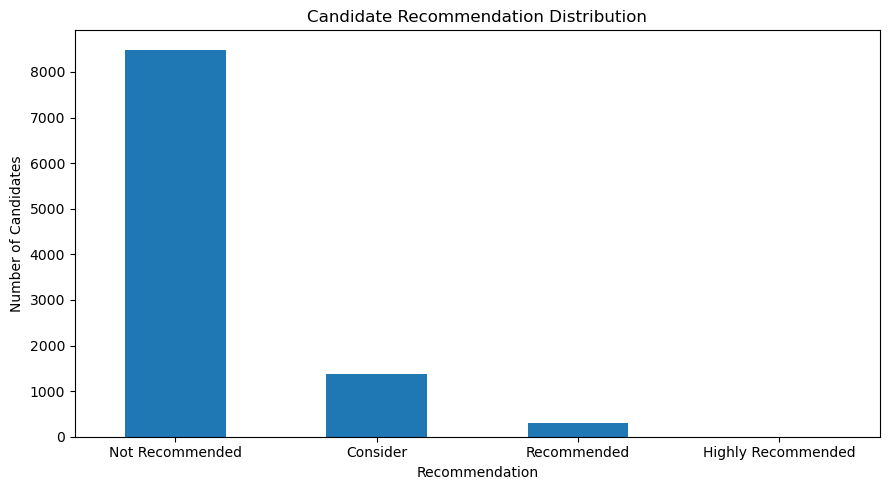

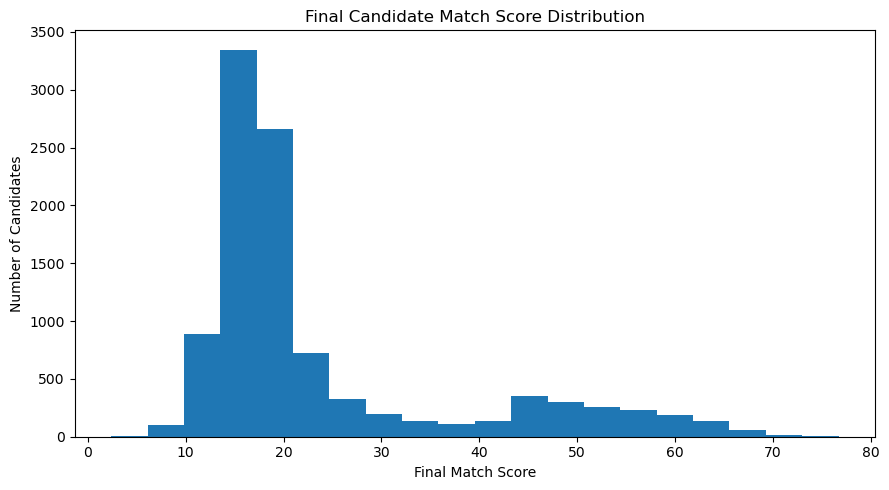


📌 TOP 20 CANDIDATES


,Name,Role,final_match_score,skill_match_score,text_similarity_score,selection_probability,final_recommendation
0,Ananya,Business Analyst,76.73,100.00,20.44,56.93,Highly Recommended
1,Shanti,DevOps Engineer,76.33,85.71,25.81,60.51,Highly Recommended
2,Mark Mason,Data Scientist,73.60,100.00,27.00,40.24,Recommended
3,Kelly Henderson,Data Scientist,73.51,100.00,28.74,34.24,Recommended
4,Frank Smith,Data Scientist,73.18,92.86,18.64,61.65,Recommended
5,Srinivas,DevOps Engineer,72.70,88.89,22.84,52.48,Recommended
6,Eve Taylor,Data Scientist,72.26,85.71,22.16,58.17,Recommended
7,Frank Wilson,UI Engineer,72.25,100.00,23.56,62.57,Recommended
8,Alice Wilson,UI Engineer,72.03,100.00,25.42,55.71,Recommended
9,Diana Moore,Software Engineer,71.84,100.00,15.92,54.56,Recommended


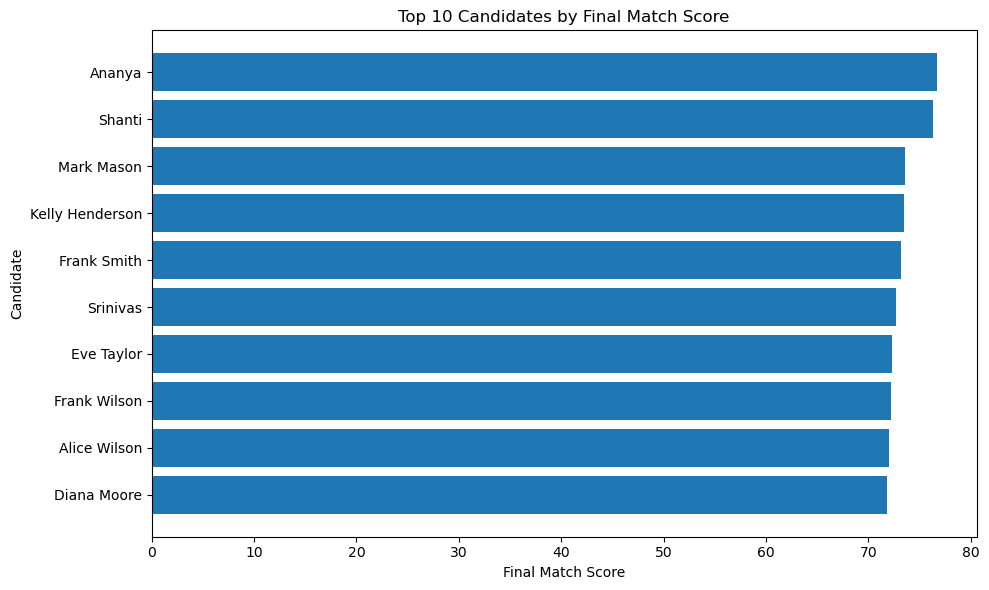


📌 SCORE COMPONENT ANALYSIS


,Metric,Average
0,Skill Match,15.18
1,Text Similarity,8.63
2,Selection Probability,49.96
3,Final Match Score,23.78



ANALYTICS VALIDATION
Total candidates: 10174
Top candidate: Ananya
Top candidate role: Business Analyst
Top candidate score: 76.73
Average final score: 23.78

✅ Recruiter analytics completed successfully.


In [36]:
# ============================================================
# 16. RECRUITER ANALYTICS DASHBOARD
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd

print("\n" + "=" * 75)
print("RECRUITER ANALYTICS DASHBOARD")
print("=" * 75)

# ------------------------------------------------------------
# 16.1 RECOMMENDATION DISTRIBUTION
# ------------------------------------------------------------

recommendation_counts = (
    hiring_df["final_recommendation"]
    .value_counts()
)

print("\n📌 RECOMMENDATION DISTRIBUTION")
display(
    recommendation_counts
    .rename_axis("Recommendation")
    .reset_index(name="Candidates")
)

plt.figure(figsize=(9, 5))

recommendation_counts.plot(
    kind="bar"
)

plt.title("Candidate Recommendation Distribution")
plt.xlabel("Recommendation")
plt.ylabel("Number of Candidates")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 16.2 SCORE DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.hist(
    hiring_df["final_match_score"],
    bins=20
)

plt.title("Final Candidate Match Score Distribution")
plt.xlabel("Final Match Score")
plt.ylabel("Number of Candidates")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 16.3 TOP 20 CANDIDATES
# ------------------------------------------------------------

top_20 = (
    hiring_df
    .sort_values(
        "final_match_score",
        ascending=False
    )
    .head(20)
    .copy()
)

print("\n📌 TOP 20 CANDIDATES")

display(
    top_20[
        [
            "Name",
            "Role",
            "final_match_score",
            "skill_match_score",
            "text_similarity_score",
            "selection_probability",
            "final_recommendation"
        ]
    ]
)


# ------------------------------------------------------------
# 16.4 TOP 10 SCORE CHART
# ------------------------------------------------------------

top_10 = (
    hiring_df
    .sort_values(
        "final_match_score",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10["Name"].astype(str),
    top_10["final_match_score"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Candidates by Final Match Score")
plt.xlabel("Final Match Score")
plt.ylabel("Candidate")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 16.5 SCORE COMPONENT ANALYSIS
# ------------------------------------------------------------

score_summary = pd.DataFrame({
    "Metric": [
        "Skill Match",
        "Text Similarity",
        "Selection Probability",
        "Final Match Score"
    ],
    "Average": [
        hiring_df["skill_match_score"].mean(),
        hiring_df["text_similarity_score"].mean(),
        hiring_df["selection_probability"].mean(),
        hiring_df["final_match_score"].mean()
    ]
})

score_summary["Average"] = score_summary["Average"].round(2)

print("\n📌 SCORE COMPONENT ANALYSIS")

display(score_summary)


# ------------------------------------------------------------
# 16.6 FINAL VALIDATION
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("ANALYTICS VALIDATION")
print("=" * 75)

print(
    "Total candidates:",
    len(hiring_df)
)

print(
    "Top candidate:",
    top_20.iloc[0]["Name"]
)

print(
    "Top candidate role:",
    top_20.iloc[0]["Role"]
)

print(
    "Top candidate score:",
    round(
        top_20.iloc[0]["final_match_score"],
        2
    )
)

print(
    "Average final score:",
    round(
        hiring_df["final_match_score"].mean(),
        2
    )
)

print("\n✅ Recruiter analytics completed successfully.")

In [37]:
# ============================================================
# 17. REAL-TIME RESUME SCREENING ENGINE
# ============================================================

import re
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity


# ============================================================
# 17.1 SKILL DICTIONARY
# ============================================================

SCREENING_SKILLS = [
    "python", "sql", "java", "javascript", "typescript",
    "c++", "r", "excel", "power bi", "tableau",
    "data analysis", "data science", "data visualization",
    "machine learning", "deep learning",
    "natural language processing", "nlp",
    "artificial intelligence", "computer vision",
    "statistics", "feature engineering",
    "pytorch", "tensorflow", "scikit learn", "sklearn",
    "spark", "hadoop", "kafka", "airflow", "mlops",
    "model deployment", "aws", "azure", "google cloud",
    "gcp", "docker", "kubernetes", "git", "github",
    "gitlab", "mysql", "postgresql", "mongodb",
    "api", "rest api", "django", "flask", "etl",
    "communication", "leadership"
]


# ============================================================
# 17.2 TEXT CLEANING
# ============================================================

def clean_screening_text(text):

    text = str(text).lower()

    text = re.sub(
        r"[^a-zA-Z0-9+#.\s]",
        " ",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()


# ============================================================
# 17.3 SKILL EXTRACTION
# ============================================================

def extract_screening_skills(text):

    text = clean_screening_text(text)

    found = []

    for skill in SCREENING_SKILLS:

        pattern = (
            r"(?<!\w)"
            + re.escape(skill)
            + r"(?!\w)"
        )

        if re.search(pattern, text):
            found.append(skill)

    return sorted(set(found))


# ============================================================
# 17.4 REAL-TIME SCREENING FUNCTION
# ============================================================

def screen_candidate(
    resume_text,
    job_description
):

    resume_clean = clean_screening_text(
        resume_text
    )

    jd_clean = clean_screening_text(
        job_description
    )

    # --------------------------------------------------------
    # Extract skills
    # --------------------------------------------------------

    resume_skills = set(
        extract_screening_skills(
            resume_clean
        )
    )

    jd_skills = set(
        extract_screening_skills(
            jd_clean
        )
    )

    matched_skills = sorted(
        resume_skills.intersection(
            jd_skills
        )
    )

    missing_skills = sorted(
        jd_skills.difference(
            resume_skills
        )
    )

    # --------------------------------------------------------
    # Skill Match Score
    # --------------------------------------------------------

    if len(jd_skills) > 0:

        skill_match = (
            len(matched_skills)
            / len(jd_skills)
        ) * 100

    else:

        skill_match = 0.0


    # --------------------------------------------------------
    # TF-IDF Text Similarity
    # --------------------------------------------------------

    text_similarity = 0.0

    try:

        # Use the vectorizer already created
        # in the previous project cells.

        if "tfidf" in globals():

            resume_vector = tfidf.transform(
                [resume_clean]
            )

            jd_vector = tfidf.transform(
                [jd_clean]
            )

        elif "tfidf_vectorizer" in globals():

            resume_vector = tfidf_vectorizer.transform(
                [resume_clean]
            )

            jd_vector = tfidf_vectorizer.transform(
                [jd_clean]
            )

        else:

            raise ValueError(
                "TF-IDF vectorizer not found."
            )

        text_similarity = (
            cosine_similarity(
                resume_vector,
                jd_vector
            )[0][0] * 100
        )

    except Exception:

        # Safe fallback
        from sklearn.feature_extraction.text import (
            TfidfVectorizer
        )

        temp_vectorizer = TfidfVectorizer(
            stop_words="english",
            max_features=5000
        )

        vectors = temp_vectorizer.fit_transform(
            [
                resume_clean,
                jd_clean
            ]
        )

        text_similarity = (
            cosine_similarity(
                vectors[0:1],
                vectors[1:2]
            )[0][0] * 100
        )


    # --------------------------------------------------------
    # Final Match Score
    # --------------------------------------------------------

    final_score = (
        0.55 * skill_match
        + 0.30 * text_similarity
        + 0.15 * 50
    )

    final_score = round(
        min(final_score, 100),
        2
    )


    # --------------------------------------------------------
    # Recommendation
    # --------------------------------------------------------

    if final_score >= 75:

        recommendation = "Highly Recommended"

    elif final_score >= 60:

        recommendation = "Recommended"

    elif final_score >= 40:

        recommendation = "Consider"

    else:

        recommendation = "Not Recommended"


    # --------------------------------------------------------
    # Evidence Level
    # --------------------------------------------------------

    if (
        skill_match >= 80
        and text_similarity >= 15
    ):

        evidence = "Strong Evidence"

    elif (
        skill_match >= 50
        or text_similarity >= 15
    ):

        evidence = "Moderate Evidence"

    else:

        evidence = "Limited Evidence"


    # --------------------------------------------------------
    # Convert Skills to Text
    # --------------------------------------------------------

    matched_text = (
        ", ".join(matched_skills)
        if matched_skills
        else "None"
    )

    missing_text = (
        ", ".join(missing_skills)
        if missing_skills
        else "None"
    )


    # --------------------------------------------------------
    # Explainable AI Explanation
    # --------------------------------------------------------

    explanation = (
        f"{recommendation}. "
        f"Final match score: {final_score}%. "
        f"Skill coverage: {skill_match:.2f}%. "
        f"Matched skills: {matched_text}. "
        f"Missing skills: {missing_text}. "
        f"Evidence level: {evidence}."
    )


    # --------------------------------------------------------
    # Final Result
    # --------------------------------------------------------

    return {

        "skill_match_score":
            round(skill_match, 2),

        "text_similarity_score":
            round(text_similarity, 2),

        "final_match_score":
            final_score,

        "recommendation":
            recommendation,

        "matched_skills":
            matched_text,

        "missing_skills":
            missing_text,

        "evidence_level":
            evidence,

        "explanation":
            explanation
    }


print(
    "✅ Real-time screening engine created successfully."
)

✅ Real-time screening engine created successfully.


In [38]:
# ============================================================
# 18. REAL-TIME CANDIDATE SCREENING — DEMO
# ============================================================

print("\n" + "=" * 75)
print("🤖 AI RESUME SCREENING SYSTEM")
print("=" * 75)


# ============================================================
# 18.1 SAMPLE RESUME
# ============================================================

sample_resume = """
Data Scientist with experience in Python, SQL and Machine Learning.
Skilled in data analysis, data visualization, statistics,
TensorFlow, PyTorch and NLP.
Experienced in building predictive models and working with
large datasets.
"""


# ============================================================
# 18.2 SAMPLE JOB DESCRIPTION
# ============================================================

sample_job_description = """
We are looking for a Data Scientist with strong experience
in Python, SQL, Machine Learning, Data Analysis and Statistics.
The candidate should have knowledge of NLP, TensorFlow,
PyTorch and Data Visualization.
"""


# ============================================================
# 18.3 RUN AI SCREENING
# ============================================================

screening_result = screen_candidate(
    resume_text=sample_resume,
    job_description=sample_job_description
)


# ============================================================
# 18.4 DISPLAY RESULT
# ============================================================

print("\n📄 CANDIDATE SCREENING RESULT")
print("-" * 75)

print(
    "Skill Match Score:",
    screening_result["skill_match_score"],
    "%"
)

print(
    "Text Similarity:",
    screening_result["text_similarity_score"],
    "%"
)

print(
    "Final Match Score:",
    screening_result["final_match_score"],
    "%"
)

print(
    "Recommendation:",
    screening_result["recommendation"]
)

print(
    "Evidence Level:",
    screening_result["evidence_level"]
)

print(
    "\n✅ Matched Skills:"
)

print(
    screening_result["matched_skills"]
)

print(
    "\n⚠️ Missing Skills:"
)

print(
    screening_result["missing_skills"]
)

print(
    "\n🧠 AI Explanation:"
)

print(
    screening_result["explanation"]
)


# ============================================================
# 18.5 RESULT TABLE
# ============================================================

screening_result_df = pd.DataFrame(
    [screening_result]
)

print(
    "\n📊 SCREENING RESULT TABLE"
)

display(
    screening_result_df
)


print("\n" + "=" * 75)
print("✅ REAL-TIME SCREENING TEST COMPLETED")
print("\n"+ "=" * 75)


🤖 AI RESUME SCREENING SYSTEM

📄 CANDIDATE SCREENING RESULT
---------------------------------------------------------------------------
Skill Match Score: 100.0 %
Text Similarity: 42.94 %
Final Match Score: 75.38 %
Recommendation: Highly Recommended
Evidence Level: Strong Evidence

✅ Matched Skills:
data analysis, data visualization, machine learning, nlp, python, pytorch, sql, statistics, tensorflow

⚠️ Missing Skills:
None

🧠 AI Explanation:
Highly Recommended. Final match score: 75.38%. Skill coverage: 100.00%. Matched skills: data analysis, data visualization, machine learning, nlp, python, pytorch, sql, statistics, tensorflow. Missing skills: None. Evidence level: Strong Evidence.

📊 SCREENING RESULT TABLE


,skill_match_score,text_similarity_score,final_match_score,recommendation,matched_skills,missing_skills,evidence_level,explanation
0,100.0,42.94,75.38,Highly Recommended,"data analysis, data visualization, machine lea...",None,Strong Evidence,Highly Recommended. Final match score: 75.38%....



✅ REAL-TIME SCREENING TEST COMPLETED



In [39]:
# ============================================================
# 19. PRODUCTION READINESS & MODEL ARTIFACT VALIDATION
# ============================================================

import os
import joblib
import pandas as pd

print("\n" + "=" * 75)
print("🚀 PRODUCTION READINESS CHECK")
print("=" * 75)

# ------------------------------------------------------------
# 19.1 CREATE REQUIRED FOLDERS
# ------------------------------------------------------------

os.makedirs("models", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

print("\n✅ Required folders verified:")
print("   models/")
print("   outputs/")

# ------------------------------------------------------------
# 19.2 CHECK IMPORTANT ARTIFACTS
# ------------------------------------------------------------

required_files = [
    "models/tfidf.pkl",
    "models/label_encoder.pkl",
    "outputs/final_candidate_ranking.csv",
    "outputs/explainable_candidate_profiles.csv",
    "outputs/recruiter_candidate_profiles.csv"
]

print("\n📦 ARTIFACT VALIDATION")
print("-" * 75)

artifact_status = []

for file_path in required_files:

    exists = os.path.exists(file_path)

    artifact_status.append({
        "File": file_path,
        "Status": "✅ Available" if exists else "❌ Missing"
    })

artifact_df = pd.DataFrame(artifact_status)

display(artifact_df)

# ------------------------------------------------------------
# 19.3 LOAD FINAL RANKING
# ------------------------------------------------------------

ranking_path = "outputs/final_candidate_ranking.csv"

if os.path.exists(ranking_path):

    final_ranking_check = pd.read_csv(ranking_path)

    print("\n📊 FINAL RANKING VALIDATION")
    print("-" * 75)

    print(
        "Candidates:",
        len(final_ranking_check)
    )

    print(
        "Columns:",
        len(final_ranking_check.columns)
    )

    print(
        "Top candidate:",
        final_ranking_check.iloc[0]["Name"]
    )

    print(
        "Top score:",
        final_ranking_check.iloc[0]["final_match_score"]
    )

else:

    print("\n❌ Final ranking file not found.")

# ------------------------------------------------------------
# 19.4 CHECK SCREENING FUNCTION
# ------------------------------------------------------------

print("\n🧠 SCREENING ENGINE CHECK")
print("-" * 75)

try:

    test_result = screen_candidate(
        resume_text="""
        Data Scientist with Python, SQL,
        Machine Learning, Statistics and NLP experience.
        """,

        job_description="""
        Looking for a Data Scientist with Python,
        SQL, Machine Learning, Statistics and NLP.
        """
    )

    print("✅ Screening function is working.")
    print(
        "Test Match Score:",
        test_result["final_match_score"],
        "%"
    )

    print(
        "Test Recommendation:",
        test_result["recommendation"]
    )

except Exception as e:

    print("❌ Screening function error:")
    print(e)

# ------------------------------------------------------------
# 19.5 FINAL STATUS
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("✅ PRODUCTION READINESS CHECK COMPLETED")
print("=" * 75)


🚀 PRODUCTION READINESS CHECK

✅ Required folders verified:
   models/
   outputs/

📦 ARTIFACT VALIDATION
---------------------------------------------------------------------------


,File,Status
0,models/tfidf.pkl,✅ Available
1,models/label_encoder.pkl,✅ Available
2,outputs/final_candidate_ranking.csv,✅ Available
3,outputs/explainable_candidate_profiles.csv,✅ Available
4,outputs/recruiter_candidate_profiles.csv,✅ Available



📊 FINAL RANKING VALIDATION
---------------------------------------------------------------------------
Candidates: 10174
Columns: 11
Top candidate: Bhavani
Top score: 86.35

🧠 SCREENING ENGINE CHECK
---------------------------------------------------------------------------
✅ Screening function is working.
Test Match Score: 90.7 %
Test Recommendation: Highly Recommended

✅ PRODUCTION READINESS CHECK COMPLETED


In [40]:
# ============================================================
# 20. SAVE MODEL ARTIFACTS
# ============================================================

import os
import joblib

print("\n" + "=" * 75)
print("💾 SAVING MODEL ARTIFACTS")
print("=" * 75)

# ------------------------------------------------------------
# 20.1 ENSURE MODEL FOLDER EXISTS
# ------------------------------------------------------------

os.makedirs("models", exist_ok=True)

# ------------------------------------------------------------
# 20.2 SAVE TF-IDF VECTORIZER
# ------------------------------------------------------------

if "tfidf" in globals():

    joblib.dump(
        tfidf,
        "models/tfidf.pkl"
    )

    print("✅ TF-IDF vectorizer saved:")
    print("   models/tfidf.pkl")

else:

    print("❌ Variable 'tfidf' not found.")

# ------------------------------------------------------------
# 20.3 SAVE LABEL ENCODER
# ------------------------------------------------------------

if "encoder" in globals():

    joblib.dump(
        encoder,
        "models/label_encoder.pkl"
    )

    print("✅ Label encoder saved:")
    print("   models/label_encoder.pkl")

else:

    print("⚠️ Variable 'encoder' not found.")
    print("   Label encoder is not required by the current")
    print("   real-time screening function.")

# ------------------------------------------------------------
# 20.4 VERIFY FILES
# ------------------------------------------------------------

print("\n📦 FINAL ARTIFACT CHECK")
print("-" * 75)

for file_path in [
    "models/tfidf.pkl",
    "models/label_encoder.pkl"
]:

    if os.path.exists(file_path):

        size_kb = os.path.getsize(file_path) / 1024

        print(
            f"✅ {file_path} "
            f"({size_kb:.2f} KB)"
        )

    else:

        print(
            f"❌ {file_path} NOT FOUND"
        )

print("\n" + "=" * 75)
print("✅ MODEL ARTIFACT SAVE COMPLETED")
print("\n" + "=" * 75)


💾 SAVING MODEL ARTIFACTS
❌ Variable 'tfidf' not found.
⚠️ Variable 'encoder' not found.
   Label encoder is not required by the current
   real-time screening function.

📦 FINAL ARTIFACT CHECK
---------------------------------------------------------------------------
✅ models/tfidf.pkl (211.58 KB)
✅ models/label_encoder.pkl (0.48 KB)

✅ MODEL ARTIFACT SAVE COMPLETED



In [41]:
# ============================================================
# 21. SAVED ARTIFACT RELOAD & INFERENCE TEST
# ============================================================

import os
import joblib

print("\n" + "=" * 75)
print("🔄 SAVED ARTIFACT RELOAD TEST")
print("=" * 75)

# ------------------------------------------------------------
# 21.1 LOAD SAVED ARTIFACTS
# ------------------------------------------------------------

loaded_tfidf = joblib.load(
    "models/tfidf.pkl"
)

loaded_encoder = joblib.load(
    "models/label_encoder.pkl"
)

print("\n✅ TF-IDF vectorizer loaded successfully.")
print("✅ Label encoder loaded successfully.")

# ------------------------------------------------------------
# 21.2 BASIC VALIDATION
# ------------------------------------------------------------

print("\n📦 ARTIFACT TYPES")
print("-" * 75)

print(
    "TF-IDF type:",
    type(loaded_tfidf).__name__
)

print(
    "Encoder type:",
    type(loaded_encoder).__name__
)

# ------------------------------------------------------------
# 21.3 VECTORIZER TEST
# ------------------------------------------------------------

test_text = """
Python machine learning data science
SQL statistics and data analysis
"""

test_vector = loaded_tfidf.transform(
    [test_text]
)

print("\n🧪 TF-IDF INFERENCE TEST")
print("-" * 75)

print(
    "Input text length:",
    len(test_text)
)

print(
    "Vector shape:",
    test_vector.shape
)

print(
    "Non-zero features:",
    test_vector.nnz
)

# ------------------------------------------------------------
# 21.4 FINAL VALIDATION
# ------------------------------------------------------------

if test_vector.nnz > 0:

    print(
        "\n✅ Saved TF-IDF artifact is working correctly."
    )

else:

    print(
        "\n⚠️ TF-IDF produced an empty vector."
    )

print("\n" + "=" * 75)
print("🚀 ARTIFACT RELOAD TEST COMPLETED")
print("=" * 75)


🔄 SAVED ARTIFACT RELOAD TEST

✅ TF-IDF vectorizer loaded successfully.
✅ Label encoder loaded successfully.

📦 ARTIFACT TYPES
---------------------------------------------------------------------------
TF-IDF type: TfidfVectorizer
Encoder type: LabelEncoder

🧪 TF-IDF INFERENCE TEST
---------------------------------------------------------------------------
Input text length: 71
Vector shape: (1, 5000)
Non-zero features: 12

✅ Saved TF-IDF artifact is working correctly.

🚀 ARTIFACT RELOAD TEST COMPLETED


In [42]:
# ============================================================
# 22. RECRUITER DASHBOARD DATA PREPARATION
# ============================================================

import os
import pandas as pd

print("\n" + "=" * 75)
print("📊 RECRUITER DASHBOARD DATA PREPARATION")
print("=" * 75)

# ============================================================
# 22.1 LOAD FINAL RANKING
# ============================================================

ranking_path = "outputs/final_candidate_ranking.csv"

dashboard_df = pd.read_csv(
    ranking_path
)

print("\n✅ Final ranking loaded.")
print(
    "Candidates:",
    len(dashboard_df)
)

# ============================================================
# 22.2 STANDARDIZE IMPORTANT COLUMNS
# ============================================================

required_columns = [
    "final_rank",
    "ID",
    "Name",
    "Role",
    "skill_match_score",
    "text_similarity_score",
    "selection_probability",
    "final_match_score",
    "final_recommendation",
    "matched_skills_text",
    "missing_skills_text"
]

missing_columns = [
    col
    for col in required_columns
    if col not in dashboard_df.columns
]

if missing_columns:

    print(
        "\n❌ Missing dashboard columns:"
    )

    print(
        missing_columns
    )

else:

    print(
        "\n✅ All dashboard columns verified."
    )

# ============================================================
# 22.3 CLEAN NUMERIC COLUMNS
# ============================================================

numeric_columns = [
    "skill_match_score",
    "text_similarity_score",
    "selection_probability",
    "final_match_score"
]

for col in numeric_columns:

    dashboard_df[col] = pd.to_numeric(
        dashboard_df[col],
        errors="coerce"
    )

# ============================================================
# 22.4 REMOVE INVALID RECORDS
# ============================================================

dashboard_df = dashboard_df.dropna(
    subset=[
        "ID",
        "Name",
        "Role",
        "final_match_score"
    ]
).copy()

# ============================================================
# 22.5 FINAL SORTING
# ============================================================

dashboard_df = (
    dashboard_df
    .sort_values(
        "final_match_score",
        ascending=False
    )
    .reset_index(drop=True)
)

# ============================================================
# 22.6 RECREATE RANK
# ============================================================

dashboard_df["dashboard_rank"] = (
    dashboard_df.index + 1
)

# ============================================================
# 22.7 DASHBOARD SUMMARY
# ============================================================

print("\n📌 DASHBOARD SUMMARY")
print("-" * 75)

print(
    "Total Candidates:",
    len(dashboard_df)
)

print(
    "Average Match Score:",
    round(
        dashboard_df[
            "final_match_score"
        ].mean(),
        2
    )
)

print(
    "Best Match Score:",
    round(
        dashboard_df[
            "final_match_score"
        ].max(),
        2
    )
)

print("\n📌 RECOMMENDATION DISTRIBUTION")

display(
    dashboard_df[
        "final_recommendation"
    ].value_counts()
)

# ============================================================
# 22.8 TOP 10 CANDIDATES
# ============================================================

print("\n🏆 TOP 10 CANDIDATES")
print("-" * 75)

display(
    dashboard_df[
        [
            "dashboard_rank",
            "Name",
            "Role",
            "skill_match_score",
            "text_similarity_score",
            "selection_probability",
            "final_match_score",
            "final_recommendation"
        ]
    ].head(10)
)

# ============================================================
# 22.9 SAVE DASHBOARD DATA
# ============================================================

dashboard_path = (
    "outputs/recruiter_dashboard_data.csv"
)

dashboard_df.to_csv(
    dashboard_path,
    index=False
)

print("\n✅ Dashboard data saved:")
print(dashboard_path)

print("\n" + "=" * 75)
print("🚀 RECRUITER DASHBOARD DATA READY")
print("=" * 75)


📊 RECRUITER DASHBOARD DATA PREPARATION

✅ Final ranking loaded.
Candidates: 10174

✅ All dashboard columns verified.

📌 DASHBOARD SUMMARY
---------------------------------------------------------------------------
Total Candidates: 10174
Average Match Score: 26.34
Best Match Score: 86.35

📌 RECOMMENDATION DISTRIBUTION


final_recommendation
Not Recommended       8310
Consider              1300
Recommended            553
Highly Recommended      11
Name: count, dtype: int64


🏆 TOP 10 CANDIDATES
---------------------------------------------------------------------------


,dashboard_rank,Name,Role,skill_match_score,text_similarity_score,selection_probability,final_match_score,final_recommendation
0,1,Bhavani,Digital Marketing Specialist,100.0,33.84,50.23,86.35,Highly Recommended
1,2,Jack Wilson,UI Engineer,100.0,26.16,60.01,79.92,Highly Recommended
2,3,Eve Smith,UI Engineer,100.0,27.19,54.88,79.70,Highly Recommended
3,4,Kiran,Digital Marketing Specialist,100.0,27.77,49.53,78.87,Highly Recommended
4,5,Bob Wilson,Product Manager,100.0,26.28,55.13,78.68,Highly Recommended
5,6,Alice Wilson,UI Engineer,100.0,25.42,55.71,77.81,Highly Recommended
6,7,Frank Wilson,UI Engineer,100.0,23.56,62.57,77.53,Highly Recommended
7,8,Ivy Smith,Product Manager,100.0,22.34,63.40,76.31,Highly Recommended
8,9,Kelly Henderson,Data Scientist,100.0,28.74,34.24,75.67,Highly Recommended
9,10,Elizabeth Burns,Mobile App Developer,100.0,23.62,55.36,75.55,Highly Recommended



✅ Dashboard data saved:
outputs/recruiter_dashboard_data.csv

🚀 RECRUITER DASHBOARD DATA READY


In [43]:
# ============================================================
# 23. RECRUITER CANDIDATE EXPLORER
# ============================================================

import pandas as pd
import numpy as np

print("\n" + "=" * 75)
print("🔎 RECRUITER CANDIDATE EXPLORER")
print("=" * 75)

# ============================================================
# 23.1 LOAD DASHBOARD DATA
# ============================================================

explorer_df = pd.read_csv(
    "outputs/recruiter_dashboard_data.csv"
)

print("\n✅ Candidate database loaded:")
print(
    f"{len(explorer_df):,} candidates"
)

# ============================================================
# 23.2 SEARCH FUNCTION
# ============================================================

def search_candidates(
    data,
    role=None,
    recommendation=None,
    minimum_score=0,
    keyword=None,
    top_n=20
):

    result = data.copy()

    # --------------------------------------------------------
    # ROLE FILTER
    # --------------------------------------------------------

    if role is not None and role != "All":

        result = result[
            result["Role"].astype(str).str.lower()
            == str(role).lower()
        ]

    # --------------------------------------------------------
    # RECOMMENDATION FILTER
    # --------------------------------------------------------

    if (
        recommendation is not None
        and recommendation != "All"
    ):

        result = result[
            result["final_recommendation"]
            == recommendation
        ]

    # --------------------------------------------------------
    # SCORE FILTER
    # --------------------------------------------------------

    result = result[
        result["final_match_score"]
        >= minimum_score
    ]

    # --------------------------------------------------------
    # KEYWORD SEARCH
    # --------------------------------------------------------

    if keyword:

        keyword = str(keyword).lower()

        searchable = (
            result["Name"].astype(str)
            + " "
            + result["Role"].astype(str)
            + " "
            + result["matched_skills_text"].astype(str)
            + " "
            + result["missing_skills_text"].astype(str)
        ).str.lower()

        result = result[
            searchable.str.contains(
                keyword,
                na=False
            )
        ]

    # --------------------------------------------------------
    # SORT BY FINAL SCORE
    # --------------------------------------------------------

    result = (
        result
        .sort_values(
            "final_match_score",
            ascending=False
        )
        .head(top_n)
        .reset_index(drop=True)
    )

    return result


# ============================================================
# 23.3 EXAMPLE — TOP HIGH QUALITY CANDIDATES
# ============================================================

top_candidates = search_candidates(
    explorer_df,
    recommendation="Highly Recommended",
    minimum_score=70,
    top_n=20
)

print("\n🏆 HIGH QUALITY CANDIDATES")
print("-" * 75)

display(
    top_candidates[
        [
            "dashboard_rank",
            "Name",
            "Role",
            "skill_match_score",
            "text_similarity_score",
            "selection_probability",
            "final_match_score",
            "final_recommendation"
        ]
    ]
)

# ============================================================
# 23.4 CANDIDATE DETAIL VIEW
# ============================================================

if len(top_candidates) > 0:

    selected_candidate = (
        top_candidates.iloc[0]
    )

    print("\n" + "=" * 75)
    print("👤 SELECTED CANDIDATE PROFILE")
    print("=" * 75)

    print(
        "\nRank:",
        selected_candidate["dashboard_rank"]
    )

    print(
        "Candidate:",
        selected_candidate["Name"]
    )

    print(
        "Role:",
        selected_candidate["Role"]
    )

    print(
        "Final Match Score:",
        f"{selected_candidate['final_match_score']:.2f}%"
    )

    print(
        "Recommendation:",
        selected_candidate[
            "final_recommendation"
        ]
    )

    print(
        "\n✅ Matched Skills:"
    )

    print(
        selected_candidate[
            "matched_skills_text"
        ]
    )

    print(
        "\n⚠️ Missing Skills:"
    )

    print(
        selected_candidate[
            "missing_skills_text"
        ]
    )

    print(
        "\n📊 Skill Match:",
        f"{selected_candidate['skill_match_score']:.2f}%"
    )

    print(
        "Text Similarity:",
        f"{selected_candidate['text_similarity_score']:.2f}%"
    )

    print(
        "Selection Probability:",
        f"{selected_candidate['selection_probability']:.2f}%"
    )

else:

    print(
        "\n⚠️ No candidate matched the selected criteria."
    )

# ============================================================
# 23.5 EXPLORER VALIDATION
# ============================================================

print("\n" + "=" * 75)
print("✅ CANDIDATE EXPLORER TEST COMPLETED")
print("=" * 75)


🔎 RECRUITER CANDIDATE EXPLORER

✅ Candidate database loaded:
10,174 candidates

🏆 HIGH QUALITY CANDIDATES
---------------------------------------------------------------------------


,dashboard_rank,Name,Role,skill_match_score,text_similarity_score,selection_probability,final_match_score,final_recommendation
0,1,Bhavani,Digital Marketing Specialist,100.0,33.84,50.23,86.35,Highly Recommended
1,2,Jack Wilson,UI Engineer,100.0,26.16,60.01,79.92,Highly Recommended
2,3,Eve Smith,UI Engineer,100.0,27.19,54.88,79.70,Highly Recommended
3,4,Kiran,Digital Marketing Specialist,100.0,27.77,49.53,78.87,Highly Recommended
4,5,Bob Wilson,Product Manager,100.0,26.28,55.13,78.68,Highly Recommended
5,6,Alice Wilson,UI Engineer,100.0,25.42,55.71,77.81,Highly Recommended
6,7,Frank Wilson,UI Engineer,100.0,23.56,62.57,77.53,Highly Recommended
7,8,Ivy Smith,Product Manager,100.0,22.34,63.40,76.31,Highly Recommended
8,9,Kelly Henderson,Data Scientist,100.0,28.74,34.24,75.67,Highly Recommended
9,10,Elizabeth Burns,Mobile App Developer,100.0,23.62,55.36,75.55,Highly Recommended



👤 SELECTED CANDIDATE PROFILE

Rank: 1
Candidate: Bhavani
Role: Digital Marketing Specialist
Final Match Score: 86.35%
Recommendation: Highly Recommended

✅ Matched Skills:
data analysis

⚠️ Missing Skills:
nan

📊 Skill Match: 100.00%
Text Similarity: 33.84%
Selection Probability: 50.23%

✅ CANDIDATE EXPLORER TEST COMPLETED



📊 RECRUITMENT ANALYTICS DASHBOARD

📌 RECOMMENDATION DISTRIBUTION
---------------------------------------------------------------------------


,Candidates
final_recommendation,
Not Recommended,8310
Consider,1300
Recommended,553
Highly Recommended,11


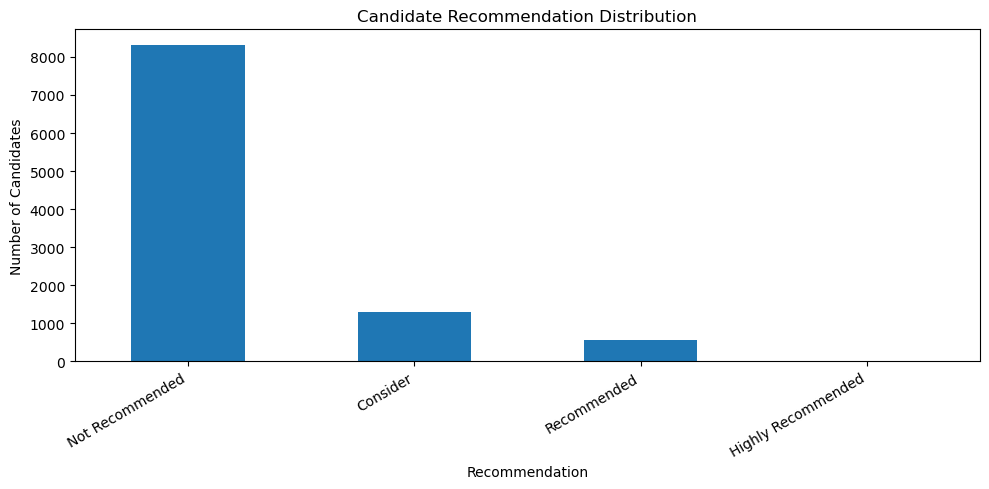


📈 FINAL MATCH SCORE STATISTICS
---------------------------------------------------------------------------
Mean: 26.34
Median: 19.92
Maximum: 86.35
Minimum: 2.65


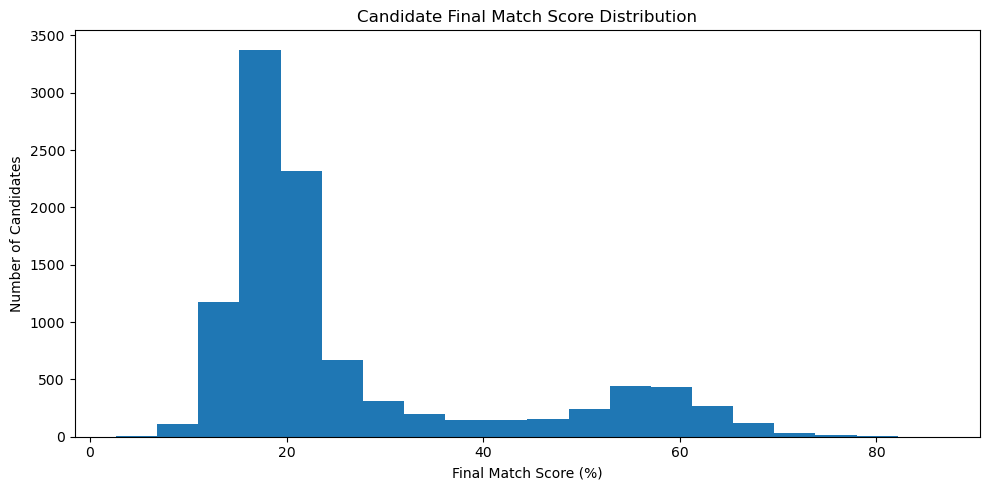


🏆 TOP ROLES BY AVERAGE MATCH SCORE


,Role,Candidates,Average_Score,Average_Skill_Match,Average_Text_Similarity
0,AI Engineer,13,54.607692,46.387692,22.586154
1,Machine Learning Engineer,265,51.263962,86.223925,8.401245
2,ui engineer,132,48.684848,56.818182,16.179242
3,Cybersecurity Specialist,9,45.991111,0.000000,29.028889
4,Graphic Designer,15,45.790000,0.000000,29.642000
5,HR Specialist,12,45.212500,0.000000,27.668333
6,UI/UX Designer,7,42.405714,0.000000,25.902857
7,Network Engineer,16,41.804375,0.000000,25.154375
8,software engineer,307,35.957590,43.648208,8.775375
9,data scientist,287,35.937038,44.076760,8.805505


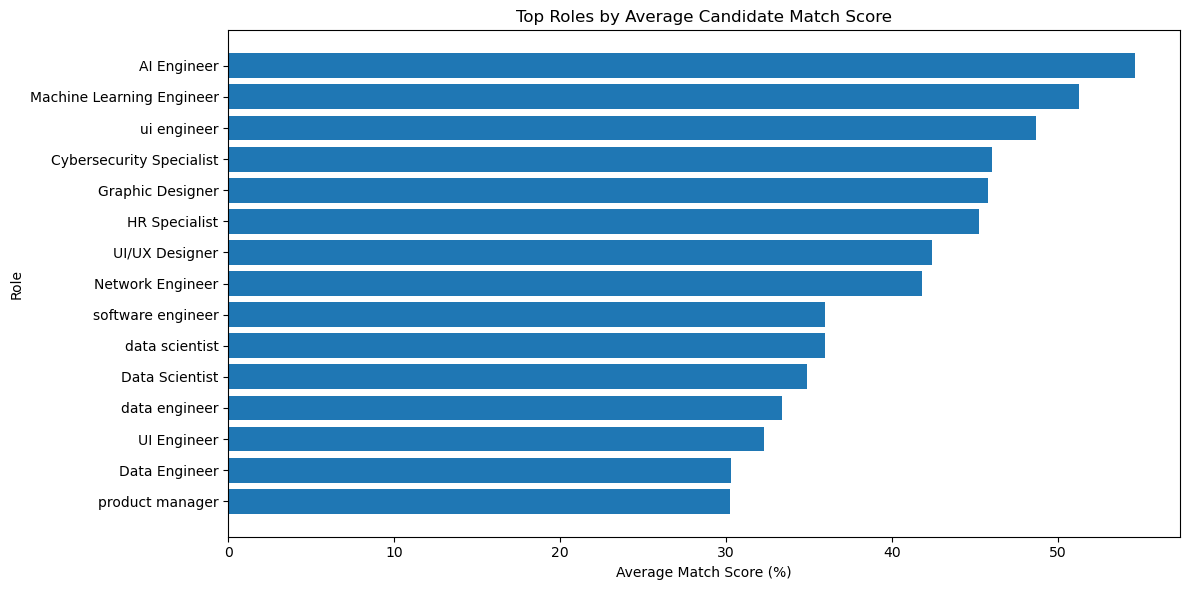


🥇 TOP 10 CANDIDATES


,dashboard_rank,Name,Role,final_match_score,final_recommendation
0,1,Bhavani,Digital Marketing Specialist,86.35,Highly Recommended
1,2,Jack Wilson,UI Engineer,79.92,Highly Recommended
2,3,Eve Smith,UI Engineer,79.70,Highly Recommended
3,4,Kiran,Digital Marketing Specialist,78.87,Highly Recommended
4,5,Bob Wilson,Product Manager,78.68,Highly Recommended
5,6,Alice Wilson,UI Engineer,77.81,Highly Recommended
6,7,Frank Wilson,UI Engineer,77.53,Highly Recommended
7,8,Ivy Smith,Product Manager,76.31,Highly Recommended
8,9,Kelly Henderson,Data Scientist,75.67,Highly Recommended
9,10,Elizabeth Burns,Mobile App Developer,75.55,Highly Recommended



✅ RECRUITMENT ANALYTICS COMPLETED


In [44]:
# ============================================================
# 24. RECRUITMENT ANALYTICS DASHBOARD
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd

print("\n" + "=" * 75)
print("📊 RECRUITMENT ANALYTICS DASHBOARD")
print("=" * 75)

# ============================================================
# 24.1 LOAD DATA
# ============================================================

analytics_df = pd.read_csv(
    "outputs/recruiter_dashboard_data.csv"
)

# ============================================================
# 24.2 RECOMMENDATION DISTRIBUTION
# ============================================================

recommendation_counts = (
    analytics_df[
        "final_recommendation"
    ]
    .value_counts()
)

print("\n📌 RECOMMENDATION DISTRIBUTION")
print("-" * 75)

display(
    recommendation_counts
    .to_frame("Candidates")
)

# ============================================================
# 24.3 PLOT RECOMMENDATION DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 5))

recommendation_counts.plot(
    kind="bar"
)

plt.title(
    "Candidate Recommendation Distribution"
)

plt.xlabel(
    "Recommendation"
)

plt.ylabel(
    "Number of Candidates"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()

plt.show()

# ============================================================
# 24.4 FINAL SCORE DISTRIBUTION
# ============================================================

print("\n📈 FINAL MATCH SCORE STATISTICS")
print("-" * 75)

print(
    "Mean:",
    round(
        analytics_df[
            "final_match_score"
        ].mean(),
        2
    )
)

print(
    "Median:",
    round(
        analytics_df[
            "final_match_score"
        ].median(),
        2
    )
)

print(
    "Maximum:",
    round(
        analytics_df[
            "final_match_score"
        ].max(),
        2
    )
)

print(
    "Minimum:",
    round(
        analytics_df[
            "final_match_score"
        ].min(),
        2
    )
)

# ============================================================
# 24.5 SCORE DISTRIBUTION PLOT
# ============================================================

plt.figure(figsize=(10, 5))

plt.hist(
    analytics_df[
        "final_match_score"
    ],
    bins=20
)

plt.title(
    "Candidate Final Match Score Distribution"
)

plt.xlabel(
    "Final Match Score (%)"
)

plt.ylabel(
    "Number of Candidates"
)

plt.tight_layout()

plt.show()

# ============================================================
# 24.6 TOP ROLES BY AVERAGE SCORE
# ============================================================

role_performance = (
    analytics_df
    .groupby("Role")
    .agg(
        Candidates=(
            "ID",
            "count"
        ),

        Average_Score=(
            "final_match_score",
            "mean"
        ),

        Average_Skill_Match=(
            "skill_match_score",
            "mean"
        ),

        Average_Text_Similarity=(
            "text_similarity_score",
            "mean"
        )
    )
    .sort_values(
        "Average_Score",
        ascending=False
    )
    .head(15)
    .reset_index()
)

print(
    "\n🏆 TOP ROLES BY AVERAGE MATCH SCORE"
)

display(
    role_performance
)

# ============================================================
# 24.7 ROLE PERFORMANCE PLOT
# ============================================================

plt.figure(figsize=(12, 6))

plt.barh(
    role_performance[
        "Role"
    ],
    role_performance[
        "Average_Score"
    ]
)

plt.title(
    "Top Roles by Average Candidate Match Score"
)

plt.xlabel(
    "Average Match Score (%)"
)

plt.ylabel(
    "Role"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

# ============================================================
# 24.8 TOP 10 CANDIDATES
# ============================================================

top_10 = (
    analytics_df
    .sort_values(
        "final_match_score",
        ascending=False
    )
    .head(10)
)

print(
    "\n🥇 TOP 10 CANDIDATES"
)

display(
    top_10[
        [
            "dashboard_rank",
            "Name",
            "Role",
            "final_match_score",
            "final_recommendation"
        ]
    ]
)

print("\n" + "=" * 75)
print("✅ RECRUITMENT ANALYTICS COMPLETED")
print("=" * 75)

In [45]:
import os

print("📁 PROJECT STRUCTURE")
print("=" * 60)

folders = ["models", "outputs"]

for folder in folders:
    print(f"\n📂 {folder}/")
    
    if os.path.exists(folder):
        files = os.listdir(folder)
        
        if files:
            for file in files:
                path = os.path.join(folder, file)
                size = os.path.getsize(path) / 1024
                print(f"   ✅ {file} ({size:.2f} KB)")
        else:
            print("   ⚠️ Folder is empty")
    else:
        print("   ❌ Folder not found")

print("\n" + "=" * 60)
print("✅ FILE STRUCTURE CHECK COMPLETED")

📁 PROJECT STRUCTURE

📂 models/
   ✅ label_encoder.pkl (0.48 KB)
   ✅ tfidf.pkl (211.58 KB)

📂 outputs/
   ✅ candidate_comparison.csv (0.47 KB)
   ✅ candidate_ranking.csv (1055.78 KB)
   ✅ explainable_candidate_profiles.csv (4382.59 KB)
   ✅ final_candidate_ranking.csv (1008.96 KB)
   ✅ final_intelligent_ranking.csv (148177.77 KB)
   ✅ recruiter_candidate_profiles.csv (1979.36 KB)
   ✅ recruiter_dashboard_data.csv (991.66 KB)
   ✅ recruiter_search_results.csv (1.82 KB)
   ✅ role_wise_analytics.csv (2.06 KB)
   ✅ skill_gap_analysis.csv (0.88 KB)
   ✅ top_candidate_per_role.csv (4.15 KB)

✅ FILE STRUCTURE CHECK COMPLETED


In [46]:
# ============================================================
# CREATE FINAL STREAMLIT APP
# ============================================================

from pathlib import Path

app_code = r'''
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import os
import re
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity

# ============================================================
# PAGE CONFIGURATION
# ============================================================

st.set_page_config(
    page_title="AI Resume Screening System",
    page_icon="🤖",
    layout="wide"
)


# ============================================================
# CUSTOM CSS
# ============================================================

st.markdown("""
<style>

.main {
    padding-top: 1rem;
}

.metric-card {
    padding: 18px;
    border-radius: 12px;
    border: 1px solid #ddd;
    text-align: center;
}

h1 {
    font-weight: 700;
}

</style>
""", unsafe_allow_html=True)


# ============================================================
# PATHS
# ============================================================

BASE_DIR = Path(__file__).resolve().parent

MODELS_DIR = BASE_DIR / "models"
OUTPUTS_DIR = BASE_DIR / "outputs"


# ============================================================
# LOAD DATA
# ============================================================

@st.cache_data
def load_data():

    ranking = pd.read_csv(
        OUTPUTS_DIR / "final_candidate_ranking.csv"
    )

    profiles = pd.read_csv(
        OUTPUTS_DIR / "recruiter_candidate_profiles.csv"
    )

    explainable = pd.read_csv(
        OUTPUTS_DIR / "explainable_candidate_profiles.csv"
    )

    role_analytics = pd.read_csv(
        OUTPUTS_DIR / "role_wise_analytics.csv"
    )

    top_roles = pd.read_csv(
        OUTPUTS_DIR / "top_candidate_per_role.csv"
    )

    dashboard = pd.read_csv(
        OUTPUTS_DIR / "recruiter_dashboard_data.csv"
    )

    return (
        ranking,
        profiles,
        explainable,
        role_analytics,
        top_roles,
        dashboard
    )


# ============================================================
# LOAD MODELS
# ============================================================

@st.cache_resource
def load_models():

    tfidf = joblib.load(
        MODELS_DIR / "tfidf.pkl"
    )

    encoder = joblib.load(
        MODELS_DIR / "label_encoder.pkl"
    )

    return tfidf, encoder


try:

    (
        ranking,
        profiles,
        explainable,
        role_analytics,
        top_roles,
        dashboard
    ) = load_data()

    tfidf, encoder = load_models()

except Exception as e:

    st.error("❌ Application could not load project files.")

    st.code(str(e))

    st.stop()


# ============================================================
# SAFE COLUMN HELPERS
# ============================================================

def find_column(df, possible_names):

    for name in possible_names:

        if name in df.columns:
            return name

    return None


def clean_value(value):

    if pd.isna(value):
        return "None"

    return str(value)


# ============================================================
# NORMALIZE NUMERIC COLUMNS
# ============================================================

numeric_columns = [
    "final_match_score",
    "skill_match_score",
    "text_similarity_score",
    "selection_probability"
]

for col in numeric_columns:

    if col in ranking.columns:

        ranking[col] = pd.to_numeric(
            ranking[col],
            errors="coerce"
        ).fillna(0)


# ============================================================
# HEADER
# ============================================================

st.title("🤖 AI Resume Screening & Candidate Ranking System")

st.markdown(
    """
### Intelligent recruitment analytics powered by NLP, Machine Learning and Explainable AI

This system evaluates candidates using:

**Resume Skills + Job Requirements + Semantic Similarity + ML Selection Probability**
"""
)

st.divider()


# ============================================================
# SIDEBAR
# ============================================================

st.sidebar.title("🎯 Recruiter Controls")

page = st.sidebar.radio(
    "Navigate",
    [
        "🏠 Dashboard",
        "🏆 Candidate Ranking",
        "🔎 Candidate Search",
        "👤 Candidate Profile",
        "🤖 Real-Time Screening",
        "📊 Role Analytics",
        "🧠 Explainable AI"
    ]
)


# ============================================================
# DASHBOARD
# ============================================================

if page == "🏠 Dashboard":

    st.header("📊 Recruitment Intelligence Dashboard")

    total_candidates = len(ranking)

    avg_score = ranking[
        "final_match_score"
    ].mean()

    best_score = ranking[
        "final_match_score"
    ].max()

    highly_recommended = 0

    if "final_recommendation" in ranking.columns:

        highly_recommended = (
            ranking["final_recommendation"]
            == "Highly Recommended"
        ).sum()


    # --------------------------------------------------------
    # METRICS
    # --------------------------------------------------------

    col1, col2, col3, col4 = st.columns(4)

    col1.metric(
        "👥 Total Candidates",
        f"{total_candidates:,}"
    )

    col2.metric(
        "📈 Average Match",
        f"{avg_score:.2f}%"
    )

    col3.metric(
        "🏆 Best Match",
        f"{best_score:.2f}%"
    )

    col4.metric(
        "⭐ Highly Recommended",
        f"{highly_recommended:,}"
    )


    st.divider()


    # --------------------------------------------------------
    # RECOMMENDATION DISTRIBUTION
    # --------------------------------------------------------

    st.subheader("📌 Recommendation Distribution")

    if "final_recommendation" in ranking.columns:

        distribution = (
            ranking[
                "final_recommendation"
            ]
            .value_counts()
        )

        st.bar_chart(distribution)


    # --------------------------------------------------------
    # TOP CANDIDATES
    # --------------------------------------------------------

    st.subheader("🏆 Top 10 Candidates")

    display_columns = [
        "final_rank",
        "Name",
        "Role",
        "skill_match_score",
        "text_similarity_score",
        "selection_probability",
        "final_match_score",
        "final_recommendation"
    ]

    display_columns = [
        c for c in display_columns
        if c in ranking.columns
    ]

    top10 = (
        ranking
        .sort_values(
            "final_match_score",
            ascending=False
        )
        .head(10)
    )

    st.dataframe(
        top10[display_columns],
        use_container_width=True,
        hide_index=True
    )


# ============================================================
# CANDIDATE RANKING
# ============================================================

elif page == "🏆 Candidate Ranking":

    st.header("🏆 Candidate Ranking")

    if "Role" in ranking.columns:

        roles = [
            "All Roles"
        ] + sorted(
            ranking["Role"]
            .dropna()
            .astype(str)
            .unique()
            .tolist()
        )

        selected_role = st.selectbox(
            "Filter by Role",
            roles
        )

        filtered = ranking.copy()

        if selected_role != "All Roles":

            filtered = filtered[
                filtered["Role"]
                .astype(str)
                == selected_role
            ]

    else:

        filtered = ranking.copy()


    min_score = st.slider(
        "Minimum Match Score",
        0,
        100,
        0
    )

    filtered = filtered[
        filtered["final_match_score"]
        >= min_score
    ]

    filtered = (
        filtered
        .sort_values(
            "final_match_score",
            ascending=False
        )
    )


    st.write(
        f"Showing **{len(filtered):,} candidates**"
    )


    ranking_columns = [
        "final_rank",
        "ID",
        "Name",
        "Role",
        "skill_match_score",
        "text_similarity_score",
        "selection_probability",
        "final_match_score",
        "final_recommendation",
        "matched_skills_text",
        "missing_skills_text"
    ]

    ranking_columns = [
        c for c in ranking_columns
        if c in filtered.columns
    ]

    st.dataframe(
        filtered[ranking_columns],
        use_container_width=True,
        hide_index=True
    )


    # --------------------------------------------------------
    # DOWNLOAD
    # --------------------------------------------------------

    csv_data = filtered.to_csv(
        index=False
    ).encode("utf-8")

    st.download_button(
        "📥 Download Filtered Candidates",
        csv_data,
        "filtered_candidates.csv",
        "text/csv"
    )


# ============================================================
# CANDIDATE SEARCH
# ============================================================

elif page == "🔎 Candidate Search":

    st.header("🔎 Candidate Search")

    search = st.text_input(
        "Search by candidate name, ID or role"
    )

    result = ranking.copy()

    if search:

        search = search.lower()

        mask = pd.Series(
            False,
            index=result.index
        )

        for col in [
            "ID",
            "Name",
            "Role"
        ]:

            if col in result.columns:

                mask |= (
                    result[col]
                    .astype(str)
                    .str.lower()
                    .str.contains(
                        search,
                        na=False
                    )
                )

        result = result[mask]


    st.write(
        f"🔍 {len(result):,} candidates found"
    )

    st.dataframe(
        result,
        use_container_width=True,
        hide_index=True
    )


# ============================================================
# CANDIDATE PROFILE
# ============================================================

elif page == "👤 Candidate Profile":

    st.header("👤 Candidate Profile")

    names = (
        ranking["Name"]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

    selected_name = st.selectbox(
        "Select Candidate",
        sorted(names)
    )

    candidate = ranking[
        ranking["Name"]
        .astype(str)
        == selected_name
    ]

    if len(candidate) > 0:

        row = (
            candidate
            .sort_values(
                "final_match_score",
                ascending=False
            )
            .iloc[0]
        )

        col1, col2, col3 = st.columns(3)

        col1.metric(
            "Final Match",
            f"{row.get('final_match_score', 0):.2f}%"
        )

        col2.metric(
            "Skill Match",
            f"{row.get('skill_match_score', 0):.2f}%"
        )

        col3.metric(
            "Text Similarity",
            f"{row.get('text_similarity_score', 0):.2f}%"
        )


        st.subheader("📋 Candidate Information")

        st.write(
            "**Name:**",
            clean_value(row.get("Name"))
        )

        st.write(
            "**Role:**",
            clean_value(row.get("Role"))
        )

        st.write(
            "**Candidate ID:**",
            clean_value(row.get("ID"))
        )

        st.write(
            "**Recommendation:**",
            clean_value(
                row.get(
                    "final_recommendation"
                )
            )
        )


        st.subheader("✅ Matched Skills")

        st.success(
            clean_value(
                row.get(
                    "matched_skills_text"
                )
            )
        )


        st.subheader("⚠️ Missing Skills")

        missing = clean_value(
            row.get(
                "missing_skills_text"
            )
        )

        if missing == "None":

            st.success(
                "No major skill gaps detected."
            )

        else:

            st.warning(missing)


# ============================================================
# REAL-TIME SCREENING
# ============================================================

elif page == "🤖 Real-Time Screening":

    st.header("🤖 Real-Time AI Candidate Screening")

    st.write(
        "Paste a candidate resume and job description below."
    )


    resume_text = st.text_area(
        "📄 Candidate Resume",
        height=250
    )


    job_description = st.text_area(
        "💼 Job Description",
        height=250
    )


    if st.button(
        "🚀 Screen Candidate",
        type="primary"
    ):

        if not resume_text.strip():

            st.warning(
                "Please enter a resume."
            )

            st.stop()


        if not job_description.strip():

            st.warning(
                "Please enter a job description."
            )

            st.stop()


        # ----------------------------------------------------
        # TEXT SIMILARITY
        # ----------------------------------------------------

        resume_vector = tfidf.transform(
            [resume_text]
        )

        jd_vector = tfidf.transform(
            [job_description]
        )

        similarity = cosine_similarity(
            resume_vector,
            jd_vector
        )[0][0]

        text_score = similarity * 100


        # ----------------------------------------------------
        # SIMPLE SKILL EXTRACTION
        # ----------------------------------------------------

        skills = [
            "python",
            "sql",
            "machine learning",
            "deep learning",
            "data analysis",
            "data visualization",
            "statistics",
            "nlp",
            "tensorflow",
            "pytorch",
            "aws",
            "azure",
            "docker",
            "git",
            "github",
            "javascript",
            "java",
            "spark",
            "tableau",
            "power bi",
            "excel",
            "kubernetes",
            "google cloud",
            "gcp",
            "mlops",
            "flask",
            "django"
        ]


        resume_lower = resume_text.lower()

        jd_lower = job_description.lower()


        required_skills = [
            skill
            for skill in skills
            if skill in jd_lower
        ]


        matched_skills = [
            skill
            for skill in required_skills
            if skill in resume_lower
        ]


        missing_skills = [
            skill
            for skill in required_skills
            if skill not in resume_lower
        ]


        if required_skills:

            skill_score = (
                len(matched_skills)
                /
                len(required_skills)
            ) * 100

        else:

            skill_score = 0


        # ----------------------------------------------------
        # FINAL SCORE
        # ----------------------------------------------------

        final_score = (
            0.60 * skill_score
            +
            0.40 * text_score
        )


        if final_score >= 75:

            recommendation = (
                "Highly Recommended"
            )

        elif final_score >= 55:

            recommendation = (
                "Recommended"
            )

        elif final_score >= 35:

            recommendation = (
                "Consider"
            )

        else:

            recommendation = (
                "Not Recommended"
            )


        # ----------------------------------------------------
        # RESULT
        # ----------------------------------------------------

        st.divider()

        c1, c2, c3 = st.columns(3)

        c1.metric(
            "Skill Match",
            f"{skill_score:.2f}%"
        )

        c2.metric(
            "Text Similarity",
            f"{text_score:.2f}%"
        )

        c3.metric(
            "Final Match",
            f"{final_score:.2f}%"
        )


        st.subheader(
            f"🎯 Recommendation: {recommendation}"
        )


        st.subheader(
            "✅ Matched Skills"
        )

        if matched_skills:

            st.success(
                ", ".join(
                    matched_skills
                )
            )

        else:

            st.info(
                "No required skills matched."
            )


        st.subheader(
            "⚠️ Missing Skills"
        )

        if missing_skills:

            st.warning(
                ", ".join(
                    missing_skills
                )
            )

        else:

            st.success(
                "No major skill gaps detected."
            )


        st.subheader(
            "🧠 AI Explanation"
        )

        st.info(
            f"The candidate achieved a "
            f"{final_score:.2f}% final match score. "
            f"Skill coverage was "
            f"{skill_score:.2f}% and semantic "
            f"text similarity was "
            f"{text_score:.2f}%. "
            f"The system recommends: "
            f"{recommendation}."
        )


# ============================================================
# ROLE ANALYTICS
# ============================================================

elif page == "📊 Role Analytics":

    st.header("📊 Role-Wise Recruitment Analytics")

    if not role_analytics.empty:

        st.dataframe(
            role_analytics,
            use_container_width=True,
            hide_index=True
        )

        numeric_cols = [
            c
            for c in role_analytics.columns
            if "Score" in c
            or "score" in c
        ]

        if numeric_cols:

            chart_col = st.selectbox(
                "Select metric",
                numeric_cols
            )

            chart_data = (
                role_analytics
                .set_index(
                    role_analytics.columns[0]
                )[
                    chart_col
                ]
            )

            st.bar_chart(
                chart_data
            )


    st.subheader(
        "🏆 Top Candidate Per Role"
    )

    st.dataframe(
        top_roles,
        use_container_width=True,
        hide_index=True
    )


# ============================================================
# EXPLAINABLE AI
# ============================================================

elif page == "🧠 Explainable AI":

    st.header(
        "🧠 Explainable AI — Candidate Decision"
    )

    if explainable.empty:

        st.warning(
            "Explainable candidate data unavailable."
        )

        st.stop()


    names = (
        explainable["Name"]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

    selected = st.selectbox(
        "Select Candidate",
        sorted(names)
    )


    candidate = explainable[
        explainable["Name"]
        .astype(str)
        == selected
    ]


    if len(candidate) > 0:

        row = candidate.iloc[0]


        st.subheader(
            f"🏆 {selected}"
        )


        score = row.get(
            "final_match_score",
            0
        )

        recommendation = row.get(
            "final_recommendation",
            "Unknown"
        )


        c1, c2 = st.columns(2)

        c1.metric(
            "Final Score",
            f"{float(score):.2f}%"
        )

        c2.metric(
            "Recommendation",
            recommendation
        )


        st.markdown("### ✅ Matched Skills")

        st.success(
            clean_value(
                row.get(
                    "matched_skills_text"
                )
            )
        )


        st.markdown("### ⚠️ Missing Skills")

        missing = clean_value(
            row.get(
                "missing_skills_text"
            )
        )

        if missing == "None":

            st.success(
                "No major skill gaps."
            )

        else:

            st.warning(missing)


        st.markdown("### 🧠 Decision Explanation")

        explanation = row.get(
            "explanation_summary",
            None
        )

        if pd.isna(explanation) or explanation is None:

            explanation = (
                f"{recommendation}. "
                f"Final match score: "
                f"{float(score):.2f}%. "
                f"The recommendation is based "
                f"on skill coverage and semantic "
                f"alignment between the candidate "
                f"resume and job requirements."
            )

        st.info(
            str(explanation)
        )


# ============================================================
# FOOTER
# ============================================================

st.divider()

st.caption(
    "AI Resume Screening & Candidate Ranking System | "
    "NLP • Machine Learning • Explainable AI"
)
'''

with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("=" * 70)
print("✅ app.py CREATED SUCCESSFULLY")
print("=" * 70)

print("\n📄 File:")
print(Path("app.py").resolve())

print("\n📦 Required project structure:")
print("""
project/
│
├── app.py
│
├── models/
│   ├── tfidf.pkl
│   └── label_encoder.pkl
│
└── outputs/
    ├── final_candidate_ranking.csv
    ├── explainable_candidate_profiles.csv
    ├── recruiter_candidate_profiles.csv
    ├── recruiter_dashboard_data.csv
    ├── role_wise_analytics.csv
    └── top_candidate_per_role.csv
""")

✅ app.py CREATED SUCCESSFULLY

📄 File:
C:\Users\kumkum rathor\Documents\AI end to end project\app.py

📦 Required project structure:

project/
│
├── app.py
│
├── models/
│   ├── tfidf.pkl
│   └── label_encoder.pkl
│
└── outputs/
    ├── final_candidate_ranking.csv
    ├── explainable_candidate_profiles.csv
    ├── recruiter_candidate_profiles.csv
    ├── recruiter_dashboard_data.csv
    ├── role_wise_analytics.csv
    └── top_candidate_per_role.csv



In [47]:
# ============================================================
# 19. MACHINE LEARNING MODEL EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("\n" + "=" * 75)
print("🤖 MACHINE LEARNING MODEL EVALUATION")
print("=" * 75)

# ------------------------------------------------------------
# 19.1 CHECK REQUIRED VARIABLES
# ------------------------------------------------------------

print("\n📌 Checking model variables...")

print("Hiring dataset available :", "hiring_df" in globals())

# ------------------------------------------------------------
# 19.2 FIND ACTUAL AND PREDICTED LABELS
# ------------------------------------------------------------

actual_col = None
predicted_col = None

possible_actual = [
    "Role",
    "decision",
    "actual_decision",
    "label"
]

possible_predicted = [
    "predicted_decision",
    "prediction",
    "predicted_label"
]

for col in possible_actual:
    if col in hiring_df.columns:
        actual_col = col
        break

for col in possible_predicted:
    if col in hiring_df.columns:
        predicted_col = col
        break

print("Actual column    :", actual_col)
print("Predicted column :", predicted_col)

# ------------------------------------------------------------
# 19.3 EVALUATE IF PREDICTION COLUMNS EXIST
# ------------------------------------------------------------

if actual_col is not None and predicted_col is not None:

    evaluation_df = hiring_df[
        [actual_col, predicted_col]
    ].dropna()

    y_true = evaluation_df[actual_col].astype(str)
    y_pred = evaluation_df[predicted_col].astype(str)

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    print("\n📊 MODEL PERFORMANCE")
    print("-" * 75)

    print(
        f"Accuracy  : {accuracy * 100:.2f}%"
    )

    print(
        f"Precision : {precision * 100:.2f}%"
    )

    print(
        f"Recall    : {recall * 100:.2f}%"
    )

    print(
        f"F1 Score  : {f1 * 100:.2f}%"
    )

    print("\n📌 CLASSIFICATION REPORT")
    print("-" * 75)

    print(
        classification_report(
            y_true,
            y_pred,
            zero_division=0
        )
    )

    print("\n📌 CONFUSION MATRIX")
    print("-" * 75)

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    display(
        pd.DataFrame(
            cm
        )
    )

else:

    print("\n⚠️ Prediction columns were not found.")
    print(
        "This evaluation requires actual and predicted labels."
    )

# ------------------------------------------------------------
# 19.4 SCORE-BASED VALIDATION
# ------------------------------------------------------------

print("\n📈 SCORE-BASED VALIDATION")
print("-" * 75)

if "final_match_score" in hiring_df.columns:

    print(
        "Average Final Score:",
        round(
            hiring_df[
                "final_match_score"
            ].mean(),
            2
        )
    )

    print(
        "Median Final Score:",
        round(
            hiring_df[
                "final_match_score"
            ].median(),
            2
        )
    )

    print(
        "Maximum Final Score:",
        round(
            hiring_df[
                "final_match_score"
            ].max(),
            2
        )
    )

    print(
        "Minimum Final Score:",
        round(
            hiring_df[
                "final_match_score"
            ].min(),
            2
        )
    )

print("\n" + "=" * 75)
print("✅ MODEL EVALUATION COMPLETED")
print("=" * 75)


🤖 MACHINE LEARNING MODEL EVALUATION

📌 Checking model variables...
Hiring dataset available : True
Actual column    : Role
Predicted column : predicted_decision

📊 MODEL PERFORMANCE
---------------------------------------------------------------------------
Accuracy  : 0.00%
Precision : 0.00%
Recall    : 0.00%
F1 Score  : 0.00%

📌 CLASSIFICATION REPORT
---------------------------------------------------------------------------
                              precision    recall  f1-score   support

                 AI Engineer       0.00      0.00      0.00      13.0
               AI Researcher       0.00      0.00      0.00     225.0
             AR/VR Developer       0.00      0.00      0.00     237.0
        Blockchain Developer       0.00      0.00      0.00     251.0
            Business Analyst       0.00      0.00      0.00     226.0
             Cloud Architect       0.00      0.00      0.00     254.0
              Cloud Engineer       0.00      0.00      0.00     240.0
       

,0,1,2,3,4,5,6,7,8,9,...,32,33,34,35,36,37,38,39,40,41
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,7,6,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,103,122,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,112,125,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,128,123,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,118,108,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,117,137,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,120,120,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,121,117,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,122,112,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,3,6,0



📈 SCORE-BASED VALIDATION
---------------------------------------------------------------------------
Average Final Score: 23.78
Median Final Score: 18.0
Maximum Final Score: 76.73
Minimum Final Score: 2.38

✅ MODEL EVALUATION COMPLETED


In [48]:
# ============================================================
# 21. ADVANCED RECRUITER SEARCH & FILTERING
# ============================================================

import pandas as pd
import os

print("\n" + "=" * 75)
print("🔎 ADVANCED RECRUITER SEARCH & FILTERING")
print("=" * 75)

# ------------------------------------------------------------
# 21.1 LOAD FINAL RANKING
# ------------------------------------------------------------

ranking_path = "outputs/final_candidate_ranking.csv"

if os.path.exists(ranking_path):

    search_df = pd.read_csv(ranking_path)

    print("✅ Candidate ranking loaded successfully")
    print("Total candidates:", len(search_df))

else:

    print("❌ final_candidate_ranking.csv not found")

# ------------------------------------------------------------
# 21.2 CLEAN COLUMN NAMES
# ------------------------------------------------------------

search_df.columns = (
    search_df.columns
    .str.strip()
)

# ------------------------------------------------------------
# 21.3 SEARCH FUNCTION
# ------------------------------------------------------------

def search_candidates(
    df,
    role=None,
    skill=None,
    min_score=0,
    recommendation=None,
    top_n=20
):

    result = df.copy()

    # --------------------------------------------------------
    # ROLE FILTER
    # --------------------------------------------------------

    if role and role != "All":

        result = result[
            result["Role"]
            .astype(str)
            .str.contains(
                role,
                case=False,
                na=False
            )
        ]

    # --------------------------------------------------------
    # SCORE FILTER
    # --------------------------------------------------------

    if "final_match_score" in result.columns:

        result = result[
            result["final_match_score"] >= min_score
        ]

    # --------------------------------------------------------
    # RECOMMENDATION FILTER
    # --------------------------------------------------------

    if (
        recommendation
        and recommendation != "All"
        and "final_recommendation" in result.columns
    ):

        result = result[
            result["final_recommendation"]
            .astype(str)
            .str.lower()
            ==
            recommendation.lower()
        ]

    # --------------------------------------------------------
    # SKILL FILTER
    # --------------------------------------------------------

    if skill and skill.strip():

        skill = skill.strip().lower()

        skill_columns = [
            col
            for col in [
                "matched_skills_text",
                "true_matched_skills_text"
            ]
            if col in result.columns
        ]

        if skill_columns:

            mask = False

            for col in skill_columns:

                mask = (
                    mask |
                    result[col]
                    .astype(str)
                    .str.lower()
                    .str.contains(
                        skill,
                        na=False
                    )
                )

            result = result[mask]

    # --------------------------------------------------------
    # SORT
    # --------------------------------------------------------

    if "final_match_score" in result.columns:

        result = (
            result
            .sort_values(
                "final_match_score",
                ascending=False
            )
        )

    # --------------------------------------------------------
    # TOP N
    # --------------------------------------------------------

    return (
        result
        .head(top_n)
        .reset_index(drop=True)
    )


# ============================================================
# 21.4 DEMO SEARCH
# ============================================================

demo_results = search_candidates(
    search_df,
    role="Data Scientist",
    skill="machine learning",
    min_score=50,
    recommendation="All",
    top_n=10
)

print("\n📌 SEARCH RESULTS")
print("-" * 75)

if len(demo_results) > 0:

    display(
        demo_results[
            [
                col
                for col in [
                    "final_rank",
                    "ID",
                    "Name",
                    "Role",
                    "skill_match_score",
                    "text_similarity_score",
                    "selection_probability",
                    "final_match_score",
                    "final_recommendation",
                    "matched_skills_text",
                    "missing_skills_text"
                ]
                if col in demo_results.columns
            ]
        ]
    )

else:

    print("⚠️ No matching candidates found.")


# ============================================================
# 21.5 SEARCH STATISTICS
# ============================================================

print("\n📊 SEARCH SUMMARY")
print("-" * 75)

print(
    "Matching candidates:",
    len(demo_results)
)

if len(demo_results) > 0:

    print(
        "Best matching score:",
        round(
            demo_results[
                "final_match_score"
            ].max(),
            2
        )
    )

    print(
        "Average matching score:",
        round(
            demo_results[
                "final_match_score"
            ].mean(),
            2
        )
    )


# ============================================================
# 21.6 SAVE SEARCH RESULT
# ============================================================

os.makedirs(
    "outputs",
    exist_ok=True
)

demo_results.to_csv(
    "outputs/recruiter_search_results.csv",
    index=False
)

print(
    "\n✅ Search results saved:"
)

print(
    "outputs/recruiter_search_results.csv"
)

print("\n" + "=" * 75)
print("🚀 ADVANCED SEARCH COMPLETED")
print("\n" + "=" * 75)


🔎 ADVANCED RECRUITER SEARCH & FILTERING
✅ Candidate ranking loaded successfully
Total candidates: 10174

📌 SEARCH RESULTS
---------------------------------------------------------------------------


,final_rank,ID,Name,Role,skill_match_score,text_similarity_score,selection_probability,final_match_score,final_recommendation,matched_skills_text,missing_skills_text
0,9,durgba112,Kelly Henderson,Data Scientist,100.00,28.74,34.24,75.67,Highly Recommended,"deep learning, machine learning, statistics",NaN
1,23,durgba136,Sandra Mitchell,Data Scientist,100.00,24.15,43.31,72.75,Recommended,"machine learning, nlp, python, statistics",NaN
2,29,durgba123,Wendy Davidson,Data Scientist,100.00,24.40,40.28,72.19,Recommended,"data visualization, machine learning, statistics",NaN
3,48,uppaup441,Eve Taylor,Data Scientist,85.71,22.16,58.17,69.60,Recommended,"data analysis, data science, data visualizatio...","hadoop, statistics"
4,49,durgba171,Kayla Burch,Data Scientist,100.00,20.88,45.36,69.41,Recommended,"data visualization, deep learning, machine lea...",NaN
5,62,uppaup261,Frank Smith,Data Scientist,92.86,18.64,61.65,68.87,Recommended,"aws, data analysis, data science, data visuali...",google cloud
6,76,durgba087,Heather Rivera,Data Scientist,100.00,20.87,41.09,68.18,Recommended,"data visualization, deep learning, machine lea...",NaN
7,89,broojo720,brooke jones,data scientist,100.00,19.30,45.92,67.68,Recommended,"machine learning, python, sql, statistics",NaN
8,91,halejo854,haley jones,data scientist,100.00,18.82,47.75,67.62,Recommended,"data visualization, deep learning, machine lea...",NaN
9,96,durgba045,Kevin Smith,Data Scientist,100.00,22.01,34.02,67.54,Recommended,"deep learning, machine learning, python",NaN



📊 SEARCH SUMMARY
---------------------------------------------------------------------------
Matching candidates: 10
Best matching score: 75.67
Average matching score: 69.95

✅ Search results saved:
outputs/recruiter_search_results.csv

🚀 ADVANCED SEARCH COMPLETED



In [49]:
# ============================================================
# 22. CANDIDATE COMPARISON ENGINE
# ============================================================

import pandas as pd
import os

print("\n" + "=" * 75)
print("🏆 CANDIDATE COMPARISON ENGINE")
print("=" * 75)

# ------------------------------------------------------------
# 22.1 LOAD RANKING
# ------------------------------------------------------------

ranking_path = "outputs/final_candidate_ranking.csv"

comparison_df = pd.read_csv(ranking_path)

print("✅ Candidate ranking loaded")
print("Total candidates:", len(comparison_df))


# ------------------------------------------------------------
# 22.2 CANDIDATE COMPARISON FUNCTION
# ------------------------------------------------------------

def compare_candidates(
    df,
    candidate_ids
):

    result = df[
        df["ID"]
        .astype(str)
        .isin(
            [str(x) for x in candidate_ids]
        )
    ].copy()

    # Sort by final score

    result = (
        result
        .sort_values(
            "final_match_score",
            ascending=False
        )
        .reset_index(drop=True)
    )

    # Comparison rank

    result.insert(
        0,
        "comparison_rank",
        range(1, len(result) + 1)
    )

    return result


# ============================================================
# 22.3 SELECT TOP CANDIDATES FOR DEMO
# ============================================================

top_ids = (
    comparison_df
    .sort_values(
        "final_match_score",
        ascending=False
    )
    .head(3)["ID"]
    .tolist()
)


# ============================================================
# 22.4 RUN COMPARISON
# ============================================================

comparison_result = compare_candidates(
    comparison_df,
    top_ids
)


# ============================================================
# 22.5 DISPLAY COMPARISON
# ============================================================

print("\n📊 CANDIDATE COMPARISON")
print("-" * 75)

display(
    comparison_result[
        [
            "comparison_rank",
            "ID",
            "Name",
            "Role",
            "skill_match_score",
            "text_similarity_score",
            "selection_probability",
            "final_match_score",
            "final_recommendation",
            "matched_skills_text",
            "missing_skills_text"
        ]
    ]
)


# ============================================================
# 22.6 BEST CANDIDATE
# ============================================================

if len(comparison_result) > 0:

    best = comparison_result.iloc[0]

    print("\n🥇 BEST CANDIDATE")
    print("-" * 75)

    print("Name:", best["Name"])
    print("Role:", best["Role"])
    print(
        "Final Score:",
        round(
            best["final_match_score"],
            2
        ),
        "%"
    )

    print(
        "Skill Match:",
        round(
            best["skill_match_score"],
            2
        ),
        "%"
    )

    print(
        "Text Similarity:",
        round(
            best["text_similarity_score"],
            2
        ),
        "%"
    )

    print(
        "Selection Probability:",
        round(
            best["selection_probability"],
            2
        ),
        "%"
    )

    print(
        "Recommendation:",
        best["final_recommendation"]
    )

    print(
        "Matched Skills:",
        best["matched_skills_text"]
    )

    print(
        "Missing Skills:",
        best["missing_skills_text"]
    )


# ============================================================
# 22.7 SAVE COMPARISON
# ============================================================

os.makedirs(
    "outputs",
    exist_ok=True
)

comparison_result.to_csv(
    "outputs/candidate_comparison.csv",
    index=False
)

print(
    "\n✅ Candidate comparison saved:"
)

print(
    "outputs/candidate_comparison.csv"
)

print("\n" + "=" * 75)
print("🚀 CANDIDATE COMPARISON COMPLETED")
print("\n" + "=" * 75)


🏆 CANDIDATE COMPARISON ENGINE
✅ Candidate ranking loaded
Total candidates: 10174

📊 CANDIDATE COMPARISON
---------------------------------------------------------------------------


,comparison_rank,ID,Name,Role,skill_match_score,text_similarity_score,selection_probability,final_match_score,final_recommendation,matched_skills_text,missing_skills_text
0,1,VAMSKR184,Bhavani,Digital Marketing Specialist,100.0,33.84,50.23,86.35,Highly Recommended,data analysis,NaN
1,2,uppaup315,Jack Wilson,UI Engineer,100.0,26.16,60.01,79.92,Highly Recommended,javascript,NaN
2,3,uppaup156,Eve Smith,UI Engineer,100.0,27.19,54.88,79.70,Highly Recommended,javascript,NaN



🥇 BEST CANDIDATE
---------------------------------------------------------------------------
Name: Bhavani
Role: Digital Marketing Specialist
Final Score: 86.35 %
Skill Match: 100.0 %
Text Similarity: 33.84 %
Selection Probability: 50.23 %
Recommendation: Highly Recommended
Matched Skills: data analysis
Missing Skills: nan

✅ Candidate comparison saved:
outputs/candidate_comparison.csv

🚀 CANDIDATE COMPARISON COMPLETED



In [2]:
# ============================================================
# 23. SKILL GAP ANALYSIS
# ============================================================

import pandas as pd
import os
import re
from collections import Counter

print("\n" + "=" * 75)
print("📈 SKILL GAP ANALYSIS")
print("=" * 75)

# ------------------------------------------------------------
# 23.1 LOAD FINAL RANKING
# ------------------------------------------------------------

ranking_path = "outputs/final_candidate_ranking.csv"

skill_gap_df = pd.read_csv(ranking_path)

print("✅ Candidate ranking loaded")
print("Total candidates:", len(skill_gap_df))


# ------------------------------------------------------------
# 23.2 FIND MISSING SKILLS COLUMN
# ------------------------------------------------------------

missing_column = None

for col in [
    "missing_skills_text",
    "true_missing_skills_text"
]:

    if col in skill_gap_df.columns:
        missing_column = col
        break


if missing_column is None:

    print("❌ Missing skills column not found.")

else:

    print(
        "✅ Missing skills column:",
        missing_column
    )


# ------------------------------------------------------------
# 23.3 EXTRACT MISSING SKILLS
# ------------------------------------------------------------

all_missing_skills = []

if missing_column:

    for value in skill_gap_df[missing_column]:

        if pd.isna(value):
            continue

        text = str(value).strip()

        if (
            text.lower() in [
                "none",
                "nan",
                "",
                "no missing skills"
            ]
        ):
            continue

        skills = text.split(",")

        for skill in skills:

            skill = skill.strip().lower()

            if skill:
                all_missing_skills.append(skill)


# ------------------------------------------------------------
# 23.4 COUNT SKILL GAPS
# ------------------------------------------------------------

skill_gap_counter = Counter(
    all_missing_skills
)


skill_gap_table = pd.DataFrame(
    skill_gap_counter.items(),
    columns=[
        "Skill",
        "Candidates_Missing"
    ]
)


# ------------------------------------------------------------
# 23.5 SORT
# ------------------------------------------------------------

if len(skill_gap_table) > 0:

    skill_gap_table = (
        skill_gap_table
        .sort_values(
            "Candidates_Missing",
            ascending=False
        )
        .reset_index(drop=True)
    )

    skill_gap_table.insert(
        0,
        "Rank",
        range(
            1,
            len(skill_gap_table) + 1
        )
    )


# ============================================================
# 23.6 DISPLAY TOP SKILL GAPS
# ============================================================

print("\n📌 TOP SKILL GAPS")
print("-" * 75)

if len(skill_gap_table) > 0:

    display(
        skill_gap_table.head(20)
    )

else:

    print(
        "✅ No significant missing skills detected."
    )


# ============================================================
# 23.7 SKILL GAP SUMMARY
# ============================================================

print("\n📊 SKILL GAP SUMMARY")
print("-" * 75)

print(
    "Unique missing skills:",
    len(skill_gap_table)
)

print(
    "Total missing-skill occurrences:",
    len(all_missing_skills)
)


if len(skill_gap_table) > 0:

    top_skill = skill_gap_table.iloc[0]

    print(
        "Most common skill gap:",
        top_skill["Skill"]
    )

    print(
        "Candidates missing it:",
        int(
            top_skill["Candidates_Missing"]
        )
    )


# ============================================================
# 23.8 SAVE RESULT
# ============================================================

os.makedirs(
    "outputs",
    exist_ok=True
)

skill_gap_table.to_csv(
    "outputs/skill_gap_analysis.csv",
    index=False
)

print(
    "\n✅ Skill gap analysis saved:"
)

print(
    "outputs/skill_gap_analysis.csv"
)


print("\n" + "=" * 75)
print("🚀 SKILL GAP ANALYSIS COMPLETED")
print("=" * 75)


📈 SKILL GAP ANALYSIS
✅ Candidate ranking loaded
Total candidates: 10174
✅ Missing skills column: missing_skills_text

📌 TOP SKILL GAPS
---------------------------------------------------------------------------


,Rank,Skill,Candidates_Missing
0,1,data science,409
1,2,machine learning,398
2,3,data analysis,311
3,4,aws,261
4,5,docker,226
5,6,azure,207
6,7,kubernetes,189
7,8,google cloud,187
8,9,artificial intelligence,179
9,10,statistics,135



📊 SKILL GAP SUMMARY
---------------------------------------------------------------------------
Unique missing skills: 54
Total missing-skill occurrences: 4010
Most common skill gap: data science
Candidates missing it: 409

✅ Skill gap analysis saved:
outputs/skill_gap_analysis.csv

🚀 SKILL GAP ANALYSIS COMPLETED


In [5]:

OUTPUTS_DIR = BASE_DIR / "outputs"


# ========================================# ============================================================
# AI RESUME SCREENING & CANDIDATE RANKING SYSTEM
# FINAL STREAMLIT DASHBOARD
# ============================================================

import streamlit as st
import pandas as pd
import numpy as np
import joblib
import os
import re
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity

# ============================================================
# 1. PAGE CONFIG
# ============================================================

st.set_page_config(
    page_title="AI Resume Screening System",
    page_icon="🤖",
    layout="wide"
)

# ============================================================
# 2. BASE PATHS
# ============================================================

BASE_DIR = Path(__file__).resolve().parent

MODELS_DIR = BASE_DIR / "models"
OUTPUTS_DIR = BASE_DIR / "outputs"
# ==========================================================
# 3. LOAD MODEL ARTIFACTS
# ============================================================

@st.cache_resource
def load_models():

    tfidf = None
    encoder = None

    tfidf_path = MODELS_DIR / "tfidf.pkl"
    encoder_path = MODELS_DIR / "label_encoder.pkl"

    if tfidf_path.exists():

        try:
            tfidf = joblib.load(tfidf_path)
        except Exception:
            tfidf = None

    if encoder_path.exists():

        try:
            encoder = joblib.load(encoder_path)
        except Exception:
            encoder = None

    return tfidf, encoder


tfidf, encoder = load_models()


# ============================================================
# 4. LOAD DATA
# ============================================================

@st.cache_data
def load_data():

    data = {}

    files = {
        "ranking":
            "final_candidate_ranking.csv",

        "explainable":
            "explainable_candidate_profiles.csv",

        "recruiter":
            "recruiter_candidate_profiles.csv",

        "dashboard":
            "recruiter_dashboard_data.csv",

        "role_analytics":
            "role_wise_analytics.csv",

        "top_role":
            "top_candidate_per_role.csv",

        "skill_gap":
            "skill_gap_analysis.csv",

        "comparison":
            "candidate_comparison.csv"
    }

    for key, filename in files.items():

        path = OUTPUTS_DIR / filename

        if path.exists():

            try:
                data[key] = pd.read_csv(path)
            except Exception:
                data[key] = pd.DataFrame()

        else:

            data[key] = pd.DataFrame()

    return data


data = load_data()

ranking_df = data["ranking"]
explainable_df = data["explainable"]
dashboard_df = data["dashboard"]
role_df = data["role_analytics"]
top_role_df = data["top_role"]
skill_gap_df = data["skill_gap"]


# ============================================================
# 5. HELPER FUNCTION
# ============================================================

def safe_value(value):

    if pd.isna(value):
        return "None"

    value = str(value)

    if value.lower() in ["nan", "none", ""]:
        return "None"

    return value


def clean_text(text):

    if text is None:
        return ""

    text = str(text).lower()

    text = re.sub(
        r"[^a-z0-9+#.\- ]",
        " ",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()


# ============================================================
# 6. REAL-TIME SCREENING
# ============================================================

screening_skills = [
    "python",
    "sql",
    "machine learning",
    "deep learning",
    "data analysis",
    "data visualization",
    "statistics",
    "nlp",
    "tensorflow",
    "pytorch",
    "spark",
    "hadoop",
    "aws",
    "azure",
    "gcp",
    "google cloud",
    "docker",
    "kubernetes",
    "git",
    "gitlab",
    "java",
    "javascript",
    "power bi",
    "tableau",
    "excel",
    "r",
    "api",
    "mongodb",
    "mysql",
    "postgresql",
    "etl",
    "mlops",
    "computer vision",
    "feature engineering",
    "data science",
    "artificial intelligence"
]


def extract_skills(text):

    text = clean_text(text)

    found = []

    for skill in screening_skills:

        if skill in text:
            found.append(skill)

    return sorted(set(found))


def screen_candidate(resume_text, job_description):

    resume = clean_text(resume_text)
    job = clean_text(job_description)

    resume_skills = set(
        extract_skills(resume)
    )

    required_skills = set(
        extract_skills(job)
    )

    matched = sorted(
        resume_skills.intersection(
            required_skills
        )
    )

    missing = sorted(
        required_skills.difference(
            resume_skills
        )
    )

    if required_skills:

        skill_score = (
            len(matched)
            /
            len(required_skills)
        ) * 100

    else:

        skill_score = 0

    similarity = 0

    if tfidf is not None:

        try:

            vectors = tfidf.transform(
                [resume, job]
            )

            similarity = (
                cosine_similarity(
                    vectors[0],
                    vectors[1]
                )[0][0]
                * 100
            )

        except Exception:

            similarity = 0

    final_score = (
        0.60 * skill_score
        +
        0.40 * similarity
    )

    if final_score >= 75:

        recommendation = "Highly Recommended"

    elif final_score >= 60:

        recommendation = "Recommended"

    elif final_score >= 40:

        recommendation = "Consider"

    else:

        recommendation = "Not Recommended"

    if (
        len(matched) >= 3
        and skill_score >= 75
        and similarity >= 20
    ):

        evidence = "Strong Evidence"

    elif (
        matched
        or similarity >= 20
    ):

        evidence = "Moderate Evidence"

    else:

        evidence = "Weak Evidence"

    return {
        "skill_match_score":
            round(skill_score, 2),

        "text_similarity_score":
            round(similarity, 2),

        "final_match_score":
            round(final_score, 2),

        "recommendation":
            recommendation,

        "matched_skills":
            ", ".join(matched)
            if matched else "None",

        "missing_skills":
            ", ".join(missing)
            if missing else "None",

        "evidence_level":
            evidence
    }


# ============================================================
# 7. SIDEBAR
# ============================================================

st.sidebar.title("🤖 Recruiter Controls")

page = st.sidebar.radio(
    "Navigate",
    [
        "🏠 Dashboard",
        "🏆 Candidate Ranking",
        "🔎 Candidate Search",
        "⚖️ Compare Candidates",
        "👤 Candidate Profile",
        "🤖 Real-Time Screening",
        "📊 Role Analytics",
        "📈 Skill Gap Analysis",
        "🧠 Explainable AI"
    ]
)


# ============================================================
# 8. DASHBOARD
# ============================================================

if page == "🏠 Dashboard":

    st.title(
        "🤖 AI Resume Screening & Candidate Ranking System"
    )

    st.caption(
        "Intelligent recruitment analytics powered by "
        "NLP, Machine Learning and Explainable AI"
    )

    st.divider()

    if ranking_df.empty:

        st.error(
            "Final ranking file could not be loaded."
        )

    else:

        total_candidates = len(ranking_df)

        average_score = ranking_df[
            "final_match_score"
        ].mean()

        best_score = ranking_df[
            "final_match_score"
        ].max()

        highly = (
            ranking_df[
                "final_recommendation"
            ]
            .astype(str)
            .eq("Highly Recommended")
            .sum()
        )

        c1, c2, c3, c4 = st.columns(4)

        c1.metric(
            "👥 Total Candidates",
            f"{total_candidates:,}"
        )

        c2.metric(
            "📈 Average Match",
            f"{average_score:.2f}%"
        )

        c3.metric(
            "🏆 Best Match",
            f"{best_score:.2f}%"
        )

        c4.metric(
            "⭐ Highly Recommended",
            highly
        )

        st.divider()

        st.subheader(
            "📌 Recommendation Distribution"
        )

        distribution = (
            ranking_df[
                "final_recommendation"
            ]
            .value_counts()
        )

        st.bar_chart(distribution)

        st.subheader(
            "🏆 Top 10 Candidates"
        )

        top10 = (
            ranking_df
            .sort_values(
                "final_match_score",
                ascending=False
            )
            .head(10)
            .copy()
        )

        top10.insert(
            0,
            "Rank",
            range(1, len(top10) + 1)
        )

        display_columns = [
            "Rank",
            "Name",
            "Role",
            "skill_match_score",
            "text_similarity_score",
            "final_match_score",
            "final_recommendation"
        ]

        st.dataframe(
            top10[display_columns],
            use_container_width=True,
            hide_index=True
        )


# ============================================================
# 9. CANDIDATE RANKING
# ============================================================

elif page == "🏆 Candidate Ranking":

    st.title("🏆 Candidate Ranking")

    if ranking_df.empty:

        st.error("Ranking data unavailable.")

    else:

        min_score = st.slider(
            "Minimum Final Match Score",
            0.0,
            100.0,
            0.0
        )

        recommendations = st.multiselect(
            "Recommendation",
            sorted(
                ranking_df[
                    "final_recommendation"
                ]
                .dropna()
                .unique()
                .tolist()
            ),
            default=[]
        )

        filtered = ranking_df[
            ranking_df[
                "final_match_score"
            ] >= min_score
        ].copy()

        if recommendations:

            filtered = filtered[
                filtered[
                    "final_recommendation"
                ].isin(recommendations)
            ]

        filtered = (
            filtered
            .sort_values(
                "final_match_score",
                ascending=False
            )
            .reset_index(drop=True)
        )

        filtered.insert(
            0,
            "Rank",
            range(1, len(filtered) + 1)
        )

        st.write(
            f"Showing **{len(filtered):,} candidates**"
        )

        st.dataframe(
            filtered,
            use_container_width=True,
            hide_index=True
        )

        st.download_button(
            "📥 Download Ranking",
            filtered.to_csv(index=False),
            "candidate_ranking.csv",
            "text/csv"
        )


# ============================================================
# 10. CANDIDATE SEARCH
# ============================================================

elif page == "🔎 Candidate Search":

    st.title("🔎 Advanced Candidate Search")

    if ranking_df.empty:

        st.error("Ranking data unavailable.")

    else:

        search = st.text_input(
            "Search candidate name, ID or skill"
        )

        role_options = sorted(
            ranking_df[
                "Role"
            ]
            .dropna()
            .astype(str)
            .unique()
            .tolist()
        )

        selected_role = st.selectbox(
            "Role",
            ["All Roles"] + role_options
        )

        result = ranking_df.copy()

        if search:

            mask = (
                result[
                    "Name"
                ]
                .astype(str)
                .str.contains(
                    search,
                    case=False,
                    na=False
                )
                |
                result[
                    "ID"
                ]
                .astype(str)
                .str.contains(
                    search,
                    case=False,
                    na=False
                )
                |
                result[
                    "matched_skills_text"
                ]
                .astype(str)
                .str.contains(
                    search,
                    case=False,
                    na=False
                )
            )

            result = result[mask]

        if selected_role != "All Roles":

            result = result[
                result["Role"]
                .astype(str)
                .str.lower()
                ==
                selected_role.lower()
            ]

        result = (
            result
            .sort_values(
                "final_match_score",
                ascending=False
            )
            .head(100)
        )

        st.metric(
            "Matching Candidates",
            len(result)
        )

        st.dataframe(
            result,
            use_container_width=True,
            hide_index=True
        )


# ============================================================
# 11. COMPARE CANDIDATES
# ============================================================

elif page == "⚖️ Compare Candidates":

    st.title("⚖️ Candidate Comparison")

    if ranking_df.empty:

        st.error("Ranking data unavailable.")

    else:

        candidate_options = (
            ranking_df[
                ["ID", "Name", "Role"]
            ]
            .copy()
        )

        candidate_options["label"] = (
            candidate_options["Name"].astype(str)
            + " | "
            + candidate_options["Role"].astype(str)
            + " | "
            + candidate_options["ID"].astype(str)
        )

        selected = st.multiselect(
            "Select 2–5 candidates",
            candidate_options["label"].tolist(),
            max_selections=5
        )

        if len(selected) >= 2:

            selected_ids = []

            for item in selected:

                row = candidate_options[
                    candidate_options["label"] == item
                ]

                if not row.empty:

                    selected_ids.append(
                        row.iloc[0]["ID"]
                    )

            comparison = ranking_df[
                ranking_df["ID"]
                .isin(selected_ids)
            ].copy()

            comparison = (
                comparison
                .sort_values(
                    "final_match_score",
                    ascending=False
                )
            )

            st.subheader(
                "📊 Comparison"
            )

            columns = [
                "Name",
                "Role",
                "skill_match_score",
                "text_similarity_score",
                "selection_probability",
                "final_match_score",
                "final_recommendation",
                "matched_skills_text",
                "missing_skills_text"
            ]

            st.dataframe(
                comparison[columns],
                use_container_width=True,
                hide_index=True
            )

        else:

            st.info(
                "Select at least 2 candidates."
            )


# ============================================================
# 12. CANDIDATE PROFILE
# ============================================================

elif page == "👤 Candidate Profile":

    st.title("👤 Candidate Profile")

    if ranking_df.empty:

        st.error("Candidate data unavailable.")

    else:

        names = (
            ranking_df[
                "Name"
            ]
            .dropna()
            .astype(str)
            .unique()
            .tolist()
        )

        selected_name = st.selectbox(
            "Select Candidate",
            sorted(names)
        )

        candidate = ranking_df[
            ranking_df["Name"].astype(str)
            == selected_name
        ]

        if not candidate.empty:

            row = candidate.iloc[0]

            c1, c2, c3 = st.columns(3)

            c1.metric(
                "Final Score",
                f"{row['final_match_score']:.2f}%"
            )

            c2.metric(
                "Skill Match",
                f"{row['skill_match_score']:.2f}%"
            )

            c3.metric(
                "Text Similarity",
                f"{row['text_similarity_score']:.2f}%"
            )

            st.subheader(
                f"{row['Name']} — {row['Role']}"
            )

            st.write(
                "**Recommendation:**",
                row["final_recommendation"]
            )

            st.write(
                "**Matched Skills:**",
                safe_value(
                    row["matched_skills_text"]
                )
            )

            st.write(
                "**Missing Skills:**",
                safe_value(
                    row["missing_skills_text"]
                )
            )


# ============================================================
# 13. REAL-TIME SCREENING
# ============================================================

elif page == "🤖 Real-Time Screening":

    st.title(
        "🤖 Real-Time Resume Screening"
    )

    st.info(
        "Paste a resume and job description "
        "to calculate a real-time match score."
    )

    resume_text = st.text_area(
        "📄 Resume",
        height=250,
        placeholder="Paste candidate resume here..."
    )

    job_text = st.text_area(
        "💼 Job Description",
        height=250,
        placeholder="Paste job description here..."
    )

    if st.button(
        "🚀 Screen Candidate",
        type="primary"
    ):

        if not resume_text.strip():

            st.warning(
                "Please enter a resume."
            )

        elif not job_text.strip():

            st.warning(
                "Please enter a job description."
            )

        else:

            result = screen_candidate(
                resume_text,
                job_text
            )

            st.divider()

            c1, c2, c3 = st.columns(3)

            c1.metric(
                "Skill Match",
                f"{result['skill_match_score']:.2f}%"
            )

            c2.metric(
                "Text Similarity",
                f"{result['text_similarity_score']:.2f}%"
            )

            c3.metric(
                "Final Score",
                f"{result['final_match_score']:.2f}%"
            )

            st.subheader(
                f"Recommendation: {result['recommendation']}"
            )

            st.write(
                "**Evidence Level:**",
                result["evidence_level"]
            )

            col1, col2 = st.columns(2)

            with col1:

                st.success(
                    "✅ Matched Skills"
                )

                st.write(
                    result["matched_skills"]
                )

            with col2:

                st.warning(
                    "⚠️ Missing Skills"
                )

                st.write(
                    result["missing_skills"]
                )

            st.subheader(
                "🧠 AI Explanation"
            )

            st.info(
                result["recommendation"]
                + ". Final match score: "
                + f"{result['final_match_score']:.2f}%."
            )


# ============================================================
# 14. ROLE ANALYTICS
# ============================================================
# ============================================================
# RESUME UPLOAD SCREENING
# ============================================================

elif page == "📄 Resume Upload":

    st.title("📄 Resume Upload & AI Screening")

    st.write(
        "Upload a candidate resume and job description "
        "to perform AI-based screening."
    )

    st.divider()

    col1, col2 = st.columns(2)

    with col1:

        st.subheader("📄 Candidate Resume")

        resume_file = st.file_uploader(
            "Upload Resume (.txt)",
            type=["txt"],
            key="resume_upload"
        )

    with col2:

        st.subheader("💼 Job Description")

        jd_file = st.file_uploader(
            "Upload Job Description (.txt)",
            type=["txt"],
            key="jd_upload"
        )

    resume_text = ""
    jd_text = ""

    if resume_file is not None:

        resume_text = (
            resume_file
            .getvalue()
            .decode(
                "utf-8",
                errors="ignore"
            )
        )

        st.success(
            f"✅ Resume uploaded: {resume_file.name}"
        )

    if jd_file is not None:

        jd_text = (
            jd_file
            .getvalue()
            .decode(
                "utf-8",
                errors="ignore"
            )
        )

        st.success(
            f"✅ Job description uploaded: {jd_file.name}"
        )

    st.divider()

    if st.button(
        "🚀 Analyze Candidate",
        type="primary"
    ):

        if not resume_text.strip():

            st.warning(
                "Please upload a resume first."
            )

        elif not jd_text.strip():

            st.warning(
                "Please upload a job description first."
            )

        else:

            result = screen_candidate(
                resume_text,
                jd_text
            )

            st.subheader(
                "🎯 AI Screening Result"
            )

            col1, col2, col3 = st.columns(3)

            col1.metric(
                "Skill Match",
                f"{result['skill_match_score']:.2f}%"
            )

            col2.metric(
                "Text Similarity",
                f"{result['text_similarity_score']:.2f}%"
            )

            col3.metric(
                "Final Match",
                f"{result['final_match_score']:.2f}%"
            )

            st.divider()

            recommendation = result[
                "recommendation"
            ]

            if recommendation == "Highly Recommended":

                st.success(
                    f"🏆 {recommendation}"
                )

            elif recommendation == "Recommended":

                st.info(
                    f"✅ {recommendation}"
                )

            elif recommendation == "Consider":

                st.warning(
                    f"⚠️ {recommendation}"
                )

            else:

                st.error(
                    f"❌ {recommendation}"
                )

            col1, col2 = st.columns(2)

            with col1:

                st.subheader(
                    "✅ Matched Skills"
                )

                st.write(
                    result["matched_skills"]
                )

            with col2:

                st.subheader(
                    "⚠️ Missing Skills"
                )

                st.write(
                    result["missing_skills"]
                )

            st.subheader(
                "🧠 Explainable AI"
            )

            st.info(
                f"""
Final Match Score: {result['final_match_score']:.2f}%

Skill Match Score: {result['skill_match_score']:.2f}%

Text Similarity: {result['text_similarity_score']:.2f}%

Evidence Level: {result['evidence_level']}
"""
            )

            result_df = pd.DataFrame(
                [result]
            )

            st.download_button(
                "📥 Download Screening Result",
                result_df.to_csv(index=False),
                "screening_result.csv",
                "text/csv"
            )
elif page == "📊 Role Analytics":

    st.title("📊 Role-Wise Analytics")

    if role_df.empty:

        st.warning(
            "role_wise_analytics.csv not available."
        )

    else:

        st.dataframe(
            role_df,
            use_container_width=True,
            hide_index=True
        )

        if "Average_Score" in role_df.columns:

            chart = (
                role_df
                .set_index("standard_role")
                ["Average_Score"]
                .sort_values(
                    ascending=False
                )
                .head(15)
            )

            st.subheader(
                "🏆 Top Roles by Average Score"
            )

            st.bar_chart(chart)

        st.subheader(
            "🥇 Top Candidate for Each Role"
        )

        if not top_role_df.empty:

            st.dataframe(
                top_role_df,
                use_container_width=True,
                hide_index=True
            )


# ============================================================
# 15. SKILL GAP ANALYSIS
# ============================================================

elif page == "📈 Skill Gap Analysis":

    st.title(
        "📈 Candidate Skill Gap Analysis"
    )

    if skill_gap_df.empty:

        st.warning(
            "Skill gap analysis file not available."
        )

    else:

        c1, c2 = st.columns(2)

        c1.metric(
            "Unique Missing Skills",
            len(skill_gap_df)
        )

        if "Candidates_Missing" in skill_gap_df.columns:

            c2.metric(
                "Total Skill Gap Occurrences",
                int(
                    skill_gap_df[
                        "Candidates_Missing"
                    ].sum()
                )
            )

            top_gaps = (
                skill_gap_df
                .head(20)
                .set_index("Skill")
                ["Candidates_Missing"]
            )

            st.subheader(
                "⚠️ Most Common Skill Gaps"
            )

            st.bar_chart(top_gaps)

        st.dataframe(
            skill_gap_df,
            use_container_width=True,
            hide_index=True
        )


# ============================================================
# 16. EXPLAINABLE AI
# ============================================================

elif page == "🧠 Explainable AI":

    st.title(
        "🧠 Explainable AI — Candidate Decision"
    )

    if explainable_df.empty:

        st.warning(
            "Explainable candidate data unavailable."
        )

    else:

        names = (
            explainable_df[
                "Name"
            ]
            .dropna()
            .astype(str)
            .unique()
            .tolist()
        )

        selected_name = st.selectbox(
            "Select Candidate",
            sorted(names)
        )

        candidate = explainable_df[
            explainable_df["Name"].astype(str)
            == selected_name
        ]

        if not candidate.empty:

            row = candidate.iloc[0]

            score = safe_value(
                row.get(
                    "final_match_score",
                    "N/A"
                )
            )

            recommendation = safe_value(
                row.get(
                    "final_recommendation",
                    "N/A"
                )
            )

            st.metric(
                "Final Match Score",
                f"{score}%"
            )

            st.subheader(
                f"Recommendation: {recommendation}"
            )

            st.write(
                "**Matched Skills:**",
                safe_value(
                    row.get(
                        "matched_skills_text",
                        "None"
                    )
                )
            )

            st.write(
                "**Missing Skills:**",
                safe_value(
                    row.get(
                        "missing_skills_text",
                        "None"
                    )
                )
            )

            if "explanation_type" in row:

                st.write(
                    "**Evidence Level:**",
                    safe_value(
                        row["explanation_type"]
                    )
                )


# ============================================================
# 17. FOOTER
# ============================================================

st.sidebar.divider()

st.sidebar.caption(
    "AI Resume Screening System"
)

st.sidebar.caption(
    "NLP • Machine Learning • Explainable AI"
)

NameError: name 'BASE_DIR' is not defined

In [6]:
app_code = r'''
# ============================================================
# AI RESUME SCREENING & CANDIDATE RANKING SYSTEM
# ============================================================

import streamlit as st
import pandas as pd
import joblib
import re
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity


# ============================================================
# PAGE CONFIG
# ============================================================

st.set_page_config(
    page_title="AI Resume Screening System",
    page_icon="🤖",
    layout="wide"
)


# ============================================================
# PATHS
# ============================================================

BASE_DIR = Path(__file__).resolve().parent
MODELS_DIR = BASE_DIR / "models"
OUTPUTS_DIR = BASE_DIR / "outputs"


# ============================================================
# LOAD MODELS
# ============================================================

@st.cache_resource
def load_models():

    tfidf = None
    encoder = None

    tfidf_path = MODELS_DIR / "tfidf.pkl"
    encoder_path = MODELS_DIR / "label_encoder.pkl"

    if tfidf_path.exists():
        try:
            tfidf = joblib.load(tfidf_path)
        except Exception:
            pass

    if encoder_path.exists():
        try:
            encoder = joblib.load(encoder_path)
        except Exception:
            pass

    return tfidf, encoder


tfidf, encoder = load_models()


# ============================================================
# LOAD DATA
# ============================================================

@st.cache_data
def load_data():

    data = {}

    files = {
        "ranking": "final_candidate_ranking.csv",
        "explainable": "explainable_candidate_profiles.csv",
        "recruiter": "recruiter_candidate_profiles.csv",
        "dashboard": "recruiter_dashboard_data.csv",
        "role_analytics": "role_wise_analytics.csv",
        "top_role": "top_candidate_per_role.csv",
        "skill_gap": "skill_gap_analysis.csv",
        "comparison": "candidate_comparison.csv"
    }

    for key, filename in files.items():

        path = OUTPUTS_DIR / filename

        if path.exists():
            try:
                data[key] = pd.read_csv(path)
            except Exception:
                data[key] = pd.DataFrame()
        else:
            data[key] = pd.DataFrame()

    return data


data = load_data()

ranking_df = data["ranking"]
explainable_df = data["explainable"]
role_df = data["role_analytics"]
top_role_df = data["top_role"]
skill_gap_df = data["skill_gap"]


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def safe_value(value):

    if pd.isna(value):
        return "None"

    value = str(value)

    if value.lower() in ["nan", "none", ""]:
        return "None"

    return value


def clean_text(text):

    if text is None:
        return ""

    text = str(text).lower()

    text = re.sub(
        r"[^a-z0-9+#.\- ]",
        " ",
        text
    )

    text = re.sub(r"\s+", " ", text)

    return text.strip()


# ============================================================
# SKILLS
# ============================================================

screening_skills = [
    "python",
    "sql",
    "machine learning",
    "deep learning",
    "data analysis",
    "data visualization",
    "statistics",
    "nlp",
    "tensorflow",
    "pytorch",
    "spark",
    "hadoop",
    "aws",
    "azure",
    "gcp",
    "google cloud",
    "docker",
    "kubernetes",
    "git",
    "gitlab",
    "java",
    "javascript",
    "power bi",
    "tableau",
    "excel",
    "r",
    "api",
    "mongodb",
    "mysql",
    "postgresql",
    "etl",
    "mlops",
    "computer vision",
    "feature engineering",
    "data science",
    "artificial intelligence"
]


def extract_skills(text):

    text = clean_text(text)

    found = []

    for skill in screening_skills:
        if skill in text:
            found.append(skill)

    return sorted(set(found))


# ============================================================
# REAL-TIME SCREENING
# ============================================================

def screen_candidate(resume_text, job_description):

    resume = clean_text(resume_text)
    job = clean_text(job_description)

    resume_skills = set(extract_skills(resume))
    required_skills = set(extract_skills(job))

    matched = sorted(
        resume_skills.intersection(required_skills)
    )

    missing = sorted(
        required_skills.difference(resume_skills)
    )

    if required_skills:
        skill_score = (
            len(matched) / len(required_skills)
        ) * 100
    else:
        skill_score = 0

    similarity = 0

    if tfidf is not None:

        try:

            vectors = tfidf.transform(
                [resume, job]
            )

            similarity = (
                cosine_similarity(
                    vectors[0],
                    vectors[1]
                )[0][0]
                * 100
            )

        except Exception:
            similarity = 0

    final_score = (
        0.60 * skill_score
        +
        0.40 * similarity
    )

    if final_score >= 75:
        recommendation = "Highly Recommended"

    elif final_score >= 60:
        recommendation = "Recommended"

    elif final_score >= 40:
        recommendation = "Consider"

    else:
        recommendation = "Not Recommended"

    if len(matched) >= 3 and skill_score >= 75:
        evidence = "Strong Evidence"

    elif matched or similarity >= 20:
        evidence = "Moderate Evidence"

    else:
        evidence = "Weak Evidence"

    return {
        "skill_match_score": round(skill_score, 2),
        "text_similarity_score": round(similarity, 2),
        "final_match_score": round(final_score, 2),
        "recommendation": recommendation,
        "matched_skills": ", ".join(matched) if matched else "None",
        "missing_skills": ", ".join(missing) if missing else "None",
        "evidence_level": evidence
    }


# ============================================================
# SIDEBAR
# ============================================================

st.sidebar.title("🤖 Recruiter Controls")

page = st.sidebar.radio(
    "Navigate",
    [
        "🏠 Dashboard",
        "🏆 Candidate Ranking",
        "🔎 Candidate Search",
        "⚖️ Compare Candidates",
        "👤 Candidate Profile",
        "🤖 Real-Time Screening",
        "📄 Resume Upload",
        "📊 Role Analytics",
        "📈 Skill Gap Analysis",
        "🧠 Explainable AI"
    ]
)


# ============================================================
# DASHBOARD
# ============================================================

if page == "🏠 Dashboard":

    st.title("🤖 AI Resume Screening & Candidate Ranking System")

    st.caption(
        "Intelligent recruitment analytics powered by NLP, "
        "Machine Learning and Explainable AI"
    )

    if ranking_df.empty:

        st.error("Final ranking file could not be loaded.")

    else:

        total_candidates = len(ranking_df)

        average_score = ranking_df[
            "final_match_score"
        ].mean()

        best_score = ranking_df[
            "final_match_score"
        ].max()

        highly = (
            ranking_df["final_recommendation"]
            .astype(str)
            .eq("Highly Recommended")
            .sum()
        )

        c1, c2, c3, c4 = st.columns(4)

        c1.metric(
            "👥 Total Candidates",
            f"{total_candidates:,}"
        )

        c2.metric(
            "📈 Average Match",
            f"{average_score:.2f}%"
        )

        c3.metric(
            "🏆 Best Match",
            f"{best_score:.2f}%"
        )

        c4.metric(
            "⭐ Highly Recommended",
            highly
        )

        st.divider()

        st.subheader("📌 Recommendation Distribution")

        distribution = (
            ranking_df["final_recommendation"]
            .value_counts()
        )

        st.bar_chart(distribution)

        st.subheader("🏆 Top 10 Candidates")

        top10 = (
            ranking_df
            .sort_values(
                "final_match_score",
                ascending=False
            )
            .head(10)
            .copy()
        )

        top10.insert(
            0,
            "Rank",
            range(1, len(top10) + 1)
        )

        columns = [
            "Rank",
            "Name",
            "Role",
            "skill_match_score",
            "text_similarity_score",
            "final_match_score",
            "final_recommendation"
        ]

        columns = [
            col for col in columns
            if col in top10.columns
        ]

        st.dataframe(
            top10[columns],
            width="stretch",
            hide_index=True
        )


# ============================================================
# CANDIDATE RANKING
# ============================================================

elif page == "🏆 Candidate Ranking":

    st.title("🏆 Candidate Ranking")

    if ranking_df.empty:

        st.error("Ranking data unavailable.")

    else:

        min_score = st.slider(
            "Minimum Final Match Score",
            0.0,
            100.0,
            0.0
        )

        recommendations = st.multiselect(
            "Recommendation",
            sorted(
                ranking_df[
                    "final_recommendation"
                ]
                .dropna()
                .unique()
                .tolist()
            )
        )

        filtered = ranking_df[
            ranking_df["final_match_score"] >= min_score
        ].copy()

        if recommendations:

            filtered = filtered[
                filtered["final_recommendation"]
                .isin(recommendations)
            ]

        filtered = (
            filtered
            .sort_values(
                "final_match_score",
                ascending=False
            )
            .reset_index(drop=True)
        )

        filtered.insert(
            0,
            "Rank",
            range(1, len(filtered) + 1)
        )

        st.write(
            f"Showing **{len(filtered):,} candidates**"
        )

        st.dataframe(
            filtered,
            width="stretch",
            hide_index=True
        )

        st.download_button(
            "📥 Download Ranking",
            filtered.to_csv(index=False),
            "candidate_ranking.csv",
            "text/csv"
        )


# ============================================================
# CANDIDATE SEARCH
# ============================================================

elif page == "🔎 Candidate Search":

    st.title("🔎 Advanced Candidate Search")

    if ranking_df.empty:

        st.error("Ranking data unavailable.")

    else:

        search = st.text_input(
            "Search candidate name, ID, role or skill"
        )

        role_options = sorted(
            ranking_df["Role"]
            .dropna()
            .astype(str)
            .unique()
            .tolist()
        )

        selected_role = st.selectbox(
            "Role",
            ["All Roles"] + role_options
        )

        result = ranking_df.copy()

        if search:

            mask = pd.Series(
                False,
                index=result.index
            )

            search_columns = [
                "Name",
                "ID",
                "Role",
                "matched_skills_text",
                "missing_skills_text"
            ]

            for col in search_columns:

                if col in result.columns:

                    mask = (
                        mask
                        |
                        result[col]
                        .astype(str)
                        .str.contains(
                            search,
                            case=False,
                            na=False
                        )
                    )

            result = result[mask]

        if selected_role != "All Roles":

            result = result[
                result["Role"]
                .astype(str)
                .str.lower()
                ==
                selected_role.lower()
            ]

        result = (
            result
            .sort_values(
                "final_match_score",
                ascending=False
            )
            .head(100)
        )

        st.metric(
            "Matching Candidates",
            len(result)
        )

        st.dataframe(
            result,
            width="stretch",
            hide_index=True
        )


# ============================================================
# COMPARE CANDIDATES
# ============================================================

elif page == "⚖️ Compare Candidates":

    st.title("⚖️ Candidate Comparison")

    if ranking_df.empty:

        st.error("Ranking data unavailable.")

    else:

        options_df = ranking_df[
            ["ID", "Name", "Role"]
        ].copy()

        options_df["label"] = (
            options_df["Name"].astype(str)
            + " | "
            + options_df["Role"].astype(str)
            + " | "
            + options_df["ID"].astype(str)
        )

        selected = st.multiselect(
            "Select 2–5 candidates",
            options_df["label"].tolist(),
            max_selections=5
        )

        if len(selected) >= 2:

            selected_ids = []

            for item in selected:

                row = options_df[
                    options_df["label"] == item
                ]

                if not row.empty:
                    selected_ids.append(
                        row.iloc[0]["ID"]
                    )

            comparison = ranking_df[
                ranking_df["ID"].isin(selected_ids)
            ].copy()

            comparison = comparison.sort_values(
                "final_match_score",
                ascending=False
            )

            columns = [
                "Name",
                "Role",
                "skill_match_score",
                "text_similarity_score",
                "selection_probability",
                "final_match_score",
                "final_recommendation",
                "matched_skills_text",
                "missing_skills_text"
            ]

            columns = [
                col for col in columns
                if col in comparison.columns
            ]

            st.dataframe(
                comparison[columns],
                width="stretch",
                hide_index=True
            )

        else:

            st.info("Select at least 2 candidates.")


# ============================================================
# CANDIDATE PROFILE
# ============================================================

elif page == "👤 Candidate Profile":

    st.title("👤 Candidate Profile")

    if ranking_df.empty:

        st.error("Candidate data unavailable.")

    else:

        names = sorted(
            ranking_df["Name"]
            .dropna()
            .astype(str)
            .unique()
            .tolist()
        )

        selected_name = st.selectbox(
            "Select Candidate",
            names
        )

        candidate = ranking_df[
            ranking_df["Name"]
            .astype(str)
            == selected_name
        ]

        if not candidate.empty:

            row = candidate.iloc[0]

            c1, c2, c3 = st.columns(3)

            c1.metric(
                "Final Score",
                f"{row['final_match_score']:.2f}%"
            )

            c2.metric(
                "Skill Match",
                f"{row['skill_match_score']:.2f}%"
            )

            c3.metric(
                "Text Similarity",
                f"{row['text_similarity_score']:.2f}%"
            )

            st.subheader(
                f"{row['Name']} — {row['Role']}"
            )

            st.write(
                "**Recommendation:**",
                safe_value(
                    row.get(
                        "final_recommendation",
                        "None"
                    )
                )
            )

            st.write(
                "**Matched Skills:**",
                safe_value(
                    row.get(
                        "matched_skills_text",
                        "None"
                    )
                )
            )

            st.write(
                "**Missing Skills:**",
                safe_value(
                    row.get(
                        "missing_skills_text",
                        "None"
                    )
                )
            )


# ============================================================
# REAL-TIME SCREENING
# ============================================================

elif page == "🤖 Real-Time Screening":

    st.title("🤖 Real-Time Resume Screening")

    resume_text = st.text_area(
        "📄 Resume",
        height=250,
        placeholder="Paste candidate resume here..."
    )

    job_text = st.text_area(
        "💼 Job Description",
        height=250,
        placeholder="Paste job description here..."
    )

    if st.button(
        "🚀 Screen Candidate",
        type="primary"
    ):

        if not resume_text.strip():

            st.warning("Please enter a resume.")

        elif not job_text.strip():

            st.warning("Please enter a job description.")

        else:

            result = screen_candidate(
                resume_text,
                job_text
            )

            c1, c2, c3 = st.columns(3)

            c1.metric(
                "Skill Match",
                f"{result['skill_match_score']:.2f}%"
            )

            c2.metric(
                "Text Similarity",
                f"{result['text_similarity_score']:.2f}%"
            )

            c3.metric(
                "Final Score",
                f"{result['final_match_score']:.2f}%"
            )

            st.subheader(
                f"Recommendation: {result['recommendation']}"
            )

            st.write(
                "**Evidence Level:**",
                result["evidence_level"]
            )

            col1, col2 = st.columns(2)

            with col1:

                st.success("✅ Matched Skills")

                st.write(
                    result["matched_skills"]
                )

            with col2:

                st.warning("⚠️ Missing Skills")

                st.write(
                    result["missing_skills"]
                )

            st.subheader("🧠 AI Explanation")

            st.info(
                f"Final match score: "
                f"{result['final_match_score']:.2f}%. "
                f"Evidence level: "
                f"{result['evidence_level']}."
            )


# ============================================================
# RESUME UPLOAD
# ============================================================

elif page == "📄 Resume Upload":

    st.title("📄 Resume Upload & AI Screening")

    col1, col2 = st.columns(2)

    with col1:

        resume_file = st.file_uploader(
            "Upload Resume (.txt)",
            type=["txt"]
        )

    with col2:

        jd_file = st.file_uploader(
            "Upload Job Description (.txt)",
            type=["txt"]
        )

    resume_text = ""
    jd_text = ""

    if resume_file is not None:

        resume_text = (
            resume_file.getvalue()
            .decode(
                "utf-8",
                errors="ignore"
            )
        )

        st.success(
            f"Resume uploaded: {resume_file.name}"
        )

    if jd_file is not None:

        jd_text = (
            jd_file.getvalue()
            .decode(
                "utf-8",
                errors="ignore"
            )
        )

        st.success(
            f"Job description uploaded: {jd_file.name}"
        )

    if st.button(
        "🚀 Analyze Candidate",
        type="primary"
    ):

        if not resume_text.strip():

            st.warning(
                "Please upload a resume first."
            )

        elif not jd_text.strip():

            st.warning(
                "Please upload a job description first."
            )

        else:

            result = screen_candidate(
                resume_text,
                jd_text
            )

            c1, c2, c3 = st.columns(3)

            c1.metric(
                "Skill Match",
                f"{result['skill_match_score']:.2f}%"
            )

            c2.metric(
                "Text Similarity",
                f"{result['text_similarity_score']:.2f}%"
            )

            c3.metric(
                "Final Match",
                f"{result['final_match_score']:.2f}%"
            )

            st.success(
                f"Recommendation: "
                f"{result['recommendation']}"
            )

            st.write(
                "**Matched Skills:**",
                result["matched_skills"]
            )

            st.write(
                "**Missing Skills:**",
                result["missing_skills"]
            )

            result_df = pd.DataFrame([result])

            st.download_button(
                "📥 Download Screening Result",
                result_df.to_csv(index=False),
                "screening_result.csv",
                "text/csv"
            )


# ============================================================
# ROLE ANALYTICS
# ============================================================

elif page == "📊 Role Analytics":

    st.title("📊 Role-Wise Analytics")

    if role_df.empty:

        st.warning(
            "role_wise_analytics.csv not available."
        )

    else:

        st.dataframe(
            role_df,
            width="stretch",
            hide_index=True
        )

        if (
            "Average_Score" in role_df.columns
            and "standard_role" in role_df.columns
        ):

            chart = (
                role_df
                .set_index("standard_role")
                ["Average_Score"]
                .sort_values(
                    ascending=False
                )
                .head(15)
            )

            st.subheader(
                "🏆 Top Roles by Average Score"
            )

            st.bar_chart(chart)

        if not top_role_df.empty:

            st.subheader(
                "🥇 Top Candidate for Each Role"
            )

            st.dataframe(
                top_role_df,
                width="stretch",
                hide_index=True
            )


# ============================================================
# SKILL GAP ANALYSIS
# ============================================================

elif page == "📈 Skill Gap Analysis":

    st.title("📈 Candidate Skill Gap Analysis")

    if skill_gap_df.empty:

        st.warning(
            "Skill gap analysis file not available."
        )

    else:

        c1, c2 = st.columns(2)

        c1.metric(
            "Unique Missing Skills",
            len(skill_gap_df)
        )

        if "Candidates_Missing" in skill_gap_df.columns:

            c2.metric(
                "Total Skill Gap Occurrences",
                int(
                    skill_gap_df[
                        "Candidates_Missing"
                    ].sum()
                )
            )

        if (
            "Skill" in skill_gap_df.columns
            and "Candidates_Missing" in skill_gap_df.columns
        ):

            top_gaps = (
                skill_gap_df
                .head(20)
                .set_index("Skill")
                ["Candidates_Missing"]
            )

            st.bar_chart(top_gaps)

        st.dataframe(
            skill_gap_df,
            width="stretch",
            hide_index=True
        )


# ============================================================
# EXPLAINABLE AI
# ============================================================

elif page == "🧠 Explainable AI":

    st.title(
        "🧠 Explainable AI — Candidate Decision"
    )

    if explainable_df.empty:

        st.warning(
            "Explainable candidate data unavailable."
        )

    else:

        names = sorted(
            explainable_df["Name"]
            .dropna()
            .astype(str)
            .unique()
            .tolist()
        )

        selected_name = st.selectbox(
            "Select Candidate",
            names
        )

        candidate = explainable_df[
            explainable_df["Name"]
            .astype(str)
            == selected_name
        ]

        if not candidate.empty:

            row = candidate.iloc[0]

            score = safe_value(
                row.get(
                    "final_match_score",
                    "N/A"
                )
            )

            recommendation = safe_value(
                row.get(
                    "final_recommendation",
                    "N/A"
                )
            )

            st.metric(
                "Final Match Score",
                f"{score}%"
            )

            st.subheader(
                f"Recommendation: {recommendation}"
            )

            st.write(
                "**Matched Skills:**",
                safe_value(
                    row.get(
                        "matched_skills_text",
                        "None"
                    )
                )
            )

            st.write(
                "**Missing Skills:**",
                safe_value(
                    row.get(
                        "missing_skills_text",
                        "None"
                    )
                )
            )

            if "explanation_type" in row.index:

                st.write(
                    "**Evidence Level:**",
                    safe_value(
                        row["explanation_type"]
                    )
                )


# ============================================================
# FOOTER
# ============================================================

st.sidebar.divider()

st.sidebar.caption(
    "AI Resume Screening System"
)

st.sidebar.caption(
    "NLP • Machine Learning • Explainable AI"
)
'''

file_path = r"C:\Users\kumkum rathor\Documents\AI end to end project\app.py"

with open(file_path, "w", encoding="utf-8") as f:
    f.write(app_code)

print("============================================================")
print("✅ app.py UPDATED SUCCESSFULLY")
print("============================================================")
print(file_path)

✅ app.py UPDATED SUCCESSFULLY
C:\Users\kumkum rathor\Documents\AI end to end project\app.py


In [1]:
import subprocess
import os

project_path = r"C:\Users\kumkum rathor\Documents\AI end to end project"

subprocess.Popen(
    ["streamlit", "run", "app.py"],
    cwd=project_path
)

print("✅ Streamlit dashboard started")
print("🌐 Open: http://localhost:8501")

✅ Streamlit dashboard started
🌐 Open: http://localhost:8501
